# I. initialize data

In [1]:
# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm

# # Path to your TTF font file
# font_path = 'times.ttf'  # Adjust if it's in another location

# # Create a font object
# custom_font = fm.FontProperties(fname=font_path)

# # Register font for Matplotlib
# fm.fontManager.addfont(font_path)

# # Extract the font name (optional but useful)
# font_name = fm.FontProperties(fname=font_path).get_name()

# # Set the font globally
# plt.rcParams['font.family'] = font_name

# # Example plot to test
# plt.plot([1, 2, 3], [4, 5, 6])
# plt.title("Example Plot with Times Font")
# plt.xlabel("X Axis")
# plt.ylabel("Y Axis")
# plt.show()

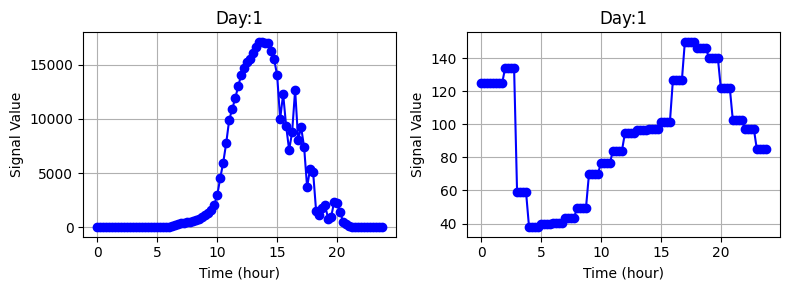

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from modules.solar import PVdata
from modules.economy import ElecPrice

pv_data_path = './data/timeseries-slimpark-2022.csv'
price_data_path='./data/day_ahead_prices_2022.csv'
PV_panel = PVdata(pv_data_path)
elec_price = ElecPrice(price_data_path)

expanded_pv = np.hstack([np.zeros(1,), PV_panel.day_data])
expanded_price = np.hstack([np.zeros(1,), elec_price.day_price_data])

# Create time axis for original and expanded data
time_axis_original = np.arange(0, 24, 1)
time_axis_expanded = np.arange(0, 24, 0.25)

# Plot the original and expanded data in subplots
plt.figure(figsize=(8, 3))
plt.subplot(1,2,1)
plt.plot(time_axis_expanded, expanded_pv[1:], marker='o', linestyle='-', color='b', label='Expanded Data (15 minute)')
plt.xlabel('Time (hour)')
plt.ylabel('Signal Value')
plt.title(f"Day:{PV_panel.day_num}")
plt.grid(True)

plt.subplot(1,2,2)
# plt.plot(time_axis_original.astype(str), price_day[1:], marker='o', linestyle='-', color='g', label='Original Data (1 hour)')
plt.plot(time_axis_expanded, expanded_price[1:], marker='o', linestyle='-', color='b', label='Expanded Data (15 minute)')
plt.xlabel('Time (hour)')
plt.ylabel('Signal Value')
plt.title(f"Day:{PV_panel.day_num}")
plt.grid(True)
plt.tight_layout()
plt.show()


Total number of profiles: 2920


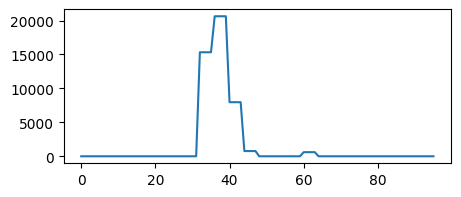

In [3]:
import pandas as pd
import numpy as np

# Load and preprocess data
df = pd.read_csv('data/power_and_active_sessions_cp_UT.csv')
df['date'] = pd.to_datetime(df['times']).dt.date

# Group by date
grouped = df.groupby('date')

# Initialize storage dictionaries
evse_cols = ['evse_1_wh', 'evse_2_wh', 'evse_3_wh', 'evse_4_wh']
evse_data = {col: [] for col in evse_cols}
power_profiles = []

# Iterate over each day's group
for date, group in grouped:
    if len(group) == 96:
        for col in evse_cols:
            evse_data[col].append(group[col].to_numpy())
        power_profiles.append(group['power'].to_numpy())

# Convert lists to numpy arrays
for col in evse_cols:
    evse_data[col] = np.array(evse_data[col])
    evse_data[col] = np.where(evse_data[col] < 10, 0, evse_data[col])

power_profiles = np.array(power_profiles)
power_profiles = np.where(power_profiles < 10, 0, power_profiles)

# Optional: unpack if you want the original variable names
evse_1_wh, evse_2_wh, evse_3_wh, evse_4_wh = (evse_data[col] for col in evse_cols)

all_profiles = np.concatenate((evse_1_wh, evse_2_wh, evse_3_wh, evse_4_wh), axis=0)
print(f"Total number of profiles: {len(all_profiles)}")

plt.figure(figsize=(5, 2))
plt.plot(all_profiles[12])

Total number of profiles: 730


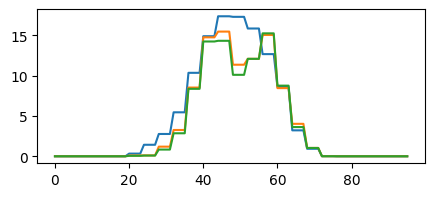

In [4]:
# Initialize storage dictionaries
pv_cols = ['pv_wh', 'pv_forecast_day_ahead_wh', 'pv_forecast_intraday_wh']
pv_data = {col: [] for col in pv_cols}

# Iterate over each day's group
for date, group in grouped:
    if len(group) == 96:
        for col in pv_cols:
            pv_data[col].append(group[col].to_numpy())

# Convert lists to numpy arrays
for col in pv_data:
    pv_data[col] = np.array(pv_data[col])
    pv_data[col] = np.where(pv_data[col] < 0, pv_data[col], 0)

# Optional: unpack if you want the original variable names
pv_wh, pv_forecast_day_ahead_wh, pv_forecast_intraday_wh = (pv_data[col] for col in pv_cols)

all_pv_profiles = -np.stack((pv_wh, pv_forecast_day_ahead_wh, pv_forecast_intraday_wh), axis=-1)
print(f"Total number of profiles: {len(all_pv_profiles)}")

plt.figure(figsize=(5, 2))
plt.plot(all_pv_profiles[100]/1000)

In [5]:
co2_df = pd.read_csv('data/CO2_2022.csv')
co2_df['validfrom (UTC)'] = pd.to_datetime(co2_df['validfrom (UTC)'])

# Extract year, month, day, and hour from the datetime
co2_df['Year'] =  co2_df['validfrom (UTC)'].dt.year
co2_df['Month'] = co2_df['validfrom (UTC)'].dt.month
co2_df['Day'] =   co2_df['validfrom (UTC)'].dt.day
co2_df['Hour'] =  co2_df['validfrom (UTC)'].dt.hour

# Select a specific day (e.g., January 1, 2022)
specific_day = co2_df[(co2_df['Year'] == 2022) & (co2_df['Month'] == 1) & (co2_df['Day'] == 1)]
co2_repeated = np.repeat(specific_day['emissionfactor (kg CO2/kWh)'], 4)

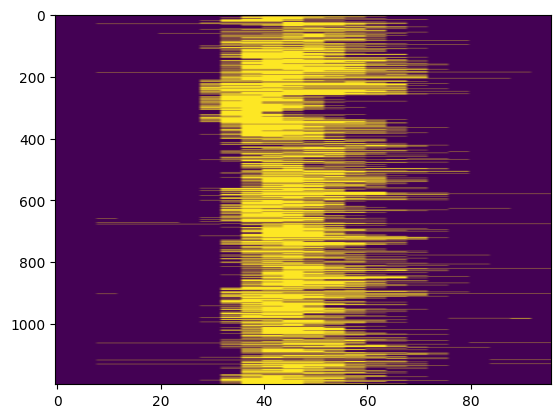

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Assume all_profiles is defined
start_times = []
durations = []
energy_consumptions = []
availability_profiles = []

# Extract features from all_profiles
for prof_id in np.unique(np.where(all_profiles > 10)[0]):
    profile = all_profiles[prof_id]
    active_indices = np.where(profile > 0)[0]
    if len(active_indices) == 0:
        continue
    start = active_indices[0] / 4 + 2
    duration = len(active_indices) / 4
    energy = profile[active_indices].sum()/1000/4 # 4 chargers, kWh
    start_times.append(start)
    durations.append(duration)
    energy_consumptions.append(energy)
    availability = np.zeros_like(profile)
    availability[int(start)*4:int(start+duration)*4] = 1
    availability_profiles.append(availability)

ev_data = torch.tensor(np.stack([start_times, durations, energy_consumptions], axis=1))
availability_data = torch.tensor(np.array(availability_profiles))

plt.imshow(availability_data, aspect='auto')

In [7]:
expanded_pv = np.hstack([np.zeros(1,), all_pv_profiles[100, :, 0]])
expanded_pv_forecast = np.hstack([np.zeros(1,), all_pv_profiles[100, :, 1]])
expanded_emmision = np.hstack([np.zeros(1,), co2_repeated.to_numpy()])

### Train/test split

Train set size: 956, Test set size: 239


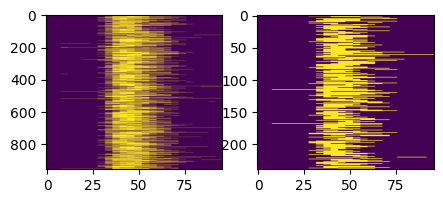

In [8]:
from sklearn.model_selection import train_test_split

train_ev_data, test_ev_data, train_avail_data, test_avail_data = train_test_split(ev_data, availability_data, test_size=0.2, shuffle=True, random_state=42)

print(f"Train set size: {len(train_ev_data)}, Test set size: {len(test_ev_data)}")

plt.figure(figsize=(5, 2))
plt.subplot(1,2,1)
plt.imshow(train_avail_data, aspect='auto')
plt.subplot(1,2,2)
plt.imshow(test_avail_data, aspect='auto')

# II. MDN

In [9]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

class MDN(nn.Module):
    def __init__(self, input_dim, output_dim, n_components=3, hidden_dim=32):
        super().__init__()
        self.n_components = n_components
        self.output_dim = output_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.pi = nn.Linear(hidden_dim, n_components)
        self.mu = nn.Linear(hidden_dim, n_components * output_dim)
        self.sigma = nn.Linear(hidden_dim, n_components * output_dim)

    def forward(self, x):
        h = self.net(x)
        pi = F.softmax(self.pi(h), dim=-1)                                     # (B, K)
        mu = self.mu(h).view(-1, self.n_components, self.output_dim)           # (B, K, D)
        sigma = torch.exp(self.sigma(h)).view(-1, self.n_components, self.output_dim) + 1e-6
        return pi, mu, sigma

    def log_prob(self, target, pi, mu, sigma):
        target = target.unsqueeze(1)                                           # (B, 1, D)
        prob = torch.exp(-0.5 * ((target - mu) / sigma)**2) / (sigma * (2 * np.pi)**0.5)
        prob = prob.prod(dim=-1)                                               # (B, K)
        weighted = pi * prob
        return torch.log(weighted.sum(dim=-1) + 1e-8)                           # (B,)

    def sample(self, pi, mu, sigma):
        batch_size = pi.size(0)
        cat = torch.distributions.Categorical(pi)
        indices = cat.sample()                                                 # (B,)
        mu_selected = mu[torch.arange(batch_size), indices]                   # (B, D)
        sigma_selected = sigma[torch.arange(batch_size), indices]
        eps = torch.randn_like(mu_selected)
        return mu_selected + sigma_selected * eps                              # (B, D)
    
    def sample_greedy(self, pi, mu, sigma):
        batch_size = pi.size(0)
        # Select the component with highest mixing weight (probability)
        indices = torch.argmax(pi, dim=-1)                                     # (B,)
        mu_selected = mu[torch.arange(batch_size), indices]                   # (B, D)
        # Return the mean (mode) of the selected component without noise
        return mu_selected                                                     # (B, D)

mdn1 = MDN(input_dim=1, output_dim=1)       # p(arrival)
mdn2 = MDN(input_dim=1, output_dim=1)       # p(duration | arrival)
mdn3 = MDN(input_dim=2, output_dim=1)       # p(energy | arrival, duration)

optim = torch.optim.Adam(
    list(mdn1.parameters()) +
    list(mdn2.parameters()) +
    list(mdn3.parameters()), 
    lr=1e-3)

for epoch in range(30001):
    batch = train_ev_data  # shape: (B, 3)
    arrival = batch[:, 0:1].float()
    duration = batch[:, 1:2].float()
    energy = batch[:, 2:3].float()

    # MDN1: p(arrival)
    pi1, mu1, sigma1 = mdn1(torch.rand(arrival.shape))  # cast to float32  # dummy input
    logp1 = mdn1.log_prob(arrival, pi1, mu1, sigma1)

    # MDN2: p(duration | arrival)
    pi2, mu2, sigma2 = mdn2(arrival)
    logp2 = mdn2.log_prob(duration, pi2, mu2, sigma2)

    # MDN3: p(energy | arrival, duration)
    x3 = torch.cat([arrival, duration], dim=1)
    pi3, mu3, sigma3 = mdn3(x3)
    logp3 = mdn3.log_prob(energy, pi3, mu3, sigma3)

    # Total negative log-likelihood loss
    loss = -(logp1 + logp2 + logp3).mean()

    optim.zero_grad()
    loss.backward()
    optim.step()

    if epoch % 1e4 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.4f}")

        with torch.no_grad():
            batch = test_ev_data  # shape: (B, 3)
            arrival = batch[:, 0:1].float()
            duration = batch[:, 1:2].float()
            energy = batch[:, 2:3].float()

            # MDN1: p(arrival)
            pi1, mu1, sigma1 = mdn1(torch.rand(arrival.shape))  # cast to float32  # dummy input
            logp1 = mdn1.log_prob(arrival, pi1, mu1, sigma1)

            # MDN2: p(duration | arrival)
            pi2, mu2, sigma2 = mdn2(arrival)
            logp2 = mdn2.log_prob(duration, pi2, mu2, sigma2)

            # MDN3: p(energy | arrival, duration)
            x3 = torch.cat([arrival, duration], dim=1)
            pi3, mu3, sigma3 = mdn3(x3)
            logp3 = mdn3.log_prob(energy, pi3, mu3, sigma3)

            # Total negative log-likelihood loss
            loss = -(logp1 + logp2 + logp3).mean()
            print(f"  Test Loss = {loss.item():.4f}")

Epoch 0, Loss = 37.7436
  Test Loss = 37.3996
Epoch 10000, Loss = 7.7649
  Test Loss = 7.8308
Epoch 20000, Loss = 7.7632
  Test Loss = 7.8567
Epoch 30000, Loss = 7.7343
  Test Loss = 7.8602


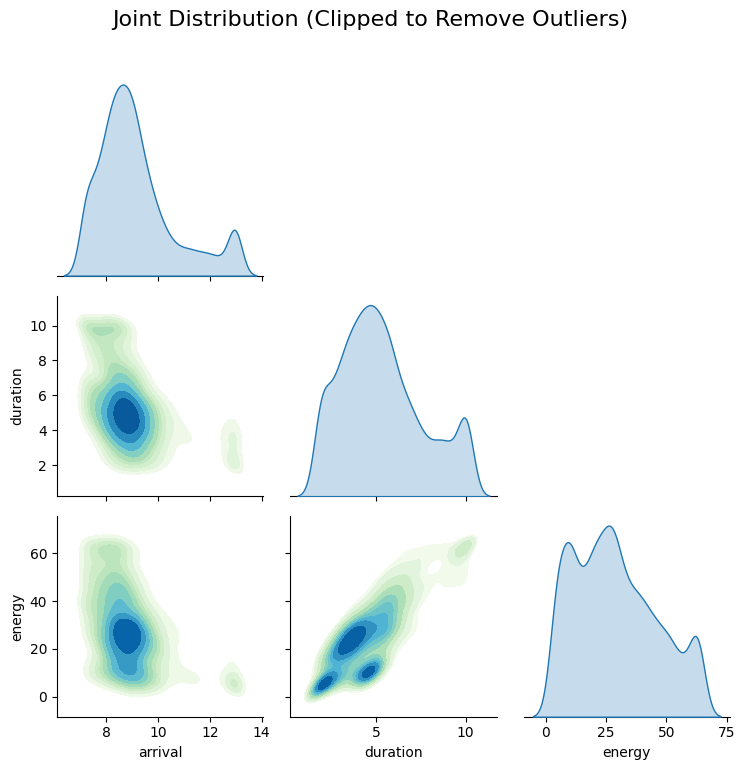

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def sample_autoregressive(mdn1, mdn2, mdn3, n_samples=1000):
    device = next(mdn1.parameters()).device

    # Step 1: sample x1 ~ p(x1)
    dummy_input = torch.rand(n_samples, 1).to(device)
    pi1, mu1, sigma1 = mdn1(dummy_input)
    x1 = mdn1.sample(pi1, mu1, sigma1)  # shape: (N, 1)

    # Step 2: sample x2 ~ p(x2 | x1)
    pi2, mu2, sigma2 = mdn2(x1)
    x2 = mdn2.sample(pi2, mu2, sigma2)  # shape: (N, 1)

    # Step 3: sample x3 ~ p(x3 | x1, x2)
    x12 = torch.cat([x1, x2], dim=1)
    pi3, mu3, sigma3 = mdn3(x12)
    x3 = mdn3.sample(pi3, mu3, sigma3)  # shape: (N, 1)

    # Final samples (N, 3)
    samples = torch.cat([x1, x2, x3], dim=1).detach().cpu().numpy()
    return samples


# Generate samples
samples = sample_autoregressive(mdn1, mdn2, mdn3, n_samples=5000)

# Convert to DataFrame for seaborn
df_samples = pd.DataFrame(samples, columns=["arrival", "duration", "energy"])

def clip_outliers(df, lower=0.01, upper=0.99):
    return df.apply(lambda x: x.clip(lower=x.quantile(lower), upper=x.quantile(upper)))

df_clipped = clip_outliers(df_samples, lower=0.05, upper=0.95)

# Pairplot (joint distribution visualization)
# sns.pairplot(df_clipped, kind="kde", corner=True, plot_kws={"fill": True, "thresh": 0.05}
             
# sns.set(style="whitegrid")

g = sns.pairplot(
    df_clipped,
    kind="kde",  # use KDE for joint distributions
    diag_kind="kde",  # KDE for the diagonal too
    plot_kws={'cmap': 'GnBu', 'fill': True, 'thresh': 0.2},
    corner=True  # optional: only show lower triangle
)

plt.suptitle("Joint Distribution (Clipped to Remove Outliers)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\HeydarianArdakaniA\AppData\Local\Temp\ipykernel_4724\868366070.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


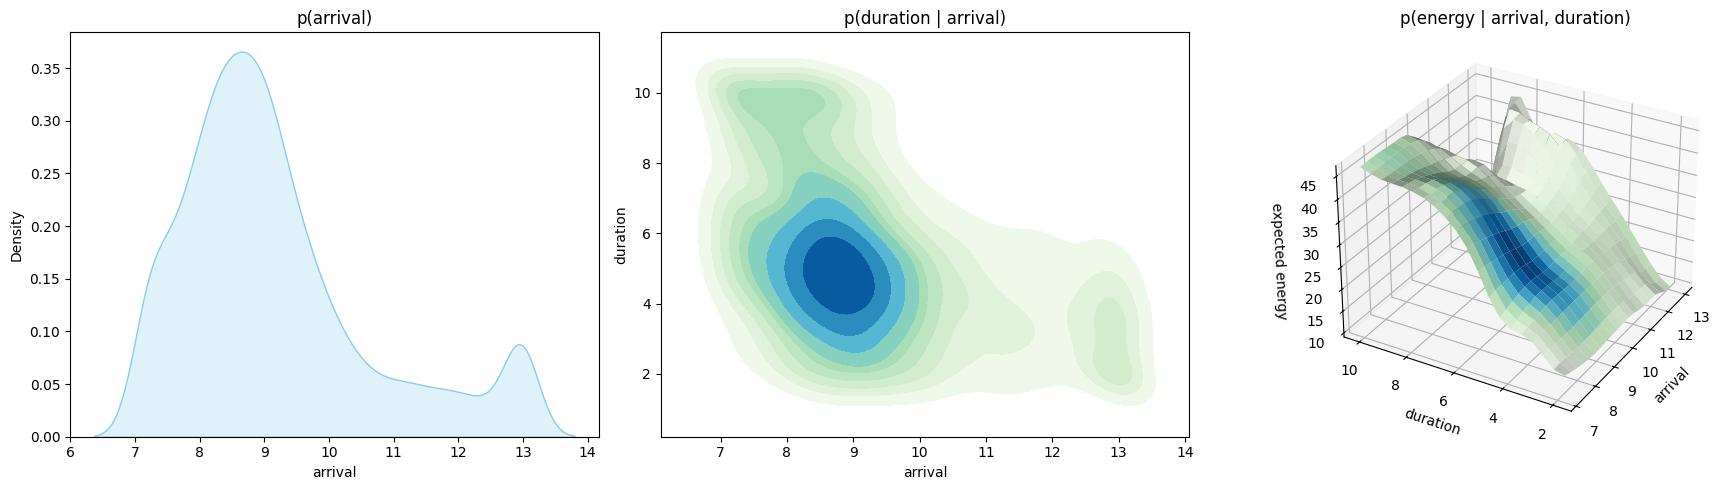

In [11]:
import numpy as np
import seaborn as sns
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

def truncate_colormap(cmap_name, minval=0.3, maxval=1.0, n=100):
    cmap = cm.get_cmap(cmap_name)
    new_cmap = colors.LinearSegmentedColormap.from_list(
        f'trunc({cmap_name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

dark_gnbu = truncate_colormap('GnBu', 0.0, 1.0)


fig = plt.figure(figsize=(18, 5))

# 1D: p(arrival)
ax1 = fig.add_subplot(1, 3, 1)
sns.kdeplot(df_clipped['arrival'], fill=True, color='skyblue', ax=ax1)
ax1.set_title('p(arrival)')


# 2D: p(duration | arrival)
ax2 = fig.add_subplot(1, 3, 2)
sns.kdeplot(
    x=df_clipped['arrival'],
    y=df_clipped['duration'],
    fill=True,
    cmap=dark_gnbu,
    thresh=0.05,
    ax=ax2
)
ax2.set_title('p(duration | arrival)')

# 3D: p(energy | arrival, duration) with density color
ax4 = fig.add_subplot(1, 3, 3, projection='3d')
# Prepare data for KDE
values = df_clipped[['arrival', 'duration', 'energy']].T.values
kde = gaussian_kde(values)

# Create meshgrid for arrival and duration
x = np.linspace(df_clipped['arrival'].min(), df_clipped['arrival'].max(), 20)
y = np.linspace(df_clipped['duration'].min(), df_clipped['duration'].max(), 20)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)
density_values = np.zeros_like(X)

# Compute expected energy and density
energy_range = np.linspace(df_clipped['energy'].min(), df_clipped['energy'].max(), 100)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Evaluate KDE density over energy range
        density = np.array([kde([X[i, j], Y[i, j], e])[0] for e in energy_range])
        # Compute marginal density p(arrival, duration) by integrating over energy
        density_values[i, j] = np.sum(density) * (energy_range[1] - energy_range[0])
        # Compute expected energy: sum(density * energy) / sum(density)
        if np.sum(density) > 0:
            Z[i, j] = np.sum(density * energy_range) / np.sum(density)
        else:
            Z[i, j] = np.nanmean(df_clipped['energy'])  # Fallback to mean energy

# Normalize density_values for colormap (0 to 1)
density_norm = (density_values - density_values.min()) / (density_values.max() - density_values.min())

# Plot the surface with density color using custom colormap
surf = ax4.plot_surface(X, Y, Z, facecolors=dark_gnbu(density_norm), edgecolor='none', alpha=1)

ax4.set_xlabel('arrival')
ax4.set_ylabel('duration')
ax4.set_zlabel('expected energy')
ax4.set_title('p(energy | arrival, duration)')
# fig.colorbar(surf, shrink=0.5, aspect=10, label='Density')

# Set rotation: elevation (30 degrees) and azimuth (-150 degrees)
ax4.view_init(elev=30, azim=-150)

plt.tight_layout()
plt.show()

### Plot distributions seperately

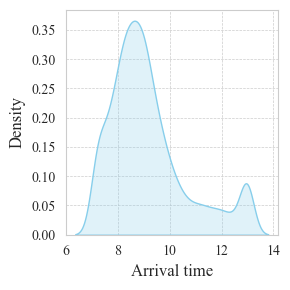

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

plt.figure(figsize=(3, 3))
sns.kdeplot(df_clipped['arrival'], fill=True, color='skyblue', linewidth=1)
# plt.title('p(arrival)')

plt.xlabel('Arrival time', fontsize=12)
plt.ylabel('Density', fontsize=12)
# plt.title('Battery Energy Storage')
# plt.legend(loc='lower right', fontsize=9)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('results/p1.png', dpi=300, bbox_inches='tight', pad_inches=0)  # Save with 300 DPI


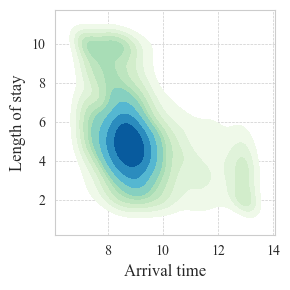

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

plt.figure(figsize=(3, 3))

# 2D: p(duration | arrival)
ax2 = fig.add_subplot(1, 3, 2)
sns.kdeplot(
    x=df_clipped['arrival'],
    y=df_clipped['duration'],
    fill=True,
    cmap=dark_gnbu,
    thresh=0.05
)
# plt.title('${p(l \mid a)}$')

plt.xlabel('Arrival time', fontsize=12)
plt.ylabel('Length of stay', fontsize=12)
# plt.title('Battery Energy Storage')
# plt.legend(loc='lower right', fontsize=9)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('results/p2.png', dpi=300, bbox_inches='tight', pad_inches=0)  # Save with 300 DPI


C:\Users\HeydarianArdakaniA\AppData\Local\Temp\ipykernel_4724\2210808241.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('GnBu')


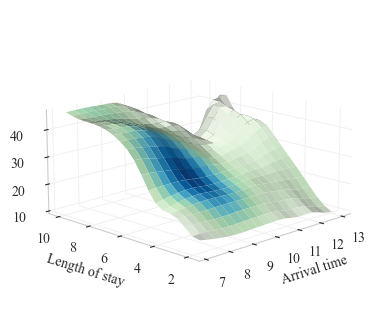

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib import cm

# Set seaborn and matplotlib styles
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Dummy data (replace with your own df_clipped)
# Example:
# df_clipped = pd.read_csv("your_data.csv")
# Ensure df_clipped has columns: 'arrival', 'duration', 'energy'

# Create figure and 3D axis
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 3, 3, projection='3d')

# Prepare data for KDE
values = df_clipped[['arrival', 'duration', 'energy']].T.values
kde = gaussian_kde(values)

# Create meshgrid for arrival and duration
x = np.linspace(df_clipped['arrival'].min(), df_clipped['arrival'].max(), 20)
y = np.linspace(df_clipped['duration'].min(), df_clipped['duration'].max(), 20)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)
density_values = np.zeros_like(X)

# Energy range for integration
energy_range = np.linspace(df_clipped['energy'].min(), df_clipped['energy'].max(), 100)

# Compute KDE-based expected energy and marginal density
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        density = np.array([kde([X[i, j], Y[i, j], e])[0] for e in energy_range])
        density_values[i, j] = np.sum(density) * (energy_range[1] - energy_range[0])
        if np.sum(density) > 0:
            Z[i, j] = np.sum(density * energy_range) / np.sum(density)
        else:
            Z[i, j] = np.nanmean(df_clipped['energy'])

# Normalize density for color mapping
density_norm = (density_values - density_values.min()) / (density_values.max() - density_values.min())

# Use a colormap (replace with your own if needed)
colormap = cm.get_cmap('GnBu')
colors = colormap(density_norm)

# Plot the surface
surf = ax.plot_surface(X, Y, Z, facecolors=colors, edgecolor='none', alpha=1)

# Label axes and title
ax.set_xlabel('Arrival time', fontsize=10)
ax.set_ylabel('Length of stay', fontsize=10)
ax.set_zlabel('Energy demand', fontsize=10)
# ax.set_title('p(energy | arrival, duration)', fontsize=10)

# Adjust 3D view
ax.view_init(elev=15, azim=-135)
ax.set_box_aspect([1, 1, 0.5])  # squash height
# Set background of the panes (walls) to white
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))  # White
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

# Make gridlines very light gray (almost white)
light_gray = (0.95, 0.95, 0.95, 1.0)
ax.xaxis._axinfo["grid"]['color'] = light_gray
ax.yaxis._axinfo["grid"]['color'] = light_gray
ax.zaxis._axinfo["grid"]['color'] = light_gray


# Grid, layout, and save
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('results/p3.png', dpi=300, bbox_inches='tight', pad_inches=0.4)
plt.show()

### MDN sensitivity to [k, n]

In [10]:
def crps_from_samples(samples, y_true, normalize=False):
    y_true = y_true.detach().cpu().numpy()
    D = y_true.shape[1]
    crps_vals = []
    for d in range(D):
        y = y_true[:, d].reshape(-1, 1)   # (B,1)
        s = samples[:, d].reshape(1, -1)  # (1, N)
        term1 = np.mean(np.abs(s - y), axis=1)  # (B,)
        diff = np.abs(s - s.T)                  # (N,N)
        term2 = 0.5 * np.mean(diff)
        crps = np.mean(term1 - term2)
        if normalize:
            scale = np.mean(np.abs(y_true[:, d]))
            if scale > 0:
                crps /= scale
        crps_vals.append(crps)
    return crps_vals

torch.manual_seed(42)

for k in [1, 2, 3, 4, 5]:
    for n in [16, 32, 64, 128, 256]:
        mdn1 = MDN(input_dim=1, output_dim=1, n_components=k, hidden_dim=n)       # p(arrival)
        mdn2 = MDN(input_dim=1, output_dim=1, n_components=k, hidden_dim=n)       # p(duration | arrival)
        mdn3 = MDN(input_dim=2, output_dim=1, n_components=k, hidden_dim=n)       # p(energy | arrival, duration)

        optim = torch.optim.Adam(
            list(mdn1.parameters()) +
            list(mdn2.parameters()) +
            list(mdn3.parameters()), 
            lr=1e-3)

        try:
            for epoch in range(30001):
                batch = train_ev_data  # shape: (B, 3)
                arrival = batch[:, 0:1].float()
                duration = batch[:, 1:2].float()
                energy = batch[:, 2:3].float()
                # MDN1: p(arrival)
                pi1, mu1, sigma1 = mdn1(torch.rand(arrival.shape))  # cast to float32  # dummy input
                logp1 = mdn1.log_prob(arrival, pi1, mu1, sigma1)
                # MDN2: p(duration | arrival)
                pi2, mu2, sigma2 = mdn2(arrival)
                logp2 = mdn2.log_prob(duration, pi2, mu2, sigma2)
                # MDN3: p(energy | arrival, duration)
                x3 = torch.cat([arrival, duration], dim=1)
                pi3, mu3, sigma3 = mdn3(x3)
                logp3 = mdn3.log_prob(energy, pi3, mu3, sigma3)
                # Total negative log-likelihood loss
                loss = -(logp1 + logp2 + logp3).mean()

                optim.zero_grad()
                loss.backward()
                optim.step()

            with torch.no_grad():
                batch = test_ev_data  # shape: (B, 3)
                arrival = batch[:, 0:1].float()
                duration = batch[:, 1:2].float()
                energy = batch[:, 2:3].float()

                # MDN1: p(arrival)
                pi1, mu1, sigma1 = mdn1(torch.rand(arrival.shape))  # cast to float32  # dummy input
                logp1 = mdn1.log_prob(arrival, pi1, mu1, sigma1)
                # MDN2: p(duration | arrival)
                pi2, mu2, sigma2 = mdn2(arrival)
                logp2 = mdn2.log_prob(duration, pi2, mu2, sigma2)
                # MDN3: p(energy | arrival, duration)
                x3 = torch.cat([arrival, duration], dim=1)
                pi3, mu3, sigma3 = mdn3(x3)
                logp3 = mdn3.log_prob(energy, pi3, mu3, sigma3)
                # Total negative log-likelihood loss
                eval_loss = -(logp1 + logp2 + logp3).mean()

                # CRPS
                samples = sample_autoregressive(mdn1, mdn2, mdn3, n_samples=1000)
                # Absolute CRPS (original units)
                crps_vals = crps_from_samples(samples, batch, normalize=False)
                # Normalized CRPS (unitless, comparable across features)
                crps_vals_norm = crps_from_samples(samples, batch, normalize=True)
                print(f"MDN with {k} comps, hidden {n}: "
                    f"Train loss={loss.item():.4f}, "
                    f"Eval loss={eval_loss.item():.4f}, "
                    f"CRPS (abs): arrival={crps_vals[0]:.4f}, duration={crps_vals[1]:.4f}, energy={crps_vals[2]:.4f}, "
                    f"CRPS (norm): arrival={crps_vals_norm[0]:.4f}, duration={crps_vals_norm[1]:.4f}, energy={crps_vals_norm[2]:.4f}")
                
        except:
            pass

MDN with 1 comps, hidden 16: Train loss=8.3078, Eval loss=8.3820, CRPS (abs): arrival=1.0498, duration=1.3286, energy=12.0809, CRPS (norm): arrival=0.1137, duration=0.2500, energy=0.3751
MDN with 1 comps, hidden 32: Train loss=8.2937, Eval loss=8.3056, CRPS (abs): arrival=1.0694, duration=1.3101, energy=12.0834, CRPS (norm): arrival=0.1158, duration=0.2465, energy=0.3752
MDN with 1 comps, hidden 64: Train loss=8.2329, Eval loss=8.3603, CRPS (abs): arrival=1.0502, duration=1.3235, energy=12.0784, CRPS (norm): arrival=0.1137, duration=0.2491, energy=0.3750
MDN with 1 comps, hidden 128: Train loss=8.2187, Eval loss=8.3611, CRPS (abs): arrival=1.0579, duration=1.3177, energy=12.1382, CRPS (norm): arrival=0.1146, duration=0.2480, energy=0.3769
MDN with 1 comps, hidden 256: Train loss=8.1355, Eval loss=8.4013, CRPS (abs): arrival=1.0624, duration=1.3254, energy=12.0893, CRPS (norm): arrival=0.1150, duration=0.2494, energy=0.3754
MDN with 2 comps, hidden 16: Train loss=8.2219, Eval loss=8.337

### Sensetivity matrices

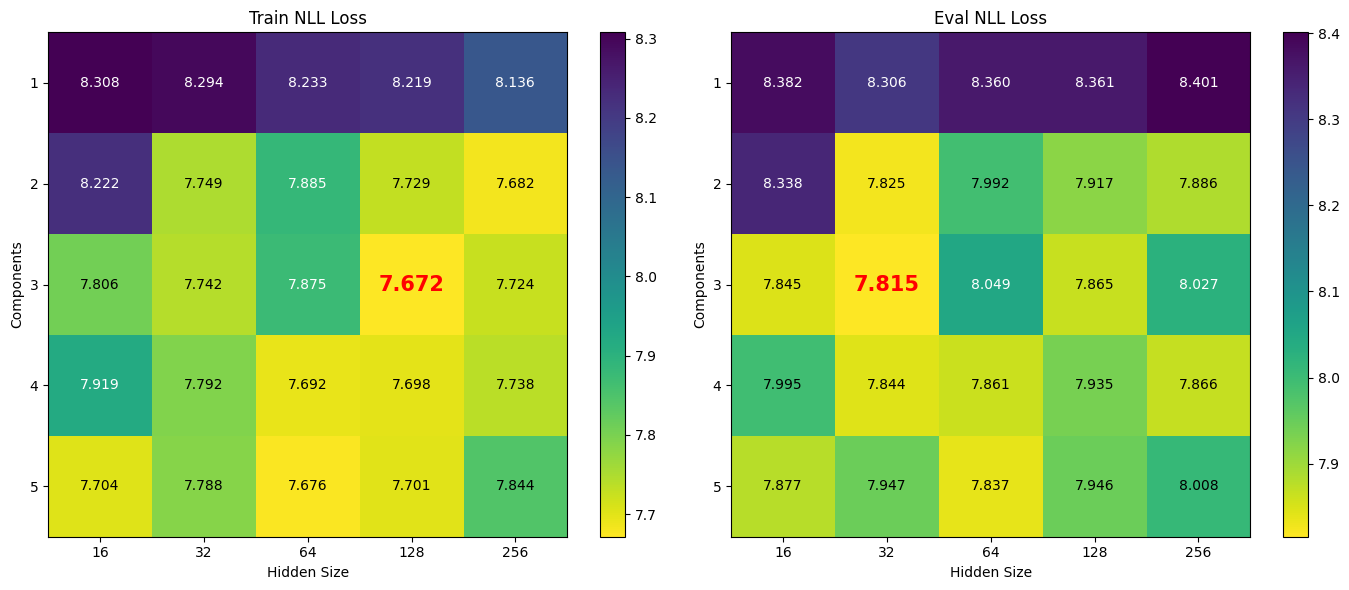

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Configurations
hidden_sizes = [16, 32, 64, 128, 256]
components = [1, 2, 3, 4, 5]

# Train losses (rows = components, cols = hidden sizes)
train_losses = np.array([
    [8.3078, 8.2937, 8.2329, 8.2187, 8.1355],  # 1 comp
    [8.2219, 7.7491, 7.8853, 7.7289, 7.6820],  # 2 comps
    [7.8062, 7.7420, 7.8752, 7.6717, 7.7239],  # 3 comps
    [7.9187, 7.7915, 7.6921, 7.6979, 7.7382],  # 4 comps
    [7.7037, 7.7881, 7.6762, 7.7013, 7.8444]   # 5 comps
])

# Eval losses
eval_losses = np.array([
    [8.3820, 8.3056, 8.3603, 8.3611, 8.4013],  # 1 comp
    [8.3378, 7.8248, 7.9923, 7.9167, 7.8857],  # 2 comps
    [7.8449, 7.8149, 8.0486, 7.8652, 8.0266],  # 3 comps
    [7.9952, 7.8442, 7.8610, 7.9350, 7.8660],  # 4 comps
    [7.8770, 7.9471, 7.8367, 7.9457, 8.0085]   # 5 comps
])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_heatmap(ax, data, title, cmap):
    im = ax.imshow(data, cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(hidden_sizes)))
    ax.set_xticklabels(hidden_sizes)
    ax.set_yticks(np.arange(len(components)))
    ax.set_yticklabels(components)
    ax.set_xlabel("Hidden Size")
    ax.set_ylabel("Components")
    
    min_pos = np.unravel_index(np.argmin(data), data.shape)

    # Add numeric values
    for y in range(data.shape[0]):
        for x in range(data.shape[1]):
            if (y, x) == min_pos:
                continue  # Skip the minimum position (will highlight later)
            # Choose text color based on background brightness
            text_color = "white" if data[y, x] > data.mean() else "black"
            ax.text(x, y, f"{data[y, x]:.3f}", ha="center", va="center", color=text_color, fontsize=10)
    
    # Highlight minimum
    min_pos = np.unravel_index(np.argmin(data), data.shape)
    ax.text(min_pos[1], min_pos[0], f"{data[min_pos]:.3f}", 
            ha="center", va="center", color="red", fontsize=15, fontweight="bold")
    
    fig.colorbar(im, ax=ax)

# Plot train and eval losses
plot_heatmap(axes[0], train_losses, "Train NLL Loss", cmap="viridis_r")
plot_heatmap(axes[1], eval_losses, "Eval NLL Loss", cmap="viridis_r")

plt.tight_layout()
plt.show()


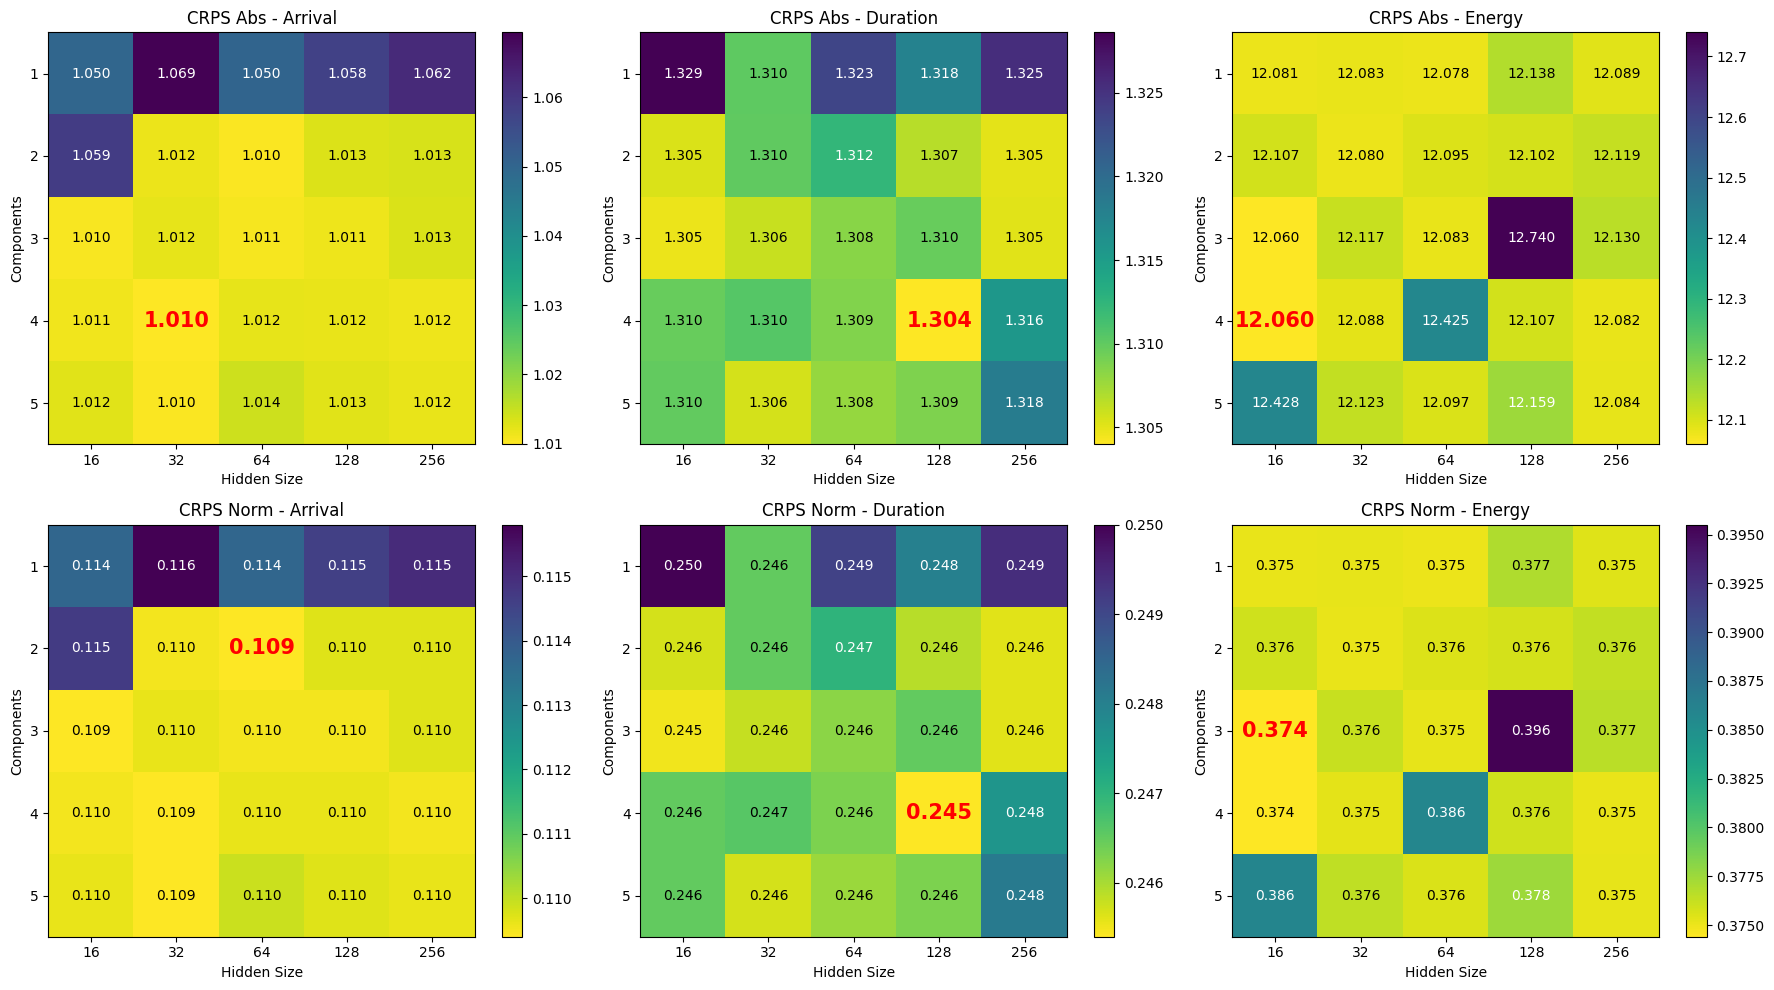

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Data
hidden_sizes = [16, 32, 64, 128, 256]
components = [1, 2, 3, 4, 5]

# Metrics to visualize
metrics_abs = {
    "Arrival": [
        [1.0498, 1.0694, 1.0502, 1.0579, 1.0624],
        [1.0588, 1.0116, 1.0103, 1.0130, 1.0134],
        [1.0104, 1.0122, 1.0108, 1.0114, 1.0133],
        [1.0111, 1.0099, 1.0120, 1.0118, 1.0115],
        [1.0125, 1.0103, 1.0145, 1.0126, 1.0119]
    ],
    "Duration": [
        [1.3286, 1.3101, 1.3235, 1.3177, 1.3254],
        [1.3054, 1.3100, 1.3123, 1.3066, 1.3050],
        [1.3047, 1.3061, 1.3084, 1.3097, 1.3051],
        [1.3097, 1.3105, 1.3087, 1.3040, 1.3156],
        [1.3099, 1.3056, 1.3079, 1.3088, 1.3183]
    ],
    "Energy": [
        [12.0809, 12.0834, 12.0784, 12.1382, 12.0893],
        [12.1068, 12.0801, 12.0953, 12.1025, 12.1189],
        [12.0601, 12.1171, 12.0828, 12.7398, 12.1301],
        [12.0597, 12.0878, 12.4255, 12.1072, 12.0816],
        [12.4280, 12.1227, 12.0969, 12.1590, 12.0844]
    ]
}

metrics_norm = {
    "Arrival": [
        [0.1137, 0.1158, 0.1137, 0.1146, 0.1150],
        [0.1147, 0.1095, 0.1094, 0.1097, 0.1097],
        [0.1094, 0.1096, 0.1095, 0.1095, 0.1097],
        [0.1095, 0.1094, 0.1096, 0.1096, 0.1095],
        [0.1096, 0.1094, 0.1099, 0.1097, 0.1096]
    ],
    "Duration": [
        [0.2500, 0.2465, 0.2491, 0.2480, 0.2494],
        [0.2457, 0.2465, 0.2470, 0.2459, 0.2456],
        [0.2455, 0.2458, 0.2462, 0.2465, 0.2456],
        [0.2465, 0.2466, 0.2463, 0.2454, 0.2476],
        [0.2465, 0.2457, 0.2461, 0.2463, 0.2481]
    ],
    "Energy": [
        [0.3751, 0.3752, 0.3750, 0.3769, 0.3754],
        [0.3759, 0.3751, 0.3755, 0.3758, 0.3763],
        [0.3744, 0.3762, 0.3752, 0.3955, 0.3766],
        [0.3744, 0.3753, 0.3858, 0.3759, 0.3751],
        [0.3859, 0.3764, 0.3756, 0.3775, 0.3752]
    ]
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

def plot_heatmap(ax, data, title, cmap):
    data = np.array(data)
    im = ax.imshow(data, cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(hidden_sizes)))
    ax.set_xticklabels(hidden_sizes)
    ax.set_yticks(np.arange(len(components)))
    ax.set_yticklabels(components)
    ax.set_xlabel("Hidden Size")
    ax.set_ylabel("Components")
    
    min_pos = np.unravel_index(np.argmin(data), data.shape)

    # Add numeric values
    for y in range(data.shape[0]):
        for x in range(data.shape[1]):
            if (y, x) == min_pos:
                continue  # Skip the minimum position (will highlight later)
            # Choose text color based on background brightness
            text_color = "white" if data[y, x] > data.mean() else "black"
            ax.text(x, y, f"{data[y, x]:.3f}", ha="center", va="center", color=text_color, fontsize=10)
    
    # Highlight minimum
    min_pos = np.unravel_index(np.argmin(data), data.shape)
    ax.text(min_pos[1], min_pos[0], f"{data[min_pos]:.3f}", 
            ha="center", va="center", color="red", fontsize=15, fontweight="bold")
    
    fig.colorbar(im, ax=ax)

# Plot absolute CRPS heatmaps
for i, (metric, data) in enumerate(metrics_abs.items()):
    plot_heatmap(axes[0, i], data, f"CRPS Abs - {metric}", cmap="viridis_r")

# Plot normalized CRPS heatmaps
for i, (metric, data) in enumerate(metrics_norm.items()):
    plot_heatmap(axes[1, i], data, f"CRPS Norm - {metric}", cmap="viridis_r")

plt.tight_layout()
plt.show()


# III. Dist-Aware MPC

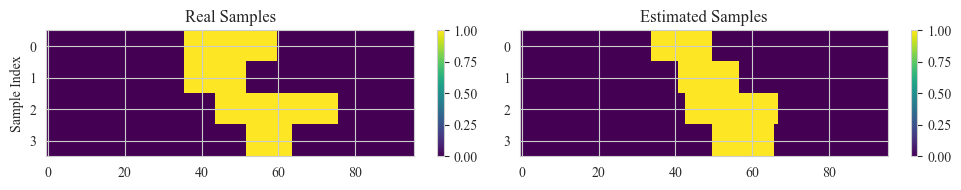

[21.016  16.046  57.8817 23.617 ]


In [1721]:
import numpy as np
import matplotlib.pyplot as plt

def get_filtered_samples(mdn1, mdn2, mdn3, n_samples=5000, n_return=4):
    samples = sample_autoregressive(mdn1, mdn2, mdn3, n_samples=n_samples)
    arrival_samples = samples[:, 0]
    duration_samples = samples[:, 1]
    energy_samples = samples[:, 2]

    # Filter the samples
    mask = (arrival_samples >= 8) & (duration_samples >= 4) & (energy_samples >= 0)
    filtered_arrivals = arrival_samples[mask][:n_return]
    filtered_durations = duration_samples[mask][:n_return]
    filtered_energies = energy_samples[mask][:n_return]

    return filtered_arrivals, filtered_durations, filtered_energies

def compute_availability(arrival_times, durations, n_slots=96):
    n_samples = len(arrival_times)
    # Convert hours to 15-minute slots (vectorized)
    arrival_slots = np.clip((arrival_times * 4).astype(int), 0, n_slots - 1)
    duration_slots = (durations * 4).astype(int)
    departure_slots = arrival_slots + duration_slots
    # Create time slot indices for broadcasting
    slot_indices = np.arange(n_slots)  # Shape: (n_slots,)
    start_mask = slot_indices >= arrival_slots[:, None]  # (n_samples, n_slots)
    # Handle normal case (departure within day) and wrap-around case
    normal_case = departure_slots <= n_slots
    end_mask_normal = slot_indices < departure_slots[:, None]  # (n_samples, n_slots)
    end_mask_wraparound = slot_indices < (departure_slots % n_slots)[:, None]  # (n_samples, n_slots)
    # Create availability matrix
    availability_matrix = np.zeros((n_samples, n_slots), dtype=int)
    # Normal case: within same day
    normal_mask = normal_case[:, None]  # (n_samples, 1)
    availability_matrix = np.where(
        normal_mask,
        start_mask & end_mask_normal,
        start_mask | end_mask_wraparound  # Wrap-around case
    )
    return availability_matrix.astype(int)

def sort_on_arrival(arrivals, durations, energies):
    # Get sorted indices based on arrival times
    sorted_indices = np.argsort(arrivals)
    # Sort all arrays accordingly
    sorted_arrivals = arrivals[sorted_indices]
    sorted_durations = durations[sorted_indices]
    sorted_energies = energies[sorted_indices]
    return sorted_arrivals, sorted_durations, sorted_energies

# Sample once for real
test_ev_data = np.array(test_ev_data)
test_idxs = np.random.choice(len(test_ev_data), size=4, replace=False)
real_arrivals, real_durations, real_energies = test_ev_data[test_idxs, 0], test_ev_data[test_idxs, 1], test_ev_data[test_idxs, 2]
real_arrivals, real_durations, real_energies = sort_on_arrival(real_arrivals, real_durations, real_energies)
# Sample once for estimate
est_arrivals, est_durations, est_energies = get_filtered_samples(mdn1, mdn2, mdn3)
est_arrivals, est_durations, est_energies = sort_on_arrival(est_arrivals, est_durations, est_energies)

real_availability_matrix = compute_availability(real_arrivals, real_durations)
est_availability_matrix = compute_availability(est_arrivals, est_durations)

# Plotting with imshow
fig, axs = plt.subplots(1, 2, figsize=(10, 2))

im0 = axs[0].imshow(real_availability_matrix, aspect='auto', cmap='viridis')
axs[0].set_title("Real Samples")
axs[0].set_yticks(range(4))
axs[0].set_ylabel("Sample Index")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(est_availability_matrix, aspect='auto', cmap='viridis')
axs[1].set_title("Estimated Samples")
axs[1].set_yticks(range(4))
plt.colorbar(im1, ax=axs[1])

plt.tight_layout()
plt.show()
print(real_energies)

##### save and load the real sample of the paper

In [1722]:
# Save the variables as a dictionary
def save_data(real_arrivals, real_durations, real_energies, 
              filename='data.npz'):
    """
    Save numpy arrays as a dictionary to a compressed .npz file
    """
    data_dict = {
        'real_arrivals': real_arrivals,
        'real_durations': real_durations, 
        'real_energies': real_energies,
    }
    
    np.savez_compressed(filename, **data_dict)
    print(f"Data saved to {filename}")

# Load the variables from the dictionary
def load_data(filename='data.npz'):
    """
    Load numpy arrays from a .npz file and return as separate variables
    """
    data = np.load(filename)
    
    real_arrivals = data['real_arrivals']
    real_durations = data['real_durations']
    real_energies = data['real_energies']
    
    print(f"Data loaded from {filename}")
    return real_arrivals, real_durations, real_energies

# # Save the data
# save_data(real_arrivals, real_durations, real_energies, 
#             'my_ev_data.npz')

# # Load the data
# loaded_arrivals, loaded_durations, loaded_energies = load_data('my_ev_data.npz')

# # Verify the data is identical
# print("Data verification:")
# print(f"Arrivals match: {np.array_equal(real_arrivals, loaded_arrivals)}")
# print(f"Durations match: {np.array_equal(real_durations, loaded_durations)}")
# print(f"Energies match: {np.array_equal(real_energies, loaded_energies)}")

In [1723]:
# real_arrivals, real_durations, real_energies = load_data('results/test2.npz')

In [1724]:
# def sample_duration_given_arrival(mdn2, arrival):
#     """Sample duration given a specific arrival time."""
#     # sample x2 ~ p(x2 | x1)
#     arrival_tensor = torch.tensor(arrival).reshape(-1,1).float()  # shape: (1, 1)
#     pi2, mu2, sigma2 = mdn2(arrival_tensor)
#     duration_sample = mdn2.sample_greedy(pi2, mu2, sigma2)  # shape: (1, 1)
#     return duration_sample.detach().numpy().flatten()

# sample_duration_given_arrival(mdn2, [9])

def update_estimates_given_arrival(mdn2, mdn3, arrival):
    # Sample duration given arrival
    arrival_tensor = torch.tensor(arrival).reshape(-1, 1).float()  # shape: (1, 1)
    pi2, mu2, sigma2 = mdn2(arrival_tensor)
    duration_sample = mdn2.sample_greedy(pi2, mu2, sigma2)  # shape: (1, 1)
    # Step 2: Sample energy demand given arrival and duration
    input_tensor = torch.cat([arrival_tensor, duration_sample], dim=1)  # shape: (1, 2)
    pi3, mu3, sigma3 = mdn3(input_tensor)
    demand_sample = mdn3.sample_greedy(pi3, mu3, sigma3)  # shape: (1, 1)
    return  duration_sample.detach().numpy().flatten()[0], demand_sample.detach().numpy().flatten()[0]

# Example usage
update_estimates_given_arrival(mdn2, mdn3, [9])


(4.477881, 26.172926)

In [1725]:
# Sample once for estimate
est_arrivals_temp, est_durations_temp, est_energies_temp = est_arrivals.copy(), est_durations.copy(), est_energies.copy()
est_availability_matrix_temp = est_availability_matrix.copy()

In [1726]:
# reverse the process to get the original arrival times and durations
est_arrivals, est_durations, est_energies = est_arrivals_temp.copy(), est_durations_temp.copy(), est_energies_temp.copy()
est_availability_matrix = est_availability_matrix_temp.copy()

##### MDN-MPC

  0%|          | 0/95 [00:00<?, ?it/s]

EV information - t: 1, arrivals: [ 8.528074 10.430293 10.987369 12.720787], durations: [4.142334  4.15702   6.023429  4.1873226], energies: [11.583811 25.963757 15.341722 41.49585 ]


 37%|███▋      | 35/95 [02:37<02:30,  2.51s/it]

EVs: 1 - t: 36, arrivals: [ 9.       10.430293 10.987369 12.720787], durations: [4.477881  4.15702   6.023429  4.1873226], energies: [26.172926 25.963757 15.341722 41.49585 ]
EVs: 2 - t: 36, arrivals: [ 9.        9.       10.987369 12.720787], durations: [4.477881  4.477881  6.023429  4.1873226], energies: [26.172926 26.172926 15.341722 41.49585 ]


 45%|████▌     | 43/95 [02:58<02:11,  2.53s/it]

EVs: 3 - t: 44, arrivals: [ 9.        9.       11.       12.720787], durations: [4.477881  4.477881  4.005629  4.1873226], energies: [26.172926 26.172926 25.67531  41.49585 ]


 54%|█████▎    | 51/95 [03:04<00:29,  1.48it/s]

EVs: 4 - t: 52, arrivals: [ 9.  9. 11. 13.], durations: [4.477881  4.477881  4.005629  3.5333767], energies: [26.172926 26.172926 25.67531  22.87005 ]


100%|██████████| 95/95 [03:19<00:00,  2.10s/it]


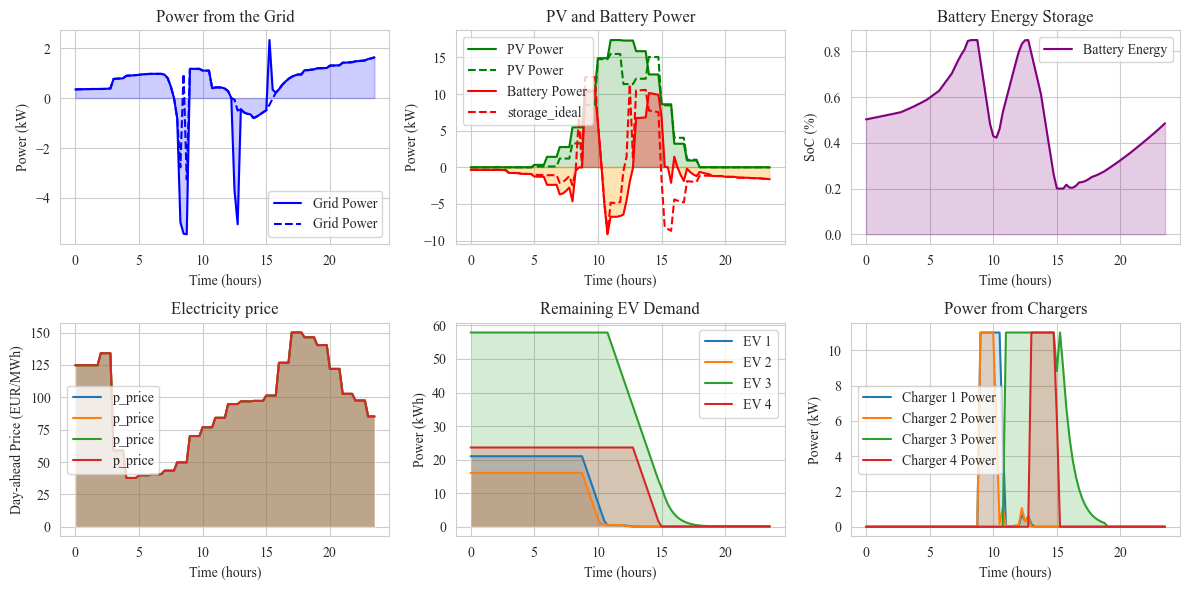

In [1727]:
import cvxpy as cp
import numpy as np
from tqdm import tqdm

class MDN_MPC:
    def __init__(self, num_chargers=4, time_resolution=0.25, storage_capacity=30,
                 capacity_high_limit=0.85, capacity_low_limit=0.2, p_storage_limit=14, p_charger_limit=11):
        self.num_chargers = num_chargers
        self.time_resolution = time_resolution
        self.storage_capacity = storage_capacity
        self.capacity_high_limit = capacity_high_limit
        self.capacity_low_limit = capacity_low_limit
        self.p_storage_limit = p_storage_limit
        self.p_charger_limit = p_charger_limit

        # 1 hours * resolution
        self.time_shift = int(0.25 / self.time_resolution)  
        # Big-M constant
        self.M = 1e5

    def step(self, p_pv, results, charger_availability, p_price, e_factor):
        self.num_time_steps = len(p_pv)  # 24 hours * resolution

        # Initialize parameters
        self.p_grid_initial = cp.Parameter(1, value=results['p_grid'][-1:])
        self.p_grid_positive_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_positive'][-1:], 0, np.inf))
        self.p_grid_negative_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_negative'][-1:], 0, np.inf))

        self.p_storage_initial = cp.Parameter(1, value=np.clip(results['p_storage'][-1:], -self.p_storage_limit, self.p_storage_limit))
        self.p_chargers_initial = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['p_chargers'][-1,:], 0, self.p_charger_limit))
        self.storage_energy_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['storage_energy'][-1:], 
                                                                                 self.storage_capacity*self.capacity_low_limit, 
                                                                                 self.storage_capacity*self.capacity_high_limit))

        self.ev_demand = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['remaining_demand'][-1,:], 0, np.inf))
        self.charger_availability = cp.Parameter((self.num_time_steps, self.num_chargers), boolean=True, value=charger_availability)
        self.p_price = cp.Parameter(self.num_time_steps, value=p_price)
        self.e_factor = cp.Parameter(self.num_time_steps, value=e_factor)

        # Initialize decision variables
        self.p_chargers = cp.Variable((self.num_time_steps, self.num_chargers), nonneg=True)
        self.p_chargers_slack = cp.Variable(self.num_chargers, nonneg=True)
        self.p_grid = cp.Variable(self.num_time_steps)
        self.p_grid_positive = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_grid_negative = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_storage = cp.Variable(self.num_time_steps)
        self.storage_energy = cp.Variable(self.num_time_steps, nonneg=True)

        # Binary variables for big-M method
        self.binary_pos = cp.Variable(self.num_time_steps, boolean=True)

        # Constraints
        constraints = []

        # Charger availability constraints
        constraints.append(self.p_chargers[1:] <= charger_availability[1:]*self.p_charger_limit)

        # Power balance constraints
        constraints.append(p_pv[1:] + self.p_grid[1:] + self.p_storage[1:] == cp.sum(self.p_chargers, axis=1)[1:])

        # Storage constraints
        constraints.append(self.storage_energy[1:] <= self.storage_capacity * self.capacity_high_limit)
        constraints.append(self.storage_energy[1:] >= self.storage_capacity * self.capacity_low_limit)
        constraints.append(self.p_storage <= self.p_storage_limit)
        constraints.append(self.p_storage >= -self.p_storage_limit)

        # Initial conditions
        # constraints.append(self.p_grid[0] == self.p_grid_initial)
        constraints.append(self.p_grid_positive[0] == self.p_grid_positive_initial)
        constraints.append(self.p_grid_negative[0] == self.p_grid_negative_initial)

        constraints.append(self.p_storage[0] == self.p_storage_initial)
        constraints.append(self.p_chargers[0] == self.p_chargers_initial)
        constraints.append(self.storage_energy[0] == self.storage_energy_initial)
        constraints.append(self.storage_energy[-1] == self.storage_capacity/2)

        # Storage dynamics
        constraints.append(self.storage_energy[1:] == self.storage_energy[:-1] - self.p_storage[1:]*self.time_resolution)

        # EV demand constraints
        constraints.append(cp.sum(self.p_chargers[1:]*self.time_resolution, axis=0) == self.ev_demand - self.p_chargers_slack)

        # Auxiliary variables constraints
        constraints.append(self.p_grid == self.p_grid_positive - self.p_grid_negative)

        # Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
        constraints.append(self.binary_pos <= 1)
        constraints.append(self.p_grid_positive <= self.binary_pos * self.M)
        constraints.append(self.p_grid_negative <= (1-self.binary_pos) * self.M)

        # Smoothing constraint to avoid abrupt changes: total variations
        smoothing_penalty = cp.tv(self.p_grid_positive) + cp.tv(self.p_grid_negative) + cp.tv(self.p_storage) + 2*cp.tv(self.p_chargers) 

        # Create time-weighted penalty (higher weights for later time steps)
        time_weights = np.linspace(0, 20, self.num_time_steps)  # Weights increase from 1 to 3
        time_penalty = cp.sum(cp.multiply(time_weights, cp.sum(self.p_chargers, axis=1)))

        # Objective: Minimize total grid power usage
        objective = cp.Minimize(cp.sum(self.p_grid**2)*10
                                + cp.sum(cp.multiply(self.p_price,self.p_grid_positive))*0.1
                                - cp.sum(cp.multiply(self.p_price/2,self.p_grid_negative))*0.1
                                + cp.sum(cp.multiply(self.e_factor, self.p_grid))*0.1
                                + cp.sum((self.p_chargers_slack)**2)*80
                                + smoothing_penalty
                                + time_penalty*10)
        
        # Problem definition and solving
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCIP)
        
        # Output the results
        if problem.status not in ["infeasible", "unbounded"]:
            return {
                "status": problem.status,
                "objective_value": objective.value,
                "p_grid": np.array(self.p_grid.value)[1:1+self.time_shift],
                "p_grid_positive": np.array(self.p_grid_positive.value)[1:1+self.time_shift],
                "p_grid_negative": np.array(self.p_grid_negative.value)[1:1+self.time_shift],
                "p_chargers": np.array(self.p_chargers.value)[1:1+self.time_shift,:],
                "p_storage": np.array(self.p_storage.value)[1:1+self.time_shift],
            }
        else:
            print("The problem is infeasible or unbounded.")

            
    def update_estimates_given_arrival(self, mdn2, mdn3, arrival):
        # Sample duration given arrival
        arrival_tensor = torch.tensor(arrival).reshape(-1, 1).float()  # shape: (1, 1)
        pi2, mu2, sigma2 = mdn2(arrival_tensor)
        duration_sample = mdn2.sample_greedy(pi2, mu2, sigma2)  # shape: (1, 1)
        # Step 2: Sample energy demand given arrival and duration
        input_tensor = torch.cat([arrival_tensor, duration_sample], dim=1)  # shape: (1, 2)
        pi3, mu3, sigma3 = mdn3(input_tensor)
        demand_sample = mdn3.sample_greedy(pi3, mu3, sigma3)  # shape: (1, 1)
        return  duration_sample.detach().numpy().flatten()[0], demand_sample.detach().numpy().flatten()[0]
    
        
        
# Example usage:
# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4


# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_imit = 0.85
capacity_low_imit = 0.2

mpc = MDN_MPC()
current_time = 0
time_shift = int(0.25 / mpc.time_resolution)  # 2 hours * resolution
# Initialize storage energy
storage_energy_initial = np.array([storage_capacity]) / 2
# Initialize EV demand
real_energies_initial = real_energies.reshape(1,4)  # Example EV demand
est_energies_initial = est_energies.reshape(1,4)  # Example EV demand

real_availability = np.vstack([np.zeros((1, len(real_availability_matrix))), real_availability_matrix.T])
est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])

results = {
    'p_grid':           np.zeros((1,)),
    'p_grid_ideal':     np.zeros((1,)),
    'p_grid_positive':  np.zeros((1,)),
    'p_grid_negative':  np.zeros((1,)),
    'p_storage':        np.zeros((1,)),
    'p_storage_ideal':  np.zeros((1,)),
    'storage_energy':   storage_energy_initial,
    'p_chargers':       np.zeros((1, num_chargers)),
    'p_chargers_ideal':       np.zeros((1, num_chargers)),
    'remaining_demand': real_energies_initial,
    'estimated_demand': est_energies_initial,
}

n_occupied = 0

ev_errors = []
for t in tqdm(range(1, num_time_steps)):
    if t == 1: print(f"EV information - t: {t}, arrivals: {est_arrivals}, durations: {est_durations}, energies: {est_energies}")
    # print(f"t: {t}, real arrivals: {real_arrivals}, est arrivals: {est_arrivals}")
    if t in (real_arrivals*4).astype(int):
        for _ in range(np.sum((real_arrivals*4).astype(int)==t)):
            # Sample once for estimate
            new_duration_sample, new_demand_sample = mpc.update_estimates_given_arrival(mdn2, mdn3, t/4)
            # Update estimated arrivals and durations
            est_arrivals[n_occupied] = t/4
            est_durations[n_occupied] = new_duration_sample
            est_energies[n_occupied] = new_demand_sample
            results['estimated_demand'][-1, n_occupied] = new_demand_sample
            # Update estimated availability matrix
            est_availability_matrix = compute_availability(est_arrivals, est_durations)
            est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])
            # incremeant occupied
            n_occupied += 1
            print(f"EVs: {n_occupied} - t: {t}, arrivals: {est_arrivals}, durations: {est_durations}, energies: {est_energies}")
        

    if t%time_shift==0:
        # Forecast and real PV generation (kW)
        p_pv = expanded_pv_forecast[t-1:] / 1000
        p_pv_real = expanded_pv[t-1:] / 1000
        # Charger availability masks
        charger_availability = est_availability[t-1:, :mpc.num_chargers]
        charger_availability_real = real_availability[t-1:, :mpc.num_chargers]
        # Price and emissions
        p_price = expanded_price[t-1:]
        e_factor = expanded_emmision[t-1:]

        # Run MPC step
        command = mpc.step(p_pv, results, charger_availability, p_price, e_factor)

        # Apply real availability to ideal command
        adjusted_p_chargers = (command['p_chargers'] * charger_availability_real[1:time_shift+1]).copy()

        # Compute availability gap (newly available chargers)
        availability_gap = (charger_availability_real[1:time_shift+1] - charger_availability[1:time_shift+1]) > 0.5

        # Remaining energy demand (kWh) per charger at start of this window
        remaining_demand = results['remaining_demand'][-1].copy()
        estimated_demand = results['estimated_demand'][-1].copy()

        # Compute total existing charging power for chargers that are already active
        existing_charging_power = np.sum(
            adjusted_p_chargers[~availability_gap]  # chargers not newly available
        )

        # Compute grid headroom: subtract already committed charging from max grid usage
        raw_grid_headroom = 15 #np.max(np.abs(results['p_grid']))
        grid_headroom = max(0, raw_grid_headroom - existing_charging_power)  # ensure non-negative

        # Consider only chargers that are newly available at least once in this window
        newly_available_mask = np.any(availability_gap, axis=0)
        relevant_demand = remaining_demand * newly_available_mask
        total_demand = relevant_demand.sum() + 1e-6  # avoid divide by zero

        # Precompute weighted per-charger limit based on demand for newly available chargers
        weights = np.abs(relevant_demand / total_demand)
        per_charger_limit = weights * grid_headroom

        # Adjust newly available chargers up to their weighted limit or remaining demand
        for i in range(time_shift):
            for j in range(mpc.num_chargers):
                if availability_gap[i, j]:
                    # Max power based on remaining energy demand
                    if remaining_demand[j] > 0:
                        if estimated_demand[j] > 0:
                            demand_limit = np.minimum(estimated_demand[j]/mpc.time_resolution, remaining_demand[j])
                        else:
                            demand_limit = np.minimum(mpc.p_charger_limit, remaining_demand[j])
                    else:
                        demand_limit = 0
                    # Weighted grid limit for this charger
                    grid_limit_j = per_charger_limit[j]
                    # Clip between zero and the smaller of demand_limit and grid_limit_j
                    adjusted_p_chargers[i, j] = np.clip(
                        demand_limit,  # base from ideal command
                        0,
                        min(grid_limit_j, mpc.p_charger_limit)  # ensure it does not exceed charger limit
                    )
        # if t == 60: break
        # Adjust for actual PV power using the battery
        pv_error = p_pv_real[1:time_shift+1] - p_pv[1:time_shift+1]  # Compute forecast error
        ev_error = np.sum(adjusted_p_chargers - command['p_chargers'], axis=1)
        # print(f"t: {t}, pv_error: {pv_error}, ev_error: {ev_error}")
        ev_errors.append(ev_error)
        # Initialize adjusted battery power
        adjusted_p_storage = command['p_storage'].copy()
        current_storage_energy = results['storage_energy'][-1].copy()  # Current SoC
        # break
        # print(t)
        # if t >= 30:
        #     break
        # Adjust battery power to absorb PV error
        for i in range(time_shift):
            adjusted_p_storage[i] = adjusted_p_storage[i] - pv_error[i] + ev_error[i]
            # Ensure discharging does not exceed limit
            adjusted_p_storage[i] = np.clip(adjusted_p_storage[i], -mpc.p_storage_limit, mpc.p_storage_limit)  # Ensure discharging does not exceed limit
            adjusted_p_storage[i] = -np.clip(-adjusted_p_storage[i], 
                                            -np.negative(mpc.storage_capacity*mpc.capacity_low_limit - current_storage_energy) / mpc.time_resolution,
                                            np.positive(mpc.storage_capacity*mpc.capacity_high_limit - current_storage_energy) / mpc.time_resolution)
            
            # Update SoC for the next iteration
            current_storage_energy = current_storage_energy - \
                                    (1/0.95) * np.maximum(0, adjusted_p_storage[i]) * mpc.time_resolution - \
                                    (0.95) * np.minimum(0, adjusted_p_storage[i]) * mpc.time_resolution

        # Adjust grid power based on adjusted battery power
        p_grid_samples = np.sum(adjusted_p_chargers, axis=1) - adjusted_p_storage - p_pv_real[1:time_shift+1]
        p_grid_positive_samples = np.maximum(p_grid_samples, 0)
        p_grid_negative_samples = np.minimum(p_grid_samples, 0)
        # if t == 57:
        #     print(f"t: {t}, charger: {np.sum(command['p_chargers'], axis=1)},\n adjusted_p_storage: {adjusted_p_storage},\n pv real: {p_pv_real[:time_shift]},\n \
        #           pv forecast: {p_pv[:time_shift]} \n adjusted grid: {p_grid_samples}, p_grid :{command['p_grid']}")

        # print(f"time {t}-{t+time_shift-1},\n p_grid: {command['p_grid']},\n adjusted p_grid: {p_grid_samples},\n p_storage: {command['p_storage']},\n adjusted p_storage: {adjusted_p_storage},\n p_error: {pv_error}")
        # Update storage energy based on adjusted battery power
        storage_energy_samples = results['storage_energy'][-1] - \
                                (1/0.95) * np.cumsum(np.maximum(0, adjusted_p_storage)) * mpc.time_resolution - \
                                (0.95) * np.cumsum(np.minimum(0, adjusted_p_storage)) * mpc.time_resolution

        # EV demand update (unchanged)
        ev_demand_samples = results['remaining_demand'][-1].reshape(1, 4) - \
                            np.cumsum(adjusted_p_chargers, axis=0) * mpc.time_resolution

        est_ev_demand_samples = results['estimated_demand'][-1].reshape(1, 4) - \
                    np.cumsum(adjusted_p_chargers, axis=0) * mpc.time_resolution


        # Store results
        results['p_grid_ideal'] = np.hstack([results['p_grid_ideal'], command['p_grid']])
        results['p_grid'] = np.hstack([results['p_grid'], p_grid_samples])
        results['p_grid_positive'] = np.hstack([results['p_grid_positive'], p_grid_positive_samples])
        results['p_grid_negative'] = np.hstack([results['p_grid_negative'], p_grid_negative_samples])

        results['p_chargers'] = np.vstack([results['p_chargers'], adjusted_p_chargers])
        results['p_chargers_ideal'] = np.vstack([results['p_chargers_ideal'], command['p_chargers']])
        results['p_storage'] = np.hstack([results['p_storage'], adjusted_p_storage])
        results['p_storage_ideal'] = np.hstack([results['p_storage_ideal'], command['p_storage']])
        results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_samples])
        results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_samples])
        results['estimated_demand'] = np.vstack([results['estimated_demand'], est_ev_demand_samples])
        # if t == 4*time_shift+1:
    #     break

for key in results.keys():
    if key not in ['storage_energy', 'remaining_demand', 'estimated_demand']:
        results[key] = results[key][1:]
    else:
        results[key] = results[key][1:]
        
plt.figure(figsize=(12, 6))
time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 3, 1)
plt.plot(time_steps, results['p_grid'], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, results['p_grid'], color='blue', alpha=0.2)
plt.plot(time_steps, results['p_grid_ideal'], label='Grid Power', color='blue', linestyle='--')

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 3, 2)
plt.plot(time_steps, expanded_pv[1:1+len(time_steps)]/1000, label='PV Power', color='green')
plt.fill_between(time_steps, 0, expanded_pv[1:1+len(time_steps)]/1000, color='green', alpha=0.2)
plt.plot(time_steps, expanded_pv_forecast[1:1+len(time_steps)]/1000, label='PV Power', color='green', linestyle='--')

plt.plot(time_steps, results['p_storage'], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) < 0, color='orange', alpha=0.3, interpolate=True)
plt.plot(time_steps, results['p_storage_ideal'], label='storage_ideal', color='red', linestyle='--')

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 3, 3)
plt.plot(time_steps, np.array(results['storage_energy'])/storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot electricity price
plt.subplot(2, 3, 4)
for i in range(4):
    plt.plot(time_steps, expanded_price[1:1+len(time_steps)], label=f'p_price')
    plt.fill_between(time_steps, 0, expanded_price[1:1+len(time_steps)], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Day-ahead Price (EUR/MWh)')
plt.title('Electricity price')
plt.legend()

# Plot EV demand
plt.subplot(2, 3, 5)
for i in range(4):
    plt.plot(time_steps, results['remaining_demand'][:,i], label=f'EV {i+1}')
    plt.fill_between(time_steps, 0, results['remaining_demand'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Remaining EV Demand')
plt.legend()

# Plot charger power
plt.subplot(2, 3, 6)
for i in range(4):
    plt.plot(time_steps, results['p_chargers'][:,i], label=f'Charger {i+1} Power')
    plt.fill_between(time_steps, 0, results['p_chargers'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()

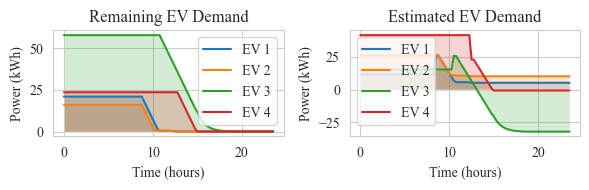

In [1728]:
plt.figure(figsize=(6, 2))
plt.subplot(1, 2, 1)
for i in range(4):
    plt.plot(time_steps, results['remaining_demand'][:,i], label=f'EV {i+1}')
    plt.fill_between(time_steps, 0, results['remaining_demand'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Remaining EV Demand')
plt.legend()

plt.subplot(1, 2, 2)
for i in range(4):
    plt.plot(time_steps, results['estimated_demand'][:,i], label=f'EV {i+1}')
    plt.fill_between(time_steps, 0, results['estimated_demand'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Estimated EV Demand')
plt.legend()
plt.tight_layout()
plt.show()

##### a) dynamics uncertainty: dev notebook

b) PV uncertainty

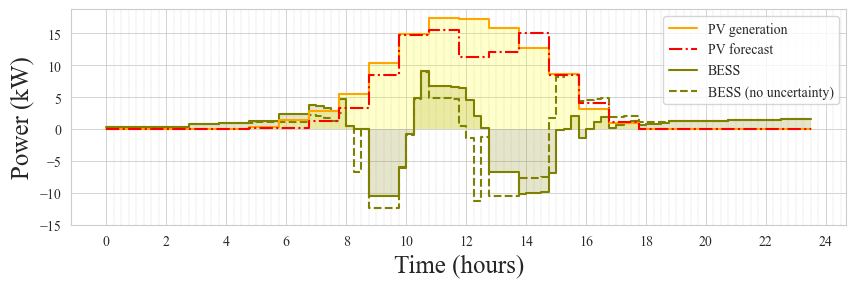

In [1729]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(10, 2.8))
time_steps = np.arange(len(results['p_grid']))/4 

# Plot for ax1 (Battery Power)
ax1.fill_between(time_steps, -results['p_storage'], label='BESS', color='olive', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, -results['p_storage'], color='olive', linewidth=1.5, drawstyle='steps', label='BESS')
line1b, = ax1.plot(time_steps, -results['p_storage_ideal'], '--', color='olive', linewidth=1.5, drawstyle='steps', label='BESS (no uncertainty)')

ax1.set_xlabel('Time (hours)', size=18)
ax1.set_ylabel('Power (kW)', size=18)
ax1.set_ylim([-15, 18.8])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)


# Plot for ax2 (Storage SoC)
ax1.fill_between(time_steps, expanded_pv[1:1+len(time_steps)]/1000, label='PV panel', color='yellow', alpha=0.2, edgecolor='None', step="pre")
line2, = ax1.plot(time_steps, expanded_pv[1:1+len(time_steps)]/1000, color='orange', linewidth=1.5, drawstyle='steps', label='PV generation')
line2b, = ax1.plot(time_steps, expanded_pv_forecast[1:1+len(time_steps)]/1000, '-.', color='red', linewidth=1.5, drawstyle='steps', label='PV forecast')

# line2, = ax2.plot(time_steps, p_pv, '--', label='SoC', color='orange', alpha=0.6, linewidth=1.5, drawstyle='steps')


# Combine legends from both axes
lines = [line2, line2b, line1, line1b]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=10)

# Save the figure
plt.savefig('results/res_pv.png', dpi=300, bbox_inches='tight', pad_inches=0)


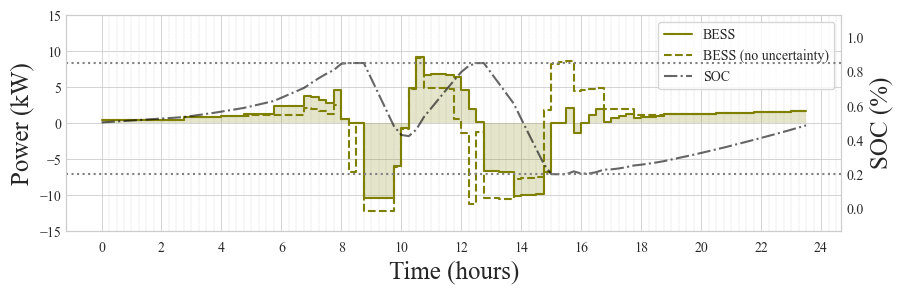

In [1730]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(10, 2.8))
storage_capacity = 30

# Plot for ax1 (Battery Power)
plt.fill_between(time_steps, -results['p_storage'], label='Power', color='olive', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, -results['p_storage'], color='olive', linewidth=1.5, drawstyle='steps', label='BESS')
line1b, = ax1.plot(time_steps, -results['p_storage_ideal'], '--', color='olive', linewidth=1.5, drawstyle='steps', label='BESS (no uncertainty)')

ax1.set_xlabel('Time (hours)', size=18)
ax1.set_ylabel('Power (kW)', size=18)
ax1.set_ylim([-15, 15])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)

# Create second y-axis
ax2 = ax1.twinx()

# Plot for ax2 (Storage SoC)
line2, = ax2.plot(time_steps, np.array(results['storage_energy']) / storage_capacity, '-.', label='SOC', color='black', alpha=0.6, linewidth=1.5)
# Horizontal lines for min and max SoC
ax2.axhline(0.2, color='gray', linestyle=':', linewidth=1.5, label='Min SOC')
ax2.axhline(0.85, color='gray', linestyle=':', linewidth=1.5, label='Max SOC')

ax2.set_ylabel('SOC (%)', size=18)
ax2.set_ylim([-0.13, 1.13])
ax2.grid(False)

# Combine legends from both axes
lines = [line1, line1b, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=10)
# Remove y-axis ticks (but keep labels)
ax1.tick_params(axis='y', length=0)  # For left y-axis
ax2.tick_params(axis='y', length=0)  # For right y-axis

# Save the figure
plt.savefig('results/res_storage.png', dpi=300, bbox_inches='tight', pad_inches=0)


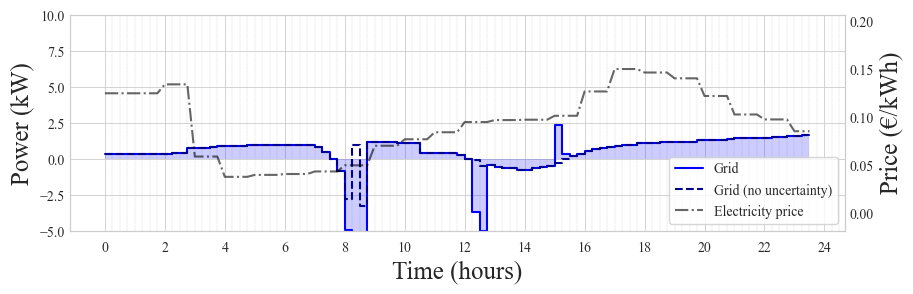

In [1731]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(10, 2.8))

# Plot for ax1 (Grid Power)
plt.fill_between(time_steps, results['p_grid'], label='Power', color='blue', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, results['p_grid'], color='blue', linewidth=1.5, drawstyle='steps', label='Grid')
line1b, = ax1.plot(time_steps, results['p_grid_ideal'], '--', color='darkblue', linewidth=1.5, drawstyle='steps', label='Grid (no uncertainty)')


ax1.set_xlabel('Time (hours)', size=18)
ax1.set_ylabel('Power (kW)', size=18)
ax1.set_ylim([-5,10])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)

# Create second y-axis
ax2 = ax1.twinx()

# Plot for ax2 (Price)
line2, = ax2.plot(time_steps, expanded_price[1:1+len(time_steps)]/1000, '-.', label='Electricity price', color='black', alpha=0.6, linewidth=1.5)
ax2.set_ylabel('Price (€/kWh)', size=18)
price_span = expanded_price[1:1+len(time_steps)].max()/1000-expanded_price[1:1+len(time_steps)].min()/1000
plt.ylim([expanded_price[1:1+len(time_steps)].min()/1000-price_span/2,expanded_price[1:1+len(time_steps)].max()/1000+price_span/2])
ax2.grid(False)

# Combine legends from both axes
lines = [line1, line1b, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=10)
# Remove y-axis ticks (but keep labels)
ax1.tick_params(axis='y', length=0)  # For left y-axis
ax2.tick_params(axis='y', length=0)  # For right y-axis

# Save the figure
plt.savefig('results/res_grid.png', dpi=300, bbox_inches='tight', pad_inches=0)


##### c) EV uncertainty

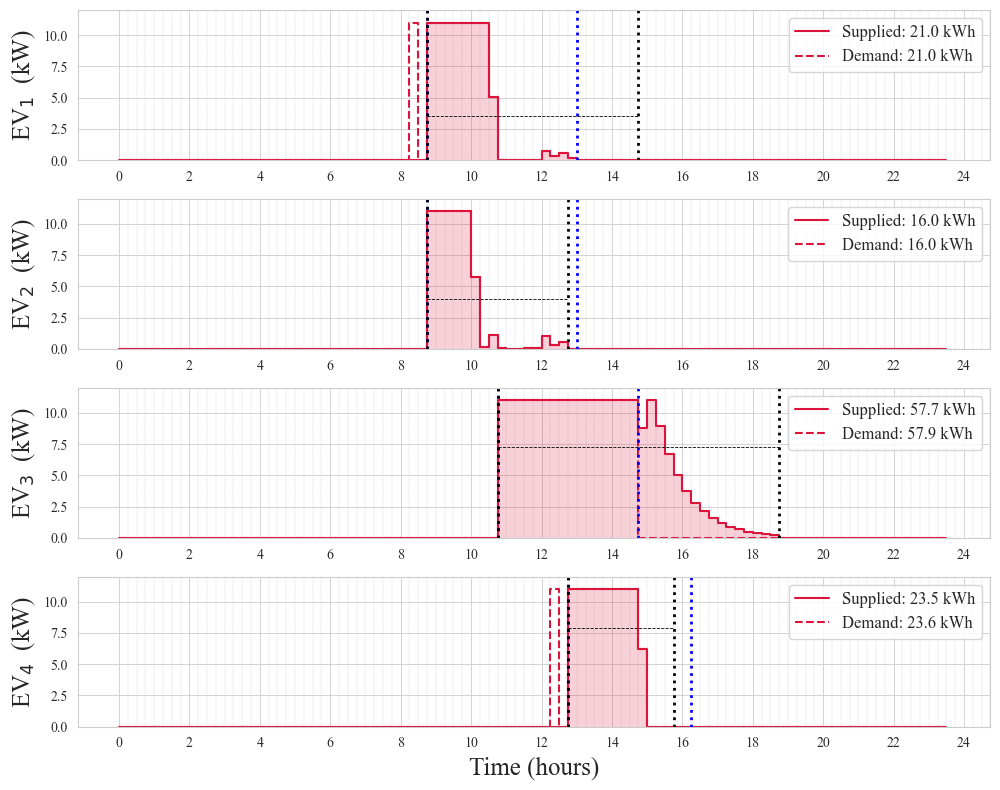

In [1732]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

applied_demand = np.sum(results['p_chargers'], axis=0)/4
# applied_demand[applied_demand > real_energies_initial[0]] = real_energies_initial[0, applied_demand > real_energies_initial[0]]

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, axes = plt.subplots(4, 1, figsize=(10, 8))

for i in range(len(axes)):
    # Plot for ax1 (Battery Power)
    axes[i].fill_between(time_steps, results['p_chargers'][:,i], color='crimson', alpha=0.2, edgecolor='None', step="pre")
    line1, = axes[i].plot(time_steps, results['p_chargers'][:,i], color='crimson', linewidth=1.5, drawstyle='steps', label=f'Supplied: {applied_demand[i]:.1f} kWh')
    line2, = axes[i].plot(time_steps, results['p_chargers_ideal'][:,i], '--', color='crimson', linewidth=1.5, drawstyle='steps', label=f'Demand: {real_energies_initial[0,i]:.1f} kWh')

    ts = np.where(est_availability[1:,i]>0)
    axes[i].axvline(x = (np.min(ts)-1)/4, color = 'blue', linestyle=':', linewidth=2)
    axes[i].axvline(x = (np.max(ts))/4, color = 'blue', linestyle=':', linewidth=2)

    ts = np.where(real_availability[1:,i]>0)
    axes[i].axvline(x = (np.min(ts)-1)/4, color = 'black', linestyle=':', linewidth=2)
    axes[i].axvline(x = (np.max(ts))/4, color = 'black', linestyle=':', linewidth=2)

    charging_time = np.arange(np.min(ts)-1, np.max(ts)+1)/4
    axes[i].plot(charging_time, np.repeat(real_energies_initial[0,i]/(max(charging_time)-min(charging_time)), len(charging_time)) , color = 'black', linestyle='--', linewidth=0.6)

    axes[i].set_ylabel(f'EV$_{{{i+1}}}$  (kW)', size=18)
    axes[i].set_ylim([0, 12])
    axes[i].grid(True, which='minor', linestyle='--', linewidth=0.3)
    axes[i].grid(True, which='major', linestyle='-', linewidth=0.6)

    # Set x-axis ticks
    minor_hours = np.arange(0, 25, 0.25)
    major_hours = np.arange(0, 25, 2)
    axes[i].set_xticks(minor_hours, minor=True)
    axes[i].set_xticks(major_hours, minor=False)

    # # Combine legends from both axes
    axes[i].legend(loc='upper right', fontsize=12)

axes[i].set_xlabel('Time (hours)', size=18)
plt.tight_layout()
# Save the figure
plt.savefig('results/res_chargers.png', dpi=300, bbox_inches='tight', pad_inches=0)


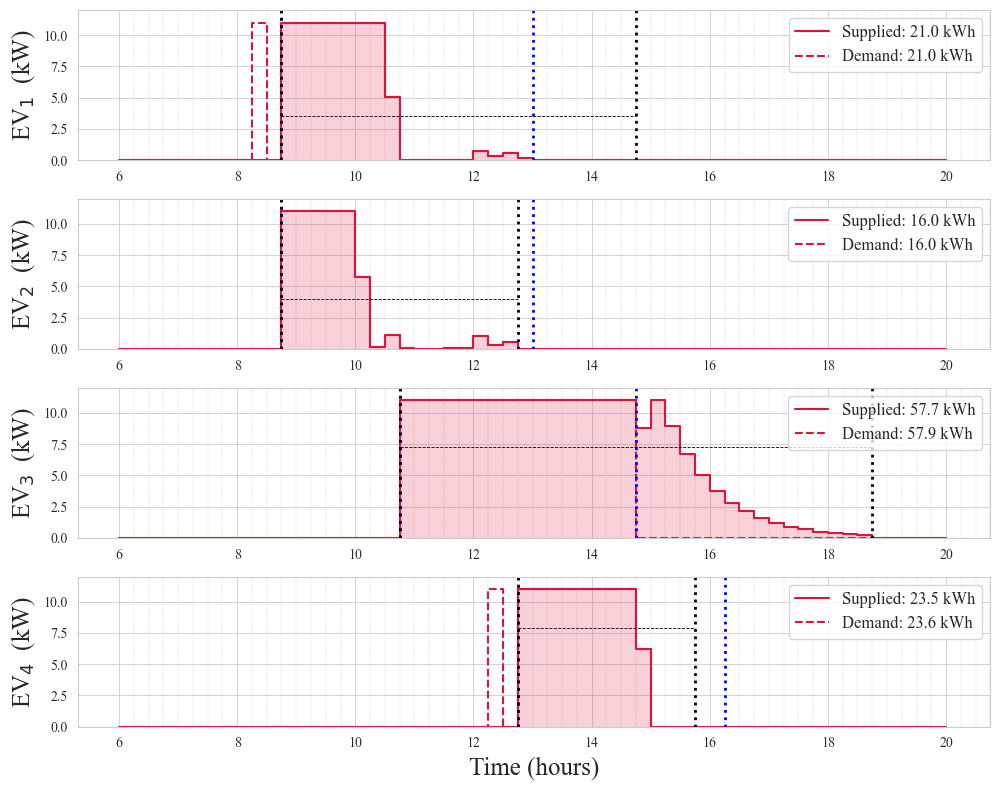

In [1733]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

applied_demand = np.sum(results['p_chargers'], axis=0)/4

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, axes = plt.subplots(4, 1, figsize=(10, 8))

for i in range(len(axes)):
    # Plot for ax1 (Battery Power)
    axes[i].fill_between(time_steps[24:81], results['p_chargers'][24:81,i], color='crimson', alpha=0.2, edgecolor='None', step="pre")
    line1, = axes[i].plot(time_steps[24:81], results['p_chargers'][24:81,i], color='crimson', linewidth=1.5, drawstyle='steps', label=f'Supplied: {applied_demand[i]:.1f} kWh')
    line2, = axes[i].plot(time_steps[24:81], results['p_chargers_ideal'][24:81,i], '--', color='crimson', linewidth=1.5, drawstyle='steps', label=f'Demand: {real_energies_initial[0,i]:.1f} kWh')

    ts = np.where(est_availability[1:,i]>0)
    axes[i].axvline(x = (np.min(ts)-1)/4, color = 'blue', linestyle=':', linewidth=2)
    axes[i].axvline(x = (np.max(ts))/4, color = 'blue', linestyle=':', linewidth=2)

    ts = np.where(real_availability[1:,i]>0)
    axes[i].axvline(x = (np.min(ts)-1)/4, color = 'black', linestyle=':', linewidth=2)
    axes[i].axvline(x = (np.max(ts))/4, color = 'black', linestyle=':', linewidth=2)

    charging_time = np.arange(np.min(ts)-1, np.max(ts)+1)/4
    axes[i].plot(charging_time, np.repeat(real_energies_initial[0,i]/(max(charging_time)-min(charging_time)), len(charging_time)) , color = 'black', linestyle='--', linewidth=0.6)

    axes[i].set_ylabel(f'EV$_{{{i+1}}}$  (kW)', size=18)
    axes[i].set_ylim([0, 12])
    axes[i].grid(True, which='minor', linestyle='--', linewidth=0.3)
    axes[i].grid(True, which='major', linestyle='-', linewidth=0.6)

    # Set x-axis ticks
    minor_hours = np.arange(6, 21, 0.25)
    major_hours = np.arange(6, 21, 2)
    axes[i].set_xticks(minor_hours, minor=True)
    axes[i].set_xticks(major_hours, minor=False)

    # # Combine legends from both axes
    axes[i].legend(loc='upper right', fontsize=12)

axes[i].set_xlabel('Time (hours)', size=18)
plt.tight_layout()
# Save the figure
plt.savefig('results/res_chargers_2.png', dpi=300, bbox_inches='tight', pad_inches=0.1)


##### d) table results

In [1734]:
# compute the unmet demand
applied_demand = np.sum(results['p_chargers'], axis=0)/4
print("Unmet demand (kWh):", np.mean(np.abs(real_energies_initial[0] - applied_demand)))
print("Electricity cost (EUR):", (expanded_price[1:1+len(time_steps)]/1000 * results['p_grid_positive']-expanded_price[1:1+len(time_steps)]/2/1000 * results['p_grid_negative']).sum()/4)
print("Power Peak (kW):", np.max(np.abs(results['p_grid'])))
print("Emissions Peak (gCO2eq):", (expanded_emmision[1:1+len(time_steps)] * results['p_grid']).sum()/4)

Unmet demand (kWh): 0.06648185436876464
Electricity cost (EUR): 1.956720299129654
Power Peak (kW): 5.452784881221738
Emissions Peak (gCO2eq): 2.2472964652571523


In [1735]:
results['real_arrivals'] = real_arrivals
results['real_durations'] = real_durations
results['real_energies'] = real_energies
results['real_availability'] = real_availability

results['est_arrivals'] = est_arrivals
results['est_durations'] = est_durations
results['est_energies'] = est_energies
results['est_availability'] = est_availability


In [1736]:
filename = "results/mpc_results.npz"
np.savez_compressed(filename, **results)
print(f"Data saved to {filename}")

# load mpc_results for plotting
results = dict(np.load(filename))

Data saved to results/mpc_results.npz


# EV uncertainty results

### MDN-MPC

In [30]:
import cvxpy as cp
import numpy as np
from tqdm import tqdm

class MDN_MPC:
    def __init__(self, num_chargers=4, time_resolution=0.25, storage_capacity=30,
                 capacity_high_limit=0.85, capacity_low_limit=0.2, p_storage_limit=14, p_charger_limit=11):
        self.num_chargers = num_chargers
        self.time_resolution = time_resolution
        self.storage_capacity = storage_capacity
        self.capacity_high_limit = capacity_high_limit
        self.capacity_low_limit = capacity_low_limit
        self.p_storage_limit = p_storage_limit
        self.p_charger_limit = p_charger_limit

        # 1 hours * resolution
        self.time_shift = int(0.25 / self.time_resolution)  
        # Big-M constant
        self.M = 1e5

    def step(self, p_pv, results, charger_availability, p_price, e_factor):
        self.num_time_steps = len(p_pv)  # 24 hours * resolution

        # Initialize parameters
        self.p_grid_initial = cp.Parameter(1, value=results['p_grid'][-1:])
        self.p_grid_positive_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_positive'][-1:], 0, np.inf))
        self.p_grid_negative_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_negative'][-1:], 0, np.inf))

        self.p_storage_initial = cp.Parameter(1, value=np.clip(results['p_storage'][-1:], -self.p_storage_limit, self.p_storage_limit))
        self.p_chargers_initial = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['p_chargers'][-1,:], 0, self.p_charger_limit))
        self.storage_energy_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['storage_energy'][-1:], 
                                                                                 self.storage_capacity*self.capacity_low_limit, 
                                                                                 self.storage_capacity*self.capacity_high_limit))

        self.ev_demand = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['remaining_demand'][-1,:], 0, np.inf))
        self.charger_availability = cp.Parameter((self.num_time_steps, self.num_chargers), boolean=True, value=charger_availability)
        self.p_price = cp.Parameter(self.num_time_steps, value=p_price)
        self.e_factor = cp.Parameter(self.num_time_steps, value=e_factor)

        # Initialize decision variables
        self.p_chargers = cp.Variable((self.num_time_steps, self.num_chargers), nonneg=True)
        self.p_chargers_slack = cp.Variable(self.num_chargers, nonneg=True)
        self.p_grid = cp.Variable(self.num_time_steps)
        self.p_grid_positive = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_grid_negative = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_storage = cp.Variable(self.num_time_steps)
        self.storage_energy = cp.Variable(self.num_time_steps, nonneg=True)

        # Binary variables for big-M method
        self.binary_pos = cp.Variable(self.num_time_steps, boolean=True)

        # Constraints
        constraints = []

        # Charger availability constraints
        constraints.append(self.p_chargers[1:] <= charger_availability[1:]*self.p_charger_limit)

        # Power balance constraints
        constraints.append(p_pv[1:] + self.p_grid[1:] + self.p_storage[1:] == cp.sum(self.p_chargers, axis=1)[1:])

        # Storage constraints
        constraints.append(self.storage_energy[1:] <= self.storage_capacity * self.capacity_high_limit)
        constraints.append(self.storage_energy[1:] >= self.storage_capacity * self.capacity_low_limit)
        constraints.append(self.p_storage <= self.p_storage_limit)
        constraints.append(self.p_storage >= -self.p_storage_limit)

        # Initial conditions
        # constraints.append(self.p_grid[0] == self.p_grid_initial)
        constraints.append(self.p_grid_positive[0] == self.p_grid_positive_initial)
        constraints.append(self.p_grid_negative[0] == self.p_grid_negative_initial)

        constraints.append(self.p_storage[0] == self.p_storage_initial)
        constraints.append(self.p_chargers[0] == self.p_chargers_initial)
        constraints.append(self.storage_energy[0] == self.storage_energy_initial)
        constraints.append(self.storage_energy[-1] == self.storage_capacity/2)

        # Storage dynamics
        constraints.append(self.storage_energy[1:] == self.storage_energy[:-1] - self.p_storage[1:]*self.time_resolution)

        # EV demand constraints
        constraints.append(cp.sum(self.p_chargers[1:]*self.time_resolution, axis=0) == self.ev_demand - self.p_chargers_slack)

        # Auxiliary variables constraints
        constraints.append(self.p_grid == self.p_grid_positive - self.p_grid_negative)

        # Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
        constraints.append(self.binary_pos <= 1)
        constraints.append(self.p_grid_positive <= self.binary_pos * self.M)
        constraints.append(self.p_grid_negative <= (1-self.binary_pos) * self.M)

        # Smoothing constraint to avoid abrupt changes: total variations
        smoothing_penalty = cp.tv(self.p_grid_positive) + cp.tv(self.p_grid_negative) + cp.tv(self.p_storage) + 2*cp.tv(self.p_chargers) 

        # Create time-weighted penalty (higher weights for later time steps)
        time_weights = np.linspace(0, 20, self.num_time_steps)  # Weights increase from 1 to 3
        time_penalty = cp.sum(cp.multiply(time_weights, cp.sum(self.p_chargers, axis=1)))

        # Objective: Minimize total grid power usage
        objective = cp.Minimize(cp.sum(self.p_grid**2)*10
                                + cp.sum(cp.multiply(self.p_price,self.p_grid_positive))*0.1
                                - cp.sum(cp.multiply(self.p_price/2,self.p_grid_negative))*0.1
                                + cp.sum(cp.multiply(self.e_factor, self.p_grid))*0.1
                                + cp.sum((self.p_chargers_slack)**2)*80
                                + smoothing_penalty
                                + time_penalty*10)
        
        # Problem definition and solving
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCIP)
        
        # Output the results
        if problem.status not in ["infeasible", "unbounded"]:
            return {
                "status": problem.status,
                "objective_value": objective.value,
                "p_grid": np.array(self.p_grid.value)[1:1+self.time_shift],
                "p_grid_positive": np.array(self.p_grid_positive.value)[1:1+self.time_shift],
                "p_grid_negative": np.array(self.p_grid_negative.value)[1:1+self.time_shift],
                "p_chargers": np.array(self.p_chargers.value)[1:1+self.time_shift,:],
                "p_storage": np.array(self.p_storage.value)[1:1+self.time_shift],
            }
        else:
            print("The problem is infeasible or unbounded.")

            
    def update_estimates_given_arrival(self, mdn2, mdn3, arrival):
        # Sample duration given arrival
        arrival_tensor = torch.tensor(arrival).reshape(-1, 1).float()  # shape: (1, 1)
        pi2, mu2, sigma2 = mdn2(arrival_tensor)
        duration_sample = mdn2.sample_greedy(pi2, mu2, sigma2)  # shape: (1, 1)
        # Step 2: Sample energy demand given arrival and duration
        input_tensor = torch.cat([arrival_tensor, duration_sample], dim=1)  # shape: (1, 2)
        pi3, mu3, sigma3 = mdn3(input_tensor)
        demand_sample = mdn3.sample_greedy(pi3, mu3, sigma3)  # shape: (1, 1)
        return  duration_sample.detach().numpy().flatten()[0], demand_sample.detach().numpy().flatten()[0]

test_ev_data = np.array(test_ev_data)
for SCENARIO in [1, 2, 3, 4]:
    print(f"Running scenario {SCENARIO}...")

    unmet_demands = []
    electricity_costs = []
    power_peaks = []
    emissions_peaks = []
    emmisions_both = []

    for i in tqdm(range(30)):
        np.random.seed(i)
        torch.manual_seed(i)
        test_idxs = np.random.choice(len(test_ev_data), size=4, replace=False)
        real_arrivals, real_durations, real_energies = test_ev_data[test_idxs, 0], test_ev_data[test_idxs, 1], test_ev_data[test_idxs, 2]
        real_arrivals, real_durations, real_energies = sort_on_arrival(real_arrivals, real_durations, real_energies)
        # Sample once for estimate
        est_arrivals, est_durations, est_energies = get_filtered_samples(mdn1, mdn2, mdn3)
        est_arrivals, est_durations, est_energies = sort_on_arrival(est_arrivals, est_durations, est_energies)

        # UNC = 0.3  # 30% uncertainty
        # Scenario 1: Estimated is the same as real
        if SCENARIO == 1:
            est_arrivals = real_arrivals.copy()
            est_durations = real_durations.copy()
            est_energies = real_energies.copy()
        # Scenario 2: Arrival is different by UNC
        if SCENARIO == 2:
            # arrival_noise = np.random.uniform(-UNC, UNC, size=real_arrivals.shape)
            # est_arrivals = real_arrivals * (1 + arrival_noise)
            est_durations = real_durations.copy()
            est_energies = real_energies.copy()
        # Scenario 3: Arrival and duration are different by UNC
        if SCENARIO == 3:
            # arrival_noise = np.random.uniform(-UNC, UNC, size=real_arrivals.shape)
            # duration_noise = np.random.uniform(-UNC, UNC, size=real_durations.shape)
            # est_arrivals = real_arrivals * (1 + arrival_noise)
            # est_durations = real_durations * (1 + duration_noise)
            est_energies = real_energies.copy()
        # Scenario 4: All parameters are different by UNC
        if SCENARIO == 4:
            pass
            # arrival_noise = np.random.uniform(-UNC, UNC, size=real_arrivals.shape)
            # duration_noise = np.random.uniform(-UNC, UNC, size=real_durations.shape)
            # energy_noise = np.random.uniform(-UNC, UNC, size=real_energies.shape)
            # est_arrivals = real_arrivals * (1 + arrival_noise)
            # est_durations = real_durations * (1 + duration_noise)
            # est_energies = real_energies * (1 + energy_noise)

        # increase demand to highlight the differences
        # real_energies *= 1.2
        # est_energies *= 1.2

        real_arrivals, real_durations, real_energies = sort_on_arrival(real_arrivals, real_durations, real_energies)
        est_arrivals, est_durations, est_energies = sort_on_arrival(est_arrivals, est_durations, est_energies)
        real_availability_matrix = compute_availability(real_arrivals, real_durations)
        est_availability_matrix = compute_availability(est_arrivals, est_durations)
        
        # Parameters
        num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
        num_chargers = 4

        # Storage constraints
        storage_capacity = 30  # Example capacity
        capacity_high_imit = 0.85
        capacity_low_imit = 0.2

        mpc = MDN_MPC()
        current_time = 0
        time_shift = int(0.25 / mpc.time_resolution)  # 2 hours * resolution
        # Initialize storage energy
        storage_energy_initial = np.array([storage_capacity]) / 2
        # Initialize EV demand
        real_energies_initial = real_energies.reshape(1,4)  # Example EV demand
        est_energies_initial = est_energies.reshape(1,4)  # Example EV demand

        real_availability = np.vstack([np.zeros((1, len(real_availability_matrix))), real_availability_matrix.T])
        est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])

        results = {
            'p_grid':           np.zeros((1,)),
            'p_grid_ideal':     np.zeros((1,)),
            'p_grid_positive':  np.zeros((1,)),
            'p_grid_negative':  np.zeros((1,)),
            'p_storage':        np.zeros((1,)),
            'p_storage_ideal':  np.zeros((1,)),
            'storage_energy':   storage_energy_initial,
            'p_chargers':       np.zeros((1, num_chargers)),
            'p_chargers_ideal':       np.zeros((1, num_chargers)),
            'remaining_demand': real_energies_initial,
            'estimated_demand': est_energies_initial,
        }

        n_occupied = 0

        ev_errors = []
        for t in range(1, num_time_steps):
            # if t == 1: print(f"EV information - t: {t}, arrivals: {est_arrivals}, durations: {est_durations}, energies: {est_energies}")
            # print(f"t: {t}, real arrivals: {real_arrivals}, est arrivals: {est_arrivals}")
            if t in (real_arrivals*4).astype(int):
                for _ in range(np.sum((real_arrivals*4).astype(int)==t)):
                    # Sample once for estimate
                    new_duration_sample, new_demand_sample = mpc.update_estimates_given_arrival(mdn2, mdn3, t/4)
                    # Update estimated arrivals and durations
                    if SCENARIO == 1:
                        pass
                    if SCENARIO == 2:
                        est_arrivals[n_occupied] = t/4
                    if SCENARIO == 3:
                        est_arrivals[n_occupied] = t/4
                        est_durations[n_occupied] = new_duration_sample
                    if SCENARIO == 4:
                        est_arrivals[n_occupied] = t/4
                        est_durations[n_occupied] = new_duration_sample
                        est_energies[n_occupied] = new_demand_sample
                        results['estimated_demand'][-1, n_occupied] = new_demand_sample
                    # Update estimated availability matrix
                    est_availability_matrix = compute_availability(est_arrivals, est_durations)
                    est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])
                    # incremeant occupied
                    n_occupied += 1
                    # print(f"EVs: {n_occupied} - t: {t}, arrivals: {est_arrivals}, durations: {est_durations}, energies: {est_energies}")


            if t%time_shift==0:
                # Forecast and real PV generation (kW)
                p_pv = expanded_pv_forecast[t-1:] / 1000
                p_pv_real = expanded_pv[t-1:] / 1000
                # Charger availability masks
                charger_availability = est_availability[t-1:, :mpc.num_chargers]
                charger_availability_real = real_availability[t-1:, :mpc.num_chargers]
                # Price and emissions
                p_price = expanded_price[t-1:]
                e_factor = expanded_emmision[t-1:]

                # Run MPC step
                command = mpc.step(p_pv, results, charger_availability, p_price, e_factor)

                # Apply real availability to ideal command
                adjusted_p_chargers = (command['p_chargers'] * charger_availability_real[1:time_shift+1]).copy()

                # Compute availability gap (newly available chargers)
                availability_gap = (charger_availability_real[1:time_shift+1] - charger_availability[1:time_shift+1]) > 0.5

                # Remaining energy demand (kWh) per charger at start of this window
                remaining_demand = results['remaining_demand'][-1].copy()
                estimated_demand = results['estimated_demand'][-1].copy()

                # Compute total existing charging power for chargers that are already active
                existing_charging_power = np.sum(
                    adjusted_p_chargers[~availability_gap]  # chargers not newly available
                )

                # Compute grid headroom: subtract already committed charging from max grid usage
                raw_grid_headroom = 15 #np.max(np.abs(results['p_grid']))
                grid_headroom = max(0, raw_grid_headroom - existing_charging_power)  # ensure non-negative

                # Consider only chargers that are newly available at least once in this window
                newly_available_mask = np.any(availability_gap, axis=0)
                relevant_demand = remaining_demand * newly_available_mask
                total_demand = relevant_demand.sum() + 1e-6  # avoid divide by zero

                # Precompute weighted per-charger limit based on demand for newly available chargers
                weights = np.abs(relevant_demand / total_demand)
                per_charger_limit = weights * grid_headroom

                # Adjust newly available chargers up to their weighted limit or remaining demand
                for i in range(time_shift):
                    for j in range(mpc.num_chargers):
                        if availability_gap[i, j]:
                            # Max power based on remaining energy demand
                            if remaining_demand[j] > 0:
                                if estimated_demand[j] > 0:
                                    demand_limit = np.minimum(estimated_demand[j]/mpc.time_resolution, remaining_demand[j])
                                else:
                                    demand_limit = np.minimum(mpc.p_charger_limit, remaining_demand[j])
                            else:
                                demand_limit = 0
                            # Weighted grid limit for this charger
                            grid_limit_j = per_charger_limit[j]
                            # Clip between zero and the smaller of demand_limit and grid_limit_j
                            adjusted_p_chargers[i, j] = np.clip(
                                demand_limit,  # base from ideal command
                                0,
                                min(grid_limit_j, mpc.p_charger_limit)  # ensure it does not exceed charger limit
                            )
                # if t == 60: break
                # Adjust for actual PV power using the battery
                pv_error = p_pv_real[1:time_shift+1] - p_pv[1:time_shift+1]  # Compute forecast error
                ev_error = np.sum(adjusted_p_chargers - command['p_chargers'], axis=1)
                # print(f"t: {t}, pv_error: {pv_error}, ev_error: {ev_error}")
                ev_errors.append(ev_error)
                # Initialize adjusted battery power
                adjusted_p_storage = command['p_storage'].copy()
                current_storage_energy = results['storage_energy'][-1].copy()  # Current SoC
                # break
                # print(t)
                # if t >= 30:
                #     break
                # Adjust battery power to absorb PV error
                for i in range(time_shift):
                    adjusted_p_storage[i] = adjusted_p_storage[i] - pv_error[i] + ev_error[i]
                    # Ensure discharging does not exceed limit
                    adjusted_p_storage[i] = np.clip(adjusted_p_storage[i], -mpc.p_storage_limit, mpc.p_storage_limit)  # Ensure discharging does not exceed limit
                    adjusted_p_storage[i] = -np.clip(-adjusted_p_storage[i], 
                                                    -np.negative(mpc.storage_capacity*mpc.capacity_low_limit - current_storage_energy) / mpc.time_resolution,
                                                    np.positive(mpc.storage_capacity*mpc.capacity_high_limit - current_storage_energy) / mpc.time_resolution)

                    # Update SoC for the next iteration
                    current_storage_energy = current_storage_energy - \
                                            (1/0.95) * np.maximum(0, adjusted_p_storage[i]) * mpc.time_resolution - \
                                            (0.95) * np.minimum(0, adjusted_p_storage[i]) * mpc.time_resolution

                # Adjust grid power based on adjusted battery power
                p_grid_samples = np.sum(adjusted_p_chargers, axis=1) - adjusted_p_storage - p_pv_real[1:time_shift+1]
                p_grid_positive_samples = np.maximum(p_grid_samples, 0)
                p_grid_negative_samples = np.minimum(p_grid_samples, 0)
                # if t == 57:
                #     print(f"t: {t}, charger: {np.sum(command['p_chargers'], axis=1)},\n adjusted_p_storage: {adjusted_p_storage},\n pv real: {p_pv_real[:time_shift]},\n \
                #           pv forecast: {p_pv[:time_shift]} \n adjusted grid: {p_grid_samples}, p_grid :{command['p_grid']}")

                # print(f"time {t}-{t+time_shift-1},\n p_grid: {command['p_grid']},\n adjusted p_grid: {p_grid_samples},\n p_storage: {command['p_storage']},\n adjusted p_storage: {adjusted_p_storage},\n p_error: {pv_error}")
                # Update storage energy based on adjusted battery power
                storage_energy_samples = results['storage_energy'][-1] - \
                                        (1/0.95) * np.cumsum(np.maximum(0, adjusted_p_storage)) * mpc.time_resolution - \
                                        (0.95) * np.cumsum(np.minimum(0, adjusted_p_storage)) * mpc.time_resolution

                # EV demand update (unchanged)
                ev_demand_samples = results['remaining_demand'][-1].reshape(1, 4) - \
                                    np.cumsum(adjusted_p_chargers, axis=0) * mpc.time_resolution

                est_ev_demand_samples = results['estimated_demand'][-1].reshape(1, 4) - \
                            np.cumsum(adjusted_p_chargers, axis=0) * mpc.time_resolution


                # Store results
                results['p_grid_ideal'] = np.hstack([results['p_grid_ideal'], command['p_grid']])
                results['p_grid'] = np.hstack([results['p_grid'], p_grid_samples])
                results['p_grid_positive'] = np.hstack([results['p_grid_positive'], p_grid_positive_samples])
                results['p_grid_negative'] = np.hstack([results['p_grid_negative'], p_grid_negative_samples])


                results['p_chargers'] = np.vstack([results['p_chargers'], adjusted_p_chargers])
                results['p_chargers_ideal'] = np.vstack([results['p_chargers_ideal'], command['p_chargers']])
                results['p_storage'] = np.hstack([results['p_storage'], adjusted_p_storage])
                results['p_storage_ideal'] = np.hstack([results['p_storage_ideal'], command['p_storage']])
                results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_samples])
                results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_samples])
                results['estimated_demand'] = np.vstack([results['estimated_demand'], est_ev_demand_samples])
                # if t == 4*time_shift+1:
            #     break

        for key in results.keys():
            if key not in ['storage_energy', 'remaining_demand', 'estimated_demand']:
                results[key] = results[key][1:]
            else:
                results[key] = results[key][1:]
                
        time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours
        # compute the unmet demand
        applied_demand = np.sum(results['p_chargers'], axis=0)/4

        unmet_demands.append(np.mean(np.abs(real_energies_initial[0] - applied_demand)))
        electricity_costs.append((expanded_price[1:1+len(time_steps)]/1000 * results['p_grid_positive']-expanded_price[1:1+len(time_steps)]/2/1000 * results['p_grid_negative']).sum()/4)
        power_peaks.append(np.max(np.abs(results['p_grid'])))
        emissions_peaks.append((expanded_emmision[1:1+len(time_steps)] * np.clip(results['p_grid'], 0, np.inf)).sum()/4)
        emmisions_both.append((expanded_emmision[1:1+len(time_steps)] * results['p_grid']).sum()/4)
        
    print("Electricity cost (EUR):", np.mean(electricity_costs))
    print("Emissions Peak (gCO2eq):", np.mean(emissions_peaks), np.mean(emmisions_both))
    print("Power Peak (kW):", np.mean(power_peaks))
    print("Unmet demand (kWh):", np.mean(unmet_demands))

Running scenario 1...


100%|██████████| 30/30 [1:01:17<00:00, 122.57s/it]


Electricity cost (EUR): 3.1101375308861403
Emissions Peak (gCO2eq): 6.007052268231328 2.4515070284081335
Power Peak (kW): 6.459270504617092
Unmet demand (kWh): 3.7847451332022444
Running scenario 2...


100%|██████████| 30/30 [1:00:13<00:00, 120.44s/it]


Electricity cost (EUR): 3.209791364646772
Emissions Peak (gCO2eq): 6.165973010944683 2.410461573459553
Power Peak (kW): 7.105736714810442
Unmet demand (kWh): 3.835432528143562
Running scenario 3...


100%|██████████| 30/30 [53:09<00:00, 106.32s/it]


Electricity cost (EUR): 3.3962377751315183
Emissions Peak (gCO2eq): 6.3470717855369845 1.588261463323711
Power Peak (kW): 8.55080699182977
Unmet demand (kWh): 4.851054018775375
Running scenario 4...


100%|██████████| 30/30 [53:14<00:00, 106.47s/it]

Electricity cost (EUR): 3.3963755147017944
Emissions Peak (gCO2eq): 6.3470717855369845 1.5877447252435752
Power Peak (kW): 8.55080699182977
Unmet demand (kWh): 4.851728034258406


### Regular MPC

In [31]:
import cvxpy as cp
import numpy as np
from tqdm import tqdm

class RegularMPC:
    def __init__(self, num_chargers=4, time_resolution=0.25, storage_capacity=30,
                 capacity_high_limit=0.85, capacity_low_limit=0.2, p_storage_limit=14, p_charger_limit=11):
        self.num_chargers = num_chargers
        self.time_resolution = time_resolution
        self.storage_capacity = storage_capacity
        self.capacity_high_limit = capacity_high_limit
        self.capacity_low_limit = capacity_low_limit
        self.p_storage_limit = p_storage_limit
        self.p_charger_limit = p_charger_limit

        # 1 hours * resolution
        self.time_shift = int(0.25 / self.time_resolution)  
        # Big-M constant
        self.M = 1e5

    def step(self, p_pv, results, charger_availability, p_price, e_factor):
        self.num_time_steps = len(p_pv)  # 24 hours * resolution

        # Initialize parameters
        self.p_grid_initial = cp.Parameter(1, value=results['p_grid'][-1:])
        self.p_grid_positive_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_positive'][-1:], 0, np.inf))
        self.p_grid_negative_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_negative'][-1:], 0, np.inf))

        self.p_storage_initial = cp.Parameter(1, value=np.clip(results['p_storage'][-1:], -self.p_storage_limit, self.p_storage_limit))
        self.p_chargers_initial = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['p_chargers'][-1,:], 0, self.p_charger_limit))
        self.storage_energy_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['storage_energy'][-1:], 
                                                                                 self.storage_capacity*self.capacity_low_limit, 
                                                                                 self.storage_capacity*self.capacity_high_limit))

        self.ev_demand = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['remaining_demand'][-1,:], 0, np.inf))
        self.charger_availability = cp.Parameter((self.num_time_steps, self.num_chargers), boolean=True, value=charger_availability)
        self.p_price = cp.Parameter(self.num_time_steps, value=p_price)
        self.e_factor = cp.Parameter(self.num_time_steps, value=e_factor)

        # Initialize decision variables
        self.p_chargers = cp.Variable((self.num_time_steps, self.num_chargers), nonneg=True)
        self.p_chargers_slack = cp.Variable(self.num_chargers, nonneg=True)
        self.p_grid = cp.Variable(self.num_time_steps)
        self.p_grid_positive = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_grid_negative = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_storage = cp.Variable(self.num_time_steps)
        self.storage_energy = cp.Variable(self.num_time_steps, nonneg=True)

        # Binary variables for big-M method
        self.binary_pos = cp.Variable(self.num_time_steps, boolean=True)

        # Constraints
        constraints = []

        # Charger availability constraints
        constraints.append(self.p_chargers[1:] <= charger_availability[1:]*self.p_charger_limit)

        # Power balance constraints
        constraints.append(p_pv[1:] + self.p_grid[1:] + self.p_storage[1:] == cp.sum(self.p_chargers, axis=1)[1:])

        # Storage constraints
        constraints.append(self.storage_energy[1:] <= self.storage_capacity * self.capacity_high_limit)
        constraints.append(self.storage_energy[1:] >= self.storage_capacity * self.capacity_low_limit)
        constraints.append(self.p_storage <= self.p_storage_limit)
        constraints.append(self.p_storage >= -self.p_storage_limit)

        # Initial conditions
        # constraints.append(self.p_grid[0] == self.p_grid_initial)
        constraints.append(self.p_grid_positive[0] == self.p_grid_positive_initial)
        constraints.append(self.p_grid_negative[0] == self.p_grid_negative_initial)

        constraints.append(self.p_storage[0] == self.p_storage_initial)
        constraints.append(self.p_chargers[0] == self.p_chargers_initial)
        constraints.append(self.storage_energy[0] == self.storage_energy_initial)
        constraints.append(self.storage_energy[-1] == self.storage_capacity/2)

        # Storage dynamics
        constraints.append(self.storage_energy[1:] == self.storage_energy[:-1] - self.p_storage[1:]*self.time_resolution)

        # EV demand constraints
        constraints.append(cp.sum(self.p_chargers[1:]*self.time_resolution, axis=0) == self.ev_demand - self.p_chargers_slack)

        # Auxiliary variables constraints
        constraints.append(self.p_grid == self.p_grid_positive - self.p_grid_negative)

        # Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
        constraints.append(self.binary_pos <= 1)
        constraints.append(self.p_grid_positive <= self.binary_pos * self.M)
        constraints.append(self.p_grid_negative <= (1-self.binary_pos) * self.M)

        # Smoothing constraint to avoid abrupt changes: total variations
        smoothing_penalty = cp.tv(self.p_grid_positive) + cp.tv(self.p_grid_negative) + cp.tv(self.p_storage) + 2*cp.tv(self.p_chargers) 

        # Create time-weighted penalty (higher weights for later time steps)
        time_weights = np.linspace(0, 20, self.num_time_steps)  # Weights increase from 1 to 3
        time_penalty = cp.sum(cp.multiply(time_weights, cp.sum(self.p_chargers, axis=1)))

        # Objective: Minimize total grid power usage
        objective = cp.Minimize(cp.sum(self.p_grid**2)*10
                                + cp.sum(cp.multiply(self.p_price,self.p_grid_positive))*0.1
                                - cp.sum(cp.multiply(self.p_price/2,self.p_grid_negative))*0.1
                                + cp.sum(cp.multiply(self.e_factor, self.p_grid))*0.1
                                + cp.sum((self.p_chargers_slack)**2)*80
                                + smoothing_penalty
                                + time_penalty*10)
        
        # Problem definition and solving
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCIP)
        
        # Output the results
        if problem.status not in ["infeasible", "unbounded"]:
            return {
                "status": problem.status,
                "objective_value": objective.value,
                "p_grid": np.array(self.p_grid.value)[1:1+self.time_shift],
                "p_grid_positive": np.array(self.p_grid_positive.value)[1:1+self.time_shift],
                "p_grid_negative": np.array(self.p_grid_negative.value)[1:1+self.time_shift],
                "p_chargers": np.array(self.p_chargers.value)[1:1+self.time_shift,:],
                "p_storage": np.array(self.p_storage.value)[1:1+self.time_shift],
            }
        else:
            print("The problem is infeasible or unbounded.")




test_ev_data = np.array(test_ev_data)
for SCENARIO in [1, 2, 3, 4]:
    print(f"Running scenario {SCENARIO}...")

    unmet_demands = []
    electricity_costs = []
    power_peaks = []
    emissions_peaks = []
    emmisions_both = []

    for i in tqdm(range(30)):
        np.random.seed(i)
        torch.manual_seed(i)
        test_idxs = np.random.choice(len(test_ev_data), size=4, replace=False)
        real_arrivals, real_durations, real_energies = test_ev_data[test_idxs, 0], test_ev_data[test_idxs, 1], test_ev_data[test_idxs, 2]
        real_arrivals, real_durations, real_energies = sort_on_arrival(real_arrivals, real_durations, real_energies)
        # Sample once for estimate
        est_arrivals, est_durations, est_energies = get_filtered_samples(mdn1, mdn2, mdn3)
        est_arrivals[:] = 9
        est_durations[:] = 5
        est_energies[:] = 32
        est_arrivals, est_durations, est_energies = sort_on_arrival(est_arrivals, est_durations, est_energies)

        # UNC = 0.3  # 30% uncertainty
        # Scenario 1: Estimated is the same as real
        if SCENARIO == 1:
            est_arrivals = real_arrivals.copy()
            est_durations = real_durations.copy()
            est_energies = real_energies.copy()
        # Scenario 2: Arrival is different by UNC
        if SCENARIO == 2:
            # arrival_noise = np.random.uniform(-UNC, UNC, size=real_arrivals.shape)
            # est_arrivals = real_arrivals * (1 + arrival_noise)
            est_durations = real_durations.copy()
            est_energies = real_energies.copy()
        # Scenario 3: Arrival and duration are different by UNC
        if SCENARIO == 3:
            # arrival_noise = np.random.uniform(-UNC, UNC, size=real_arrivals.shape)
            # duration_noise = np.random.uniform(-UNC, UNC, size=real_durations.shape)
            # est_arrivals = real_arrivals * (1 + arrival_noise)
            # est_durations = real_durations * (1 + duration_noise)
            est_energies = real_energies.copy()
        # Scenario 4: All parameters are different by UNC
        if SCENARIO == 4:
            pass
            # arrival_noise = np.random.uniform(-UNC, UNC, size=real_arrivals.shape)
            # duration_noise = np.random.uniform(-UNC, UNC, size=real_durations.shape)
            # energy_noise = np.random.uniform(-UNC, UNC, size=real_energies.shape)
            # est_arrivals = real_arrivals * (1 + arrival_noise)
            # est_durations = real_durations * (1 + duration_noise)
            # est_energies = real_energies * (1 + energy_noise)

        # increase demand to highlight the differences
        # real_energies *= 1.2
        # est_energies *= 1.2

        real_arrivals, real_durations, real_energies = sort_on_arrival(real_arrivals, real_durations, real_energies)
        est_arrivals, est_durations, est_energies = sort_on_arrival(est_arrivals, est_durations, est_energies)
        real_availability_matrix = compute_availability(real_arrivals, real_durations)
        est_availability_matrix = compute_availability(est_arrivals, est_durations)
        
        # Parameters
        num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
        num_chargers = 4


        # Storage constraints
        storage_capacity = 30  # Example capacity
        capacity_high_imit = 0.85
        capacity_low_imit = 0.2

        mpc = RegularMPC()
        current_time = 0
        time_shift = int(0.25 / mpc.time_resolution)  # 2 hours * resolution
        # Initialize storage energy
        storage_energy_initial = np.array([storage_capacity]) / 2
        # Initialize EV demand
        real_energies_initial = real_energies.reshape(1,4)  # Example EV demand
        est_energies_initial = est_energies.reshape(1,4)  # Example EV demand

        real_availability = np.vstack([np.zeros((1, len(real_availability_matrix))), real_availability_matrix.T])
        est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])

        results = {
            'p_grid':           np.zeros((1,)),
            'p_grid_ideal':     np.zeros((1,)),
            'p_grid_positive':  np.zeros((1,)),
            'p_grid_negative':  np.zeros((1,)),
            'p_storage':        np.zeros((1,)),
            'p_storage_ideal':  np.zeros((1,)),
            'storage_energy':   storage_energy_initial,
            'p_chargers':       np.zeros((1, num_chargers)),
            'p_chargers_ideal':       np.zeros((1, num_chargers)),
            'remaining_demand': real_energies_initial,
            'estimated_demand': est_energies_initial,
        }

        ev_errors = []
        for t in range(1, num_time_steps):
            # if t == 1: print(f"EV information - t: {t}, arrivals: {est_arrivals}, durations: {est_durations}, energies: {est_energies}")
            # print(f"t: {t}, real arrivals: {real_arrivals}, est arrivals: {est_arrivals}")
            # if t in (real_arrivals*4).astype(int):
                # Sample once for estimate
                # new_durations_sample = sample_duration_given_arrival(mdn2, t/4)
                # # Update estimated arrivals and durations
                # est_arrivals[np.where((real_arrivals*4).astype(int) == t)] = t/4
                # est_durations[np.where((real_arrivals*4).astype(int) == t)] = new_durations_sample
                # est_energies[np.where((real_arrivals*4).astype(int) == t)] = real_energies[np.where((real_arrivals*4).astype(int) == t)]
                # # Update estimated availability matrix
                # est_availability_matrix = compute_availability(est_arrivals, est_durations)
                # est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])
                # print(f"updated information - t: {t}, arrivals: {est_arrivals}, durations: {est_durations}, energies: {est_energies}")
                

            if t%time_shift==0:
                # Forecast and real PV generation (kW)
                p_pv = expanded_pv_forecast[t-1:] / 1000
                p_pv_real = expanded_pv[t-1:] / 1000
                # Charger availability masks
                charger_availability = est_availability[t-1:, :mpc.num_chargers]
                charger_availability_real = real_availability[t-1:, :mpc.num_chargers]
                # Price and emissions
                p_price = expanded_price[t-1:]
                e_factor = expanded_emmision[t-1:]

                # Run MPC step
                command = mpc.step(p_pv, results, charger_availability, p_price, e_factor)

                # Apply real availability to ideal command
                adjusted_p_chargers = (command['p_chargers'] * charger_availability_real[1:time_shift+1]).copy()
                '''
                # Compute availability gap (newly available chargers)
                availability_gap = (charger_availability_real[1:time_shift+1] - charger_availability[1:time_shift+1]) > 0.5

                # Remaining energy demand (kWh) per charger at start of this window
                remaining_demand = results['remaining_demand'][-1].copy()
                estimated_demand = results['estimated_demand'][-1].copy()

                # Compute total existing charging power for chargers that are already active
                existing_charging_power = np.sum(
                    adjusted_p_chargers[~availability_gap]  # chargers not newly available
                )

                # Compute grid headroom: subtract already committed charging from max grid usage
                raw_grid_headroom = 15 #np.max(np.abs(results['p_grid']))
                grid_headroom = max(0, raw_grid_headroom - existing_charging_power)  # ensure non-negative

                # Consider only chargers that are newly available at least once in this window
                newly_available_mask = np.any(availability_gap, axis=0)
                relevant_demand = remaining_demand * newly_available_mask
                total_demand = relevant_demand.sum() + 1e-6  # avoid divide by zero

                # Precompute weighted per-charger limit based on demand for newly available chargers
                weights = np.abs(relevant_demand / total_demand)
                per_charger_limit = weights * grid_headroom

                # Adjust newly available chargers up to their weighted limit or remaining demand
                for i in range(time_shift):
                    for j in range(mpc.num_chargers):
                        if availability_gap[i, j]:
                            # Max power based on remaining energy demand
                            if remaining_demand[j] > 0:
                                if estimated_demand[j] > 0:
                                    demand_limit = np.minimum(estimated_demand[j]/mpc.time_resolution, remaining_demand[j])
                                else:
                                    demand_limit = np.minimum(mpc.p_charger_limit, remaining_demand[j])
                            else:
                                demand_limit = 0
                            # Weighted grid limit for this charger
                            grid_limit_j = per_charger_limit[j]
                            # Clip between zero and the smaller of demand_limit and grid_limit_j
                            adjusted_p_chargers[i, j] = np.clip(
                                demand_limit,  # base from ideal command
                                0,
                                min(grid_limit_j, mpc.p_charger_limit)  # ensure it does not exceed charger limit
                            )
                '''
                # if t == 60: break
                # Adjust for actual PV power using the battery
                pv_error = p_pv_real[1:time_shift+1] - p_pv[1:time_shift+1]  # Compute forecast error
                ev_error = np.sum(adjusted_p_chargers - command['p_chargers'], axis=1)
                # print(f"t: {t}, pv_error: {pv_error}, ev_error: {ev_error}")
                ev_errors.append(ev_error)
                # Initialize adjusted battery power
                adjusted_p_storage = command['p_storage'].copy()
                current_storage_energy = results['storage_energy'][-1].copy()  # Current SoC
                # break
                # print(t)
                # if t >= 30:
                #     break
                # Adjust battery power to absorb PV error
                for i in range(time_shift):
                    adjusted_p_storage[i] = adjusted_p_storage[i] - pv_error[i] + ev_error[i]
                    # Ensure discharging does not exceed limit
                    adjusted_p_storage[i] = np.clip(adjusted_p_storage[i], -mpc.p_storage_limit, mpc.p_storage_limit)  # Ensure discharging does not exceed limit
                    adjusted_p_storage[i] = -np.clip(-adjusted_p_storage[i], 
                                                    -np.negative(mpc.storage_capacity*mpc.capacity_low_limit - current_storage_energy) / mpc.time_resolution,
                                                    np.positive(mpc.storage_capacity*mpc.capacity_high_limit - current_storage_energy) / mpc.time_resolution)
                    
                    # Update SoC for the next iteration
                    current_storage_energy = current_storage_energy - \
                                            (1/0.95) * np.maximum(0, adjusted_p_storage[i]) * mpc.time_resolution - \
                                            (0.95) * np.minimum(0, adjusted_p_storage[i]) * mpc.time_resolution

                # Adjust grid power based on adjusted battery power
                p_grid_samples = np.sum(adjusted_p_chargers, axis=1) - adjusted_p_storage - p_pv_real[1:time_shift+1]
                p_grid_positive_samples = np.maximum(p_grid_samples, 0)
                p_grid_negative_samples = np.minimum(p_grid_samples, 0)
                # if t == 57:
                #     print(f"t: {t}, charger: {np.sum(command['p_chargers'], axis=1)},\n adjusted_p_storage: {adjusted_p_storage},\n pv real: {p_pv_real[:time_shift]},\n \
                #           pv forecast: {p_pv[:time_shift]} \n adjusted grid: {p_grid_samples}, p_grid :{command['p_grid']}")

                # print(f"time {t}-{t+time_shift-1},\n p_grid: {command['p_grid']},\n adjusted p_grid: {p_grid_samples},\n p_storage: {command['p_storage']},\n adjusted p_storage: {adjusted_p_storage},\n p_error: {pv_error}")
                # Update storage energy based on adjusted battery power
                storage_energy_samples = results['storage_energy'][-1] - \
                                        (1/0.95) * np.cumsum(np.maximum(0, adjusted_p_storage)) * mpc.time_resolution - \
                                        (0.95) * np.cumsum(np.minimum(0, adjusted_p_storage)) * mpc.time_resolution

                # EV demand update (unchanged)
                ev_demand_samples = results['remaining_demand'][-1].reshape(1, 4) - \
                                    np.cumsum(adjusted_p_chargers, axis=0) * mpc.time_resolution

                est_ev_demand_samples = results['estimated_demand'][-1].reshape(1, 4) - \
                            np.cumsum(adjusted_p_chargers, axis=0) * mpc.time_resolution

                # Store results
                results['p_grid_ideal'] = np.hstack([results['p_grid_ideal'], command['p_grid']])
                results['p_grid'] = np.hstack([results['p_grid'], p_grid_samples])
                results['p_grid_positive'] = np.hstack([results['p_grid_positive'], p_grid_positive_samples])
                results['p_grid_negative'] = np.hstack([results['p_grid_negative'], p_grid_negative_samples])


                results['p_chargers'] = np.vstack([results['p_chargers'], adjusted_p_chargers])
                results['p_chargers_ideal'] = np.vstack([results['p_chargers_ideal'], command['p_chargers']])
                results['p_storage'] = np.hstack([results['p_storage'], adjusted_p_storage])
                results['p_storage_ideal'] = np.hstack([results['p_storage_ideal'], command['p_storage']])
                results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_samples])
                results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_samples])
                results['estimated_demand'] = np.vstack([results['estimated_demand'], est_ev_demand_samples])
                # if t == 4*time_shift+1:
            #     break

        for key in results.keys():
            if key not in ['storage_energy', 'remaining_demand', 'estimated_demand']:
                results[key] = results[key][1:]
            else:
                results[key] = results[key][1:]
                
        time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours
        # compute the unmet demand
        applied_demand = np.sum(results['p_chargers'], axis=0)/4

        unmet_demands.append(np.mean(real_energies_initial[0] - applied_demand))
        electricity_costs.append((expanded_price[1:1+len(time_steps)]/1000 * results['p_grid_positive']-expanded_price[1:1+len(time_steps)]/2/1000 * results['p_grid_negative']).sum()/4)
        power_peaks.append(np.max(np.abs(results['p_grid'])))
        emissions_peaks.append((expanded_emmision[1:1+len(time_steps)] * np.clip(results['p_grid'], 0, np.inf)).sum()/4)
        emmisions_both.append((expanded_emmision[1:1+len(time_steps)] * results['p_grid']).sum()/4)

    print("Electricity cost (EUR):", np.mean(electricity_costs))
    print("Emissions Peak (gCO2eq):", np.mean(emissions_peaks), np.mean(emmisions_both))
    print("Power Peak (kW):", np.mean(power_peaks))
    print("Unmet demand (kWh):", np.mean(unmet_demands))

Running scenario 1...


100%|██████████| 30/30 [1:01:27<00:00, 122.91s/it]


Electricity cost (EUR): 3.1101375308861403
Emissions Peak (gCO2eq): 6.007052268231328 2.4515070284081335
Power Peak (kW): 6.459270504617092
Unmet demand (kWh): 3.7847451273001154
Running scenario 2...


100%|██████████| 30/30 [1:01:07<00:00, 122.27s/it]


Electricity cost (EUR): 2.9992460199268747
Emissions Peak (gCO2eq): 3.893394824100873 -1.6249010081747748
Power Peak (kW): 8.081955963597965
Unmet demand (kWh): 8.248939346907386
Running scenario 3...


100%|██████████| 30/30 [48:07<00:00, 96.27s/it] 


Electricity cost (EUR): 3.7666100065514843
Emissions Peak (gCO2eq): 4.767221101453648 -2.3610625127592164
Power Peak (kW): 10.773568311764356
Unmet demand (kWh): 8.813328835659497
Running scenario 4...


100%|██████████| 30/30 [48:07<00:00, 96.27s/it] 

Electricity cost (EUR): 3.7666100065514843
Emissions Peak (gCO2eq): 4.767221101453648 -2.3610625127592164
Power Peak (kW): 10.773568311764356
Unmet demand (kWh): 8.813328835659497


### No feedback

In [34]:
import cvxpy as cp
import numpy as np
from tqdm import tqdm

class NoFeedback:
    def __init__(self, num_chargers=4, time_resolution=0.25, storage_capacity=30,
                 capacity_high_limit=0.85, capacity_low_limit=0.2, p_storage_limit=14, p_charger_limit=11):
        self.num_chargers = num_chargers
        self.time_resolution = time_resolution
        self.storage_capacity = storage_capacity
        self.capacity_high_limit = capacity_high_limit
        self.capacity_low_limit = capacity_low_limit
        self.p_storage_limit = p_storage_limit
        self.p_charger_limit = p_charger_limit

        # 1 hours * resolution
        self.time_shift = 96
        # Big-M constant
        self.M = 1e5

    def step(self, p_pv, results, charger_availability, p_price, e_factor):
        self.num_time_steps = len(p_pv)  # 24 hours * resolution

        # Initialize parameters
        self.p_grid_initial = cp.Parameter(1, value=results['p_grid'][-1:])
        self.p_grid_positive_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_positive'][-1:], 0, np.inf))
        self.p_grid_negative_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_negative'][-1:], 0, np.inf))

        self.p_storage_initial = cp.Parameter(1, value=np.clip(results['p_storage'][-1:], -self.p_storage_limit, self.p_storage_limit))
        self.p_chargers_initial = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['p_chargers'][-1,:], 0, self.p_charger_limit))
        self.storage_energy_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['storage_energy'][-1:], 
                                                                                 self.storage_capacity*self.capacity_low_limit, 
                                                                                 self.storage_capacity*self.capacity_high_limit))

        self.ev_demand = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['remaining_demand'][-1,:], 0, np.inf))
        self.charger_availability = cp.Parameter((self.num_time_steps, self.num_chargers), boolean=True, value=charger_availability)
        self.p_price = cp.Parameter(self.num_time_steps, value=p_price)
        self.e_factor = cp.Parameter(self.num_time_steps, value=e_factor)

        # Initialize decision variables
        self.p_chargers = cp.Variable((self.num_time_steps, self.num_chargers), nonneg=True)
        self.p_chargers_slack = cp.Variable(self.num_chargers, nonneg=True)
        self.p_grid = cp.Variable(self.num_time_steps)
        self.p_grid_positive = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_grid_negative = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_storage = cp.Variable(self.num_time_steps)
        self.storage_energy = cp.Variable(self.num_time_steps, nonneg=True)

        # Binary variables for big-M method
        self.binary_pos = cp.Variable(self.num_time_steps, boolean=True)

        # Constraints
        constraints = []

        # Charger availability constraints
        constraints.append(self.p_chargers[1:] <= charger_availability[1:]*self.p_charger_limit)

        # Power balance constraints
        constraints.append(p_pv[1:] + self.p_grid[1:] + self.p_storage[1:] == cp.sum(self.p_chargers, axis=1)[1:])

        # Storage constraints
        constraints.append(self.storage_energy[1:] <= self.storage_capacity * self.capacity_high_limit)
        constraints.append(self.storage_energy[1:] >= self.storage_capacity * self.capacity_low_limit)
        constraints.append(self.p_storage <= self.p_storage_limit)
        constraints.append(self.p_storage >= -self.p_storage_limit)

        # Initial conditions
        # constraints.append(self.p_grid[0] == self.p_grid_initial)
        constraints.append(self.p_grid_positive[0] == self.p_grid_positive_initial)
        constraints.append(self.p_grid_negative[0] == self.p_grid_negative_initial)

        constraints.append(self.p_storage[0] == self.p_storage_initial)
        constraints.append(self.p_chargers[0] == self.p_chargers_initial)
        constraints.append(self.storage_energy[0] == self.storage_energy_initial)
        constraints.append(self.storage_energy[-1] == self.storage_capacity/2)

        # Storage dynamics
        constraints.append(self.storage_energy[1:] == self.storage_energy[:-1] - self.p_storage[1:]*self.time_resolution)

        # EV demand constraints
        constraints.append(cp.sum(self.p_chargers[1:]*self.time_resolution, axis=0) == self.ev_demand - self.p_chargers_slack)

        # Auxiliary variables constraints
        constraints.append(self.p_grid == self.p_grid_positive - self.p_grid_negative)

        # Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
        constraints.append(self.binary_pos <= 1)
        constraints.append(self.p_grid_positive <= self.binary_pos * self.M)
        constraints.append(self.p_grid_negative <= (1-self.binary_pos) * self.M)

        # Smoothing constraint to avoid abrupt changes: total variations
        smoothing_penalty = cp.tv(self.p_grid_positive) + cp.tv(self.p_grid_negative) + cp.tv(self.p_storage) + 2*cp.tv(self.p_chargers) 

        # Create time-weighted penalty (higher weights for later time steps)
        time_weights = np.linspace(0, 20, self.num_time_steps)  # Weights increase from 1 to 3
        time_penalty = cp.sum(cp.multiply(time_weights, cp.sum(self.p_chargers, axis=1)))

        # Objective: Minimize total grid power usage
        objective = cp.Minimize(cp.sum(self.p_grid**2)*10
                                + cp.sum(cp.multiply(self.p_price,self.p_grid_positive))*0.1
                                - cp.sum(cp.multiply(self.p_price/2,self.p_grid_negative))*0.1
                                + cp.sum(cp.multiply(self.e_factor, self.p_grid))*0.1
                                + cp.sum((self.p_chargers_slack)**2)*80
                                + smoothing_penalty
                                + time_penalty*10)
        
        # Problem definition and solving
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCIP)
        
        # Output the results
        if problem.status not in ["infeasible", "unbounded"]:
            return {
                "status": problem.status,
                "objective_value": objective.value,
                "p_grid": np.array(self.p_grid.value)[1:1+self.time_shift],
                "p_grid_positive": np.array(self.p_grid_positive.value)[1:1+self.time_shift],
                "p_grid_negative": np.array(self.p_grid_negative.value)[1:1+self.time_shift],
                "p_chargers": np.array(self.p_chargers.value)[1:1+self.time_shift,:],
                "p_storage": np.array(self.p_storage.value)[1:1+self.time_shift],
            }
        else:
            print("The problem is infeasible or unbounded.")


test_ev_data = np.array(test_ev_data)
for SCENARIO in [1, 2, 3, 4]:
    print(f"Running scenario {SCENARIO}...")

    unmet_demands = []
    electricity_costs = []
    power_peaks = []
    emissions_peaks = []
    emmisions_both = []

    for i in tqdm(range(30)):
        np.random.seed(i)
        torch.manual_seed(i)
        test_idxs = np.random.choice(len(test_ev_data), size=4, replace=False)
        real_arrivals, real_durations, real_energies = test_ev_data[test_idxs, 0], test_ev_data[test_idxs, 1], test_ev_data[test_idxs, 2]
        real_arrivals, real_durations, real_energies = sort_on_arrival(real_arrivals, real_durations, real_energies)
        # Sample once for estimate
        est_arrivals, est_durations, est_energies = get_filtered_samples(mdn1, mdn2, mdn3)
        est_arrivals[:] = 9
        est_durations[:] = 5
        est_energies[:] = 32
        est_arrivals, est_durations, est_energies = sort_on_arrival(est_arrivals, est_durations, est_energies)

        # UNC = 0.3  # 30% uncertainty
        # Scenario 1: Estimated is the same as real
        if SCENARIO == 1:
            est_arrivals = real_arrivals.copy()
            est_durations = real_durations.copy()
            est_energies = real_energies.copy()
        # Scenario 2: Arrival is different by UNC
        if SCENARIO == 2:
            # arrival_noise = np.random.uniform(-UNC, UNC, size=real_arrivals.shape)
            # est_arrivals = real_arrivals * (1 + arrival_noise)
            est_durations = real_durations.copy()
            est_energies = real_energies.copy()
        # Scenario 3: Arrival and duration are different by UNC
        if SCENARIO == 3:
            # arrival_noise = np.random.uniform(-UNC, UNC, size=real_arrivals.shape)
            # duration_noise = np.random.uniform(-UNC, UNC, size=real_durations.shape)
            # est_arrivals = real_arrivals * (1 + arrival_noise)
            # est_durations = real_durations * (1 + duration_noise)
            est_energies = real_energies.copy()
        # Scenario 4: All parameters are different by UNC
        if SCENARIO == 4:
            pass
            # arrival_noise = np.random.uniform(-UNC, UNC, size=real_arrivals.shape)
            # duration_noise = np.random.uniform(-UNC, UNC, size=real_durations.shape)
            # energy_noise = np.random.uniform(-UNC, UNC, size=real_energies.shape)
            # est_arrivals = real_arrivals * (1 + arrival_noise)
            # est_durations = real_durations * (1 + duration_noise)
            # est_energies = real_energies * (1 + energy_noise)
            
        # increase demand to highlight the differences
        # real_energies *= 1.2
        # est_energies *= 1.2
        
        real_arrivals, real_durations, real_energies = sort_on_arrival(real_arrivals, real_durations, real_energies)
        est_arrivals, est_durations, est_energies = sort_on_arrival(est_arrivals, est_durations, est_energies)
        real_availability_matrix = compute_availability(real_arrivals, real_durations)
        est_availability_matrix = compute_availability(est_arrivals, est_durations)

        # Parameters
        num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
        num_chargers = 4


        # Storage constraints
        storage_capacity = 30  # Example capacity
        capacity_high_imit = 0.85
        capacity_low_imit = 0.2

        mpc = NoFeedback()
        current_time = 0
        time_shift = 96  # 2 hours * resolution
        # Initialize storage energy
        storage_energy_initial = np.array([storage_capacity]) / 2
        # Initialize EV demand
        real_energies_initial = real_energies.reshape(1,4)  # Example EV demand
        est_energies_initial = est_energies.reshape(1,4)  # Example EV demand

        real_availability = np.vstack([np.zeros((1, len(real_availability_matrix))), real_availability_matrix.T])
        est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])

        results = {
            'p_grid':           np.zeros((1,)),
            'p_grid_ideal':     np.zeros((1,)),
            'p_grid_positive':  np.zeros((1,)),
            'p_grid_negative':  np.zeros((1,)),
            'p_storage':        np.zeros((1,)),
            'p_storage_ideal':  np.zeros((1,)),
            'storage_energy':   storage_energy_initial,
            'p_chargers':       np.zeros((1, num_chargers)),
            'p_chargers_ideal':       np.zeros((1, num_chargers)),
            'remaining_demand': real_energies_initial,
            'estimated_demand': est_energies_initial,
        }

        # Forecast and real PV generation (kW)
        p_pv = expanded_pv_forecast / 1000
        p_pv_real = expanded_pv / 1000
        # Charger availability masks
        charger_availability = est_availability[:, :mpc.num_chargers]
        charger_availability_real = real_availability[:, :mpc.num_chargers]
        # Price and emissions
        p_price = expanded_price[:]
        e_factor = expanded_emmision[:]

        # Run MPC step
        command = mpc.step(p_pv, results, charger_availability, p_price, e_factor)


        ev_errors = []

        # Apply real availability to ideal command
        adjusted_p_chargers = (command['p_chargers'] * charger_availability_real[1:time_shift+1]).copy()
        '''
        # Compute availability gap (newly available chargers)
        availability_gap = (charger_availability_real[1:time_shift+1] - charger_availability[1:time_shift+1]) > 0.5

        # Remaining energy demand (kWh) per charger at start of this window
        remaining_demand = results['remaining_demand'][-1].copy()
        estimated_demand = results['estimated_demand'][-1].copy()

        # Compute total existing charging power for chargers that are already active
        existing_charging_power = np.sum(
            adjusted_p_chargers[~availability_gap]  # chargers not newly available
        )

        # Compute grid headroom: subtract already committed charging from max grid usage
        raw_grid_headroom = 15 #np.max(np.abs(results['p_grid']))
        grid_headroom = max(0, raw_grid_headroom - existing_charging_power)  # ensure non-negative

        # Consider only chargers that are newly available at least once in this window
        newly_available_mask = np.any(availability_gap, axis=0)
        relevant_demand = remaining_demand * newly_available_mask
        total_demand = relevant_demand.sum() + 1e-6  # avoid divide by zero

        # Precompute weighted per-charger limit based on demand for newly available chargers
        weights = np.abs(relevant_demand / total_demand)
        per_charger_limit = weights * grid_headroom

        # Adjust newly available chargers up to their weighted limit or remaining demand
        for i in range(time_shift):
            for j in range(mpc.num_chargers):
                if availability_gap[i, j]:
                    # Max power based on remaining energy demand
                    if remaining_demand[j] > 0:
                        if estimated_demand[j] > 0:
                            demand_limit = np.minimum(estimated_demand[j]/mpc.time_resolution, remaining_demand[j])
                        else:
                            demand_limit = np.minimum(mpc.p_charger_limit, remaining_demand[j])
                    else:
                        demand_limit = 0
                    # Weighted grid limit for this charger
                    grid_limit_j = per_charger_limit[j]
                    # Clip between zero and the smaller of demand_limit and grid_limit_j
                    adjusted_p_chargers[i, j] = np.clip(
                        demand_limit,  # base from ideal command
                        0,
                        min(grid_limit_j, mpc.p_charger_limit)  # ensure it does not exceed charger limit
                    )
        '''
        # if t == 60: break
        # Adjust for actual PV power using the battery
        pv_error = p_pv_real[1:time_shift+1] - p_pv[1:time_shift+1]  # Compute forecast error
        ev_error = np.sum(adjusted_p_chargers - command['p_chargers'], axis=1)
        # print(f"t: {t}, pv_error: {pv_error}, ev_error: {ev_error}")
        ev_errors.append(ev_error)
        # Initialize adjusted battery power
        adjusted_p_storage = command['p_storage'].copy()
        current_storage_energy = results['storage_energy'][-1].copy()  # Current SoC
        # break
        # print(t)
        # if t >= 30:
        #     break
        # Adjust battery power to absorb PV error
        for i in range(time_shift):
            adjusted_p_storage[i] = adjusted_p_storage[i] - pv_error[i] + ev_error[i]
            # Ensure discharging does not exceed limit
            adjusted_p_storage[i] = np.clip(adjusted_p_storage[i], -mpc.p_storage_limit, mpc.p_storage_limit)  # Ensure discharging does not exceed limit
            adjusted_p_storage[i] = -np.clip(-adjusted_p_storage[i], 
                                            -np.negative(mpc.storage_capacity*mpc.capacity_low_limit - current_storage_energy) / mpc.time_resolution,
                                            np.positive(mpc.storage_capacity*mpc.capacity_high_limit - current_storage_energy) / mpc.time_resolution)

            # Update SoC for the next iteration
            current_storage_energy = current_storage_energy - \
                                    (1/0.95) * np.maximum(0, adjusted_p_storage[i]) * mpc.time_resolution - \
                                    (0.95) * np.minimum(0, adjusted_p_storage[i]) * mpc.time_resolution

        # Adjust grid power based on adjusted battery power
        p_grid_samples = np.sum(adjusted_p_chargers, axis=1) - adjusted_p_storage - p_pv_real[1:time_shift+1]
        p_grid_positive_samples = np.maximum(p_grid_samples, 0)
        p_grid_negative_samples = np.minimum(p_grid_samples, 0)
        # if t == 57:
        #     print(f"t: {t}, charger: {np.sum(command['p_chargers'], axis=1)},\n adjusted_p_storage: {adjusted_p_storage},\n pv real: {p_pv_real[:time_shift]},\n \
        #           pv forecast: {p_pv[:time_shift]} \n adjusted grid: {p_grid_samples}, p_grid :{command['p_grid']}")

        # print(f"time {t}-{t+time_shift-1},\n p_grid: {command['p_grid']},\n adjusted p_grid: {p_grid_samples},\n p_storage: {command['p_storage']},\n adjusted p_storage: {adjusted_p_storage},\n p_error: {pv_error}")
        # Update storage energy based on adjusted battery power
        storage_energy_samples = results['storage_energy'][-1] - \
                                (1/0.95) * np.cumsum(np.maximum(0, adjusted_p_storage)) * mpc.time_resolution - \
                                (0.95) * np.cumsum(np.minimum(0, adjusted_p_storage)) * mpc.time_resolution

        # EV demand update (unchanged)
        ev_demand_samples = results['remaining_demand'][-1].reshape(1, 4) - \
                            np.cumsum(adjusted_p_chargers, axis=0) * mpc.time_resolution

        est_ev_demand_samples = results['estimated_demand'][-1].reshape(1, 4) - \
                    np.cumsum(adjusted_p_chargers, axis=0) * mpc.time_resolution


        # Store results
        results['p_grid_ideal'] = np.hstack([results['p_grid_ideal'], command['p_grid']])
        results['p_grid'] = np.hstack([results['p_grid'], p_grid_samples])
        results['p_grid_positive'] = np.hstack([results['p_grid_positive'], p_grid_positive_samples])
        results['p_grid_negative'] = np.hstack([results['p_grid_negative'], p_grid_negative_samples])


        results['p_chargers'] = np.vstack([results['p_chargers'], adjusted_p_chargers])
        results['p_chargers_ideal'] = np.vstack([results['p_chargers_ideal'], command['p_chargers']])
        results['p_storage'] = np.hstack([results['p_storage'], adjusted_p_storage])
        results['p_storage_ideal'] = np.hstack([results['p_storage_ideal'], command['p_storage']])
        results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_samples])
        results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_samples])
        results['estimated_demand'] = np.vstack([results['estimated_demand'], est_ev_demand_samples])
                # if t == 4*time_shift+1:
            #     break

        for key in results.keys():
            if key not in ['storage_energy', 'remaining_demand']:
                results[key] = results[key][1:]
            else:
                results[key] = results[key][1:]

        time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours
        # compute the unmet demand
        applied_demand = np.sum(results['p_chargers'], axis=0)/4

        unmet_demands.append(np.mean(np.abs(real_energies_initial[0] - applied_demand)))
        electricity_costs.append((expanded_price[1:1+len(time_steps)]/1000 * results['p_grid_positive']-expanded_price[1:1+len(time_steps)]/2/1000 * results['p_grid_negative']).sum()/4)
        power_peaks.append(np.max(np.abs(results['p_grid'])))
        emissions_peaks.append((expanded_emmision[1:1+len(time_steps)] * np.clip(results['p_grid'], 0, np.inf)).sum()/4)
        emmisions_both.append((expanded_emmision[1:1+len(time_steps)] * results['p_grid']).sum()/4)

    print("Electricity cost (EUR):", np.mean(electricity_costs))
    print("Emissions Peak (gCO2eq):", np.mean(emissions_peaks), np.mean(emmisions_both))
    print("Power Peak (kW):", np.mean(power_peaks))
    print("Unmet demand (kWh):", np.mean(unmet_demands))

Running scenario 1...


100%|██████████| 30/30 [01:54<00:00,  3.83s/it]


Electricity cost (EUR): 3.203105913142842
Emissions Peak (gCO2eq): 5.5128985016844405 1.018190905867918
Power Peak (kW): 9.686420973513682
Unmet demand (kWh): 6.384618912004062
Running scenario 2...


100%|██████████| 30/30 [01:50<00:00,  3.68s/it]


Electricity cost (EUR): 3.1865650138108967
Emissions Peak (gCO2eq): 3.374448248337998 -3.906487005646327
Power Peak (kW): 10.972031734115616
Unmet demand (kWh): 12.125920167983042
Running scenario 3...


100%|██████████| 30/30 [01:25<00:00,  2.84s/it]


Electricity cost (EUR): 4.265806567710857
Emissions Peak (gCO2eq): 4.216588390690673 -6.0625626332591995
Power Peak (kW): 13.300647851923792
Unmet demand (kWh): 13.173904237714943
Running scenario 4...


100%|██████████| 30/30 [01:25<00:00,  2.85s/it]

Electricity cost (EUR): 4.265806567710857
Emissions Peak (gCO2eq): 4.216588390690673 -6.0625626332591995
Power Peak (kW): 13.300647851923792
Unmet demand (kWh): 13.173904237714943


### Perfect information upper bound

In [35]:
import cvxpy as cp
import numpy as np
from tqdm import tqdm

class NoFeedback:
    def __init__(self, num_chargers=4, time_resolution=0.25, storage_capacity=30,
                 capacity_high_limit=0.85, capacity_low_limit=0.2, p_storage_limit=14, p_charger_limit=11):
        self.num_chargers = num_chargers
        self.time_resolution = time_resolution
        self.storage_capacity = storage_capacity
        self.capacity_high_limit = capacity_high_limit
        self.capacity_low_limit = capacity_low_limit
        self.p_storage_limit = p_storage_limit
        self.p_charger_limit = p_charger_limit

        # 1 hours * resolution
        self.time_shift = 96
        # Big-M constant
        self.M = 1e5

    def step(self, p_pv, results, charger_availability, p_price, e_factor):
        self.num_time_steps = len(p_pv)  # 24 hours * resolution

        # Initialize parameters
        self.p_grid_initial = cp.Parameter(1, value=results['p_grid'][-1:])
        self.p_grid_positive_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_positive'][-1:], 0, np.inf))
        self.p_grid_negative_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_negative'][-1:], 0, np.inf))

        self.p_storage_initial = cp.Parameter(1, value=np.clip(results['p_storage'][-1:], -self.p_storage_limit, self.p_storage_limit))
        self.p_chargers_initial = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['p_chargers'][-1,:], 0, self.p_charger_limit))
        self.storage_energy_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['storage_energy'][-1:], 
                                                                                 self.storage_capacity*self.capacity_low_limit, 
                                                                                 self.storage_capacity*self.capacity_high_limit))

        self.ev_demand = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['remaining_demand'][-1,:], 0, np.inf))
        self.charger_availability = cp.Parameter((self.num_time_steps, self.num_chargers), boolean=True, value=charger_availability)
        self.p_price = cp.Parameter(self.num_time_steps, value=p_price)
        self.e_factor = cp.Parameter(self.num_time_steps, value=e_factor)

        # Initialize decision variables
        self.p_chargers = cp.Variable((self.num_time_steps, self.num_chargers), nonneg=True)
        self.p_chargers_slack = cp.Variable(self.num_chargers, nonneg=True)
        self.p_grid = cp.Variable(self.num_time_steps)
        self.p_grid_positive = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_grid_negative = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_storage = cp.Variable(self.num_time_steps)
        self.storage_energy = cp.Variable(self.num_time_steps, nonneg=True)

        # Binary variables for big-M method
        self.binary_pos = cp.Variable(self.num_time_steps, boolean=True)

        # Constraints
        constraints = []

        # Charger availability constraints
        constraints.append(self.p_chargers[1:] <= charger_availability[1:]*self.p_charger_limit)

        # Power balance constraints
        constraints.append(p_pv[1:] + self.p_grid[1:] + self.p_storage[1:] == cp.sum(self.p_chargers, axis=1)[1:])

        # Storage constraints
        constraints.append(self.storage_energy[1:] <= self.storage_capacity * self.capacity_high_limit)
        constraints.append(self.storage_energy[1:] >= self.storage_capacity * self.capacity_low_limit)
        constraints.append(self.p_storage <= self.p_storage_limit)
        constraints.append(self.p_storage >= -self.p_storage_limit)

        # Initial conditions
        # constraints.append(self.p_grid[0] == self.p_grid_initial)
        constraints.append(self.p_grid_positive[0] == self.p_grid_positive_initial)
        constraints.append(self.p_grid_negative[0] == self.p_grid_negative_initial)

        constraints.append(self.p_storage[0] == self.p_storage_initial)
        constraints.append(self.p_chargers[0] == self.p_chargers_initial)
        constraints.append(self.storage_energy[0] == self.storage_energy_initial)
        constraints.append(self.storage_energy[-1] == self.storage_capacity/2)

        # Storage dynamics
        constraints.append(self.storage_energy[1:] == self.storage_energy[:-1] - self.p_storage[1:]*self.time_resolution)

        # EV demand constraints
        constraints.append(cp.sum(self.p_chargers[1:]*self.time_resolution, axis=0) == self.ev_demand - self.p_chargers_slack)

        # Auxiliary variables constraints
        constraints.append(self.p_grid == self.p_grid_positive - self.p_grid_negative)

        # Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
        constraints.append(self.binary_pos <= 1)
        constraints.append(self.p_grid_positive <= self.binary_pos * self.M)
        constraints.append(self.p_grid_negative <= (1-self.binary_pos) * self.M)

        # Smoothing constraint to avoid abrupt changes: total variations
        smoothing_penalty = cp.tv(self.p_grid_positive) + cp.tv(self.p_grid_negative) + cp.tv(self.p_storage) + 2*cp.tv(self.p_chargers) 

        # Create time-weighted penalty (higher weights for later time steps)
        time_weights = np.linspace(0, 20, self.num_time_steps)  # Weights increase from 1 to 3
        time_penalty = cp.sum(cp.multiply(time_weights, cp.sum(self.p_chargers, axis=1)))

        # Objective: Minimize total grid power usage
        objective = cp.Minimize(cp.sum(self.p_grid**2)*10
                                + cp.sum(cp.multiply(self.p_price,self.p_grid_positive))*0.1
                                - cp.sum(cp.multiply(self.p_price/2,self.p_grid_negative))*0.1
                                + cp.sum(cp.multiply(self.e_factor, self.p_grid))*0.1
                                + cp.sum((self.p_chargers_slack)**2)*120
                                + smoothing_penalty)
                                # + time_penalty*10)
        
        # Problem definition and solving
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCIP)
        
        # Output the results
        if problem.status not in ["infeasible", "unbounded"]:
            return {
                "status": problem.status,
                "objective_value": objective.value,
                "p_grid": np.array(self.p_grid.value)[1:1+self.time_shift],
                "p_grid_positive": np.array(self.p_grid_positive.value)[1:1+self.time_shift],
                "p_grid_negative": np.array(self.p_grid_negative.value)[1:1+self.time_shift],
                "p_chargers": np.array(self.p_chargers.value)[1:1+self.time_shift,:],
                "p_storage": np.array(self.p_storage.value)[1:1+self.time_shift],
            }
        else:
            print("The problem is infeasible or unbounded.")


test_ev_data = np.array(test_ev_data)
for SCENARIO in [1]:
    print(f"Running scenario {SCENARIO}...")

    unmet_demands = []
    electricity_costs = []
    power_peaks = []
    emissions_peaks = []
    emmisions_both = []

    for i in tqdm(range(30)):
        np.random.seed(i)
        torch.manual_seed(i)
        test_idxs = np.random.choice(len(test_ev_data), size=4, replace=False)
        real_arrivals, real_durations, real_energies = test_ev_data[test_idxs, 0], test_ev_data[test_idxs, 1], test_ev_data[test_idxs, 2]
        real_arrivals, real_durations, real_energies = sort_on_arrival(real_arrivals, real_durations, real_energies)
        # Sample once for estimate
        est_arrivals, est_durations, est_energies = get_filtered_samples(mdn1, mdn2, mdn3)
        est_arrivals, est_durations, est_energies = sort_on_arrival(est_arrivals, est_durations, est_energies)

        # Scenario 1: Estimated is the same as real
        if SCENARIO == 1:
            est_arrivals = real_arrivals.copy()
            est_durations = real_durations.copy()
            est_energies = real_energies.copy()

        # increase demand to highlight the differences
        # real_energies *= 1.2
        # est_energies *= 1.2
        
        real_arrivals, real_durations, real_energies = sort_on_arrival(real_arrivals, real_durations, real_energies)
        est_arrivals, est_durations, est_energies = sort_on_arrival(est_arrivals, est_durations, est_energies)
        real_availability_matrix = compute_availability(real_arrivals, real_durations)
        est_availability_matrix = compute_availability(est_arrivals, est_durations)

        # Parameters
        num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
        num_chargers = 4

        # Storage constraints
        storage_capacity = 30  # Example capacity
        capacity_high_imit = 0.85
        capacity_low_imit = 0.2

        mpc = NoFeedback()
        current_time = 0
        time_shift = 96  # 2 hours * resolution
        # Initialize storage energy
        storage_energy_initial = np.array([storage_capacity]) / 2
        # Initialize EV demand
        real_energies_initial = real_energies.reshape(1,4)  # Example EV demand
        est_energies_initial = est_energies.reshape(1,4)  # Example EV demand

        real_availability = np.vstack([np.zeros((1, len(real_availability_matrix))), real_availability_matrix.T])
        est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])

        results = {
            'p_grid':           np.zeros((1,)),
            'p_grid_ideal':     np.zeros((1,)),
            'p_grid_positive':  np.zeros((1,)),
            'p_grid_negative':  np.zeros((1,)),
            'p_storage':        np.zeros((1,)),
            'p_storage_ideal':  np.zeros((1,)),
            'storage_energy':   storage_energy_initial,
            'p_chargers':       np.zeros((1, num_chargers)),
            'p_chargers_ideal':       np.zeros((1, num_chargers)),
            'remaining_demand': real_energies_initial,
        }

        # Forecast and real PV generation (kW)
        p_pv_real = expanded_pv / 1000
        p_pv = p_pv_real.copy()

        # Charger availability masks
        charger_availability = est_availability[:, :mpc.num_chargers]
        charger_availability_real = real_availability[:, :mpc.num_chargers]
        # Price and emissions
        p_price = expanded_price[:]
        e_factor = expanded_emmision[:]

        # Run MPC step
        command = mpc.step(p_pv, results, charger_availability, p_price, e_factor)


        ev_errors = []

        # Apply real availability to ideal command
        adjusted_p_chargers = (command['p_chargers'] * charger_availability_real[1:time_shift+1]).copy()
        '''
        # Compute availability gap (newly available chargers)
        availability_gap = (charger_availability_real[1:time_shift+1] - charger_availability[1:time_shift+1]) > 0.5

        # Remaining energy demand (kWh) per charger at start of this window
        remaining_demand = results['remaining_demand'][-1].copy()
        estimated_demand = remaining_demand

        # Compute total existing charging power for chargers that are already active
        existing_charging_power = np.sum(
            adjusted_p_chargers[~availability_gap]  # chargers not newly available
        )

        # Compute grid headroom: subtract already committed charging from max grid usage
        raw_grid_headroom = 15 #np.max(np.abs(results['p_grid']))
        grid_headroom = max(0, raw_grid_headroom - existing_charging_power)  # ensure non-negative

        # Consider only chargers that are newly available at least once in this window
        newly_available_mask = np.any(availability_gap, axis=0)
        relevant_demand = remaining_demand * newly_available_mask
        total_demand = relevant_demand.sum() + 1e-6  # avoid divide by zero

        # Precompute weighted per-charger limit based on demand for newly available chargers
        weights = np.abs(relevant_demand / total_demand)
        per_charger_limit = weights * grid_headroom

        # Adjust newly available chargers up to their weighted limit or remaining demand
        for i in range(time_shift):
            for j in range(mpc.num_chargers):
                if availability_gap[i, j]:
                    # Max power based on remaining energy demand
                    if remaining_demand[j] > 0:
                        if estimated_demand[j] > 0:
                            demand_limit = np.minimum(estimated_demand[j]/mpc.time_resolution, remaining_demand[j])
                        else:
                            demand_limit = np.minimum(mpc.p_charger_limit, remaining_demand[j])
                    else:
                        demand_limit = 0
                    # Weighted grid limit for this charger
                    grid_limit_j = per_charger_limit[j]
                    # Clip between zero and the smaller of demand_limit and grid_limit_j
                    adjusted_p_chargers[i, j] = np.clip(
                        demand_limit,  # base from ideal command
                        0,
                        min(grid_limit_j, mpc.p_charger_limit)  # ensure it does not exceed charger limit
                    )
        '''
        # if t == 60: break
        # Adjust for actual PV power using the battery
        pv_error = p_pv_real[1:time_shift+1] - p_pv[1:time_shift+1]  # Compute forecast error
        ev_error = np.sum(adjusted_p_chargers - command['p_chargers'], axis=1)
        # print(f"t: {t}, pv_error: {pv_error}, ev_error: {ev_error}")
        ev_errors.append(ev_error)
        # Initialize adjusted battery power
        adjusted_p_storage = command['p_storage'].copy()
        current_storage_energy = results['storage_energy'][-1].copy()  # Current SoC
        # break
        # print(t)
        # if t >= 30:
        #     break
        # Adjust battery power to absorb PV error
        for i in range(time_shift):
            adjusted_p_storage[i] = adjusted_p_storage[i] - pv_error[i] + ev_error[i]
            # Ensure discharging does not exceed limit
            adjusted_p_storage[i] = np.clip(adjusted_p_storage[i], -mpc.p_storage_limit, mpc.p_storage_limit)  # Ensure discharging does not exceed limit
            adjusted_p_storage[i] = -np.clip(-adjusted_p_storage[i], 
                                            -np.negative(mpc.storage_capacity*mpc.capacity_low_limit - current_storage_energy) / mpc.time_resolution,
                                            np.positive(mpc.storage_capacity*mpc.capacity_high_limit - current_storage_energy) / mpc.time_resolution)

            # Update SoC for the next iteration
            current_storage_energy = current_storage_energy - \
                                    (1/0.95) * np.maximum(0, adjusted_p_storage[i]) * mpc.time_resolution - \
                                    (0.95) * np.minimum(0, adjusted_p_storage[i]) * mpc.time_resolution

        # Adjust grid power based on adjusted battery power
        p_grid_samples = np.sum(adjusted_p_chargers, axis=1) - adjusted_p_storage - p_pv_real[1:time_shift+1]
        p_grid_positive_samples = np.maximum(p_grid_samples, 0)
        p_grid_negative_samples = np.minimum(p_grid_samples, 0)
        # if t == 57:
        #     print(f"t: {t}, charger: {np.sum(command['p_chargers'], axis=1)},\n adjusted_p_storage: {adjusted_p_storage},\n pv real: {p_pv_real[:time_shift]},\n \
        #           pv forecast: {p_pv[:time_shift]} \n adjusted grid: {p_grid_samples}, p_grid :{command['p_grid']}")

        # print(f"time {t}-{t+time_shift-1},\n p_grid: {command['p_grid']},\n adjusted p_grid: {p_grid_samples},\n p_storage: {command['p_storage']},\n adjusted p_storage: {adjusted_p_storage},\n p_error: {pv_error}")
        # Update storage energy based on adjusted battery power
        storage_energy_samples = results['storage_energy'][-1] - \
                                (1/0.95) * np.cumsum(np.maximum(0, adjusted_p_storage)) * mpc.time_resolution - \
                                (0.95) * np.cumsum(np.minimum(0, adjusted_p_storage)) * mpc.time_resolution

        # EV demand update (unchanged)
        ev_demand_samples = results['remaining_demand'][-1].reshape(1, 4) - \
                            np.cumsum(adjusted_p_chargers, axis=0) * mpc.time_resolution


        # Store results
        results['p_grid_ideal'] = np.hstack([results['p_grid_ideal'], command['p_grid']])
        results['p_grid'] = np.hstack([results['p_grid'], p_grid_samples])
        results['p_grid_positive'] = np.hstack([results['p_grid_positive'], p_grid_positive_samples])
        results['p_grid_negative'] = np.hstack([results['p_grid_negative'], p_grid_negative_samples])


        results['p_chargers'] = np.vstack([results['p_chargers'], adjusted_p_chargers])
        results['p_chargers_ideal'] = np.vstack([results['p_chargers_ideal'], command['p_chargers']])
        results['p_storage'] = np.hstack([results['p_storage'], adjusted_p_storage])
        results['p_storage_ideal'] = np.hstack([results['p_storage_ideal'], command['p_storage']])
        results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_samples])
        results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_samples])
                # if t == 4*time_shift+1:
            #     break

        for key in results.keys():
            if key not in ['storage_energy', 'remaining_demand']:
                results[key] = results[key][1:]
            else:
                results[key] = results[key][1:]

        time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours
        # compute the unmet demand
        applied_demand = np.sum(results['p_chargers'], axis=0)/4

        unmet_demands.append(np.mean(np.abs(real_energies_initial[0] - applied_demand)))
        electricity_costs.append((expanded_price[1:1+len(time_steps)]/1000 * results['p_grid_positive']-expanded_price[1:1+len(time_steps)]/2/1000 * results['p_grid_negative']).sum()/4)
        power_peaks.append(np.max(np.abs(results['p_grid'])))
        emissions_peaks.append((expanded_emmision[1:1+len(time_steps)] * np.clip(results['p_grid'], 0, np.inf)).sum()/4)
        emmisions_both.append((expanded_emmision[1:1+len(time_steps)] * results['p_grid']).sum()/4)

    print("Electricity cost (EUR):", np.mean(electricity_costs))
    print("Emissions Peak (gCO2eq):", np.mean(emissions_peaks), np.mean(emmisions_both))
    print("Power Peak (kW):", np.mean(power_peaks))
    print("Unmet demand (kWh):", np.mean(unmet_demands))

Running scenario 1...


100%|██████████| 30/30 [01:26<00:00,  2.87s/it]

Electricity cost (EUR): 2.8463049577705712
Emissions Peak (gCO2eq): 5.062074377027778 1.9310569862916387
Power Peak (kW): 4.74776413369402
Unmet demand (kWh): 3.707758369633121


### Computation time

In [28]:
import cvxpy as cp
import numpy as np
from tqdm import tqdm
from time import time

mpc_times = []
mdn_times = []

class MDN_MPC:
    def __init__(self, num_chargers=4, time_resolution=0.25, storage_capacity=30,
                 capacity_high_limit=0.85, capacity_low_limit=0.2, p_storage_limit=14, p_charger_limit=11):
        self.num_chargers = num_chargers
        self.time_resolution = time_resolution
        self.storage_capacity = storage_capacity
        self.capacity_high_limit = capacity_high_limit
        self.capacity_low_limit = capacity_low_limit
        self.p_storage_limit = p_storage_limit
        self.p_charger_limit = p_charger_limit

        # 1 hours * resolution
        self.time_shift = int(0.25 / self.time_resolution)  
        # Big-M constant
        self.M = 1e5

    def step(self, p_pv, results, charger_availability, p_price, e_factor):
        self.num_time_steps = len(p_pv)  # 24 hours * resolution

        # Initialize parameters
        self.p_grid_initial = cp.Parameter(1, value=results['p_grid'][-1:])
        self.p_grid_positive_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_positive'][-1:], 0, np.inf))
        self.p_grid_negative_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_negative'][-1:], 0, np.inf))

        self.p_storage_initial = cp.Parameter(1, value=np.clip(results['p_storage'][-1:], -self.p_storage_limit, self.p_storage_limit))
        self.p_chargers_initial = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['p_chargers'][-1,:], 0, self.p_charger_limit))
        self.storage_energy_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['storage_energy'][-1:], 
                                                                                 self.storage_capacity*self.capacity_low_limit, 
                                                                                 self.storage_capacity*self.capacity_high_limit))

        self.ev_demand = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['remaining_demand'][-1,:], 0, np.inf))
        self.charger_availability = cp.Parameter((self.num_time_steps, self.num_chargers), boolean=True, value=charger_availability)
        self.p_price = cp.Parameter(self.num_time_steps, value=p_price)
        self.e_factor = cp.Parameter(self.num_time_steps, value=e_factor)

        # Initialize decision variables
        self.p_chargers = cp.Variable((self.num_time_steps, self.num_chargers), nonneg=True)
        self.p_chargers_slack = cp.Variable(self.num_chargers, nonneg=True)
        self.p_grid = cp.Variable(self.num_time_steps)
        self.p_grid_positive = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_grid_negative = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_storage = cp.Variable(self.num_time_steps)
        self.storage_energy = cp.Variable(self.num_time_steps, nonneg=True)

        # Binary variables for big-M method
        self.binary_pos = cp.Variable(self.num_time_steps, boolean=True)

        # Constraints
        constraints = []

        # Charger availability constraints
        constraints.append(self.p_chargers[1:] <= charger_availability[1:]*self.p_charger_limit)

        # Power balance constraints
        constraints.append(p_pv[1:] + self.p_grid[1:] + self.p_storage[1:] == cp.sum(self.p_chargers, axis=1)[1:])

        # Storage constraints
        constraints.append(self.storage_energy[1:] <= self.storage_capacity * self.capacity_high_limit)
        constraints.append(self.storage_energy[1:] >= self.storage_capacity * self.capacity_low_limit)
        constraints.append(self.p_storage <= self.p_storage_limit)
        constraints.append(self.p_storage >= -self.p_storage_limit)

        # Initial conditions
        # constraints.append(self.p_grid[0] == self.p_grid_initial)
        constraints.append(self.p_grid_positive[0] == self.p_grid_positive_initial)
        constraints.append(self.p_grid_negative[0] == self.p_grid_negative_initial)

        constraints.append(self.p_storage[0] == self.p_storage_initial)
        constraints.append(self.p_chargers[0] == self.p_chargers_initial)
        constraints.append(self.storage_energy[0] == self.storage_energy_initial)
        constraints.append(self.storage_energy[-1] == self.storage_capacity/2)

        # Storage dynamics
        constraints.append(self.storage_energy[1:] == self.storage_energy[:-1] - self.p_storage[1:]*self.time_resolution)

        # EV demand constraints
        constraints.append(cp.sum(self.p_chargers[1:]*self.time_resolution, axis=0) == self.ev_demand - self.p_chargers_slack)

        # Auxiliary variables constraints
        constraints.append(self.p_grid == self.p_grid_positive - self.p_grid_negative)

        # Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
        constraints.append(self.binary_pos <= 1)
        constraints.append(self.p_grid_positive <= self.binary_pos * self.M)
        constraints.append(self.p_grid_negative <= (1-self.binary_pos) * self.M)

        # Smoothing constraint to avoid abrupt changes: total variations
        smoothing_penalty = cp.tv(self.p_grid_positive) + cp.tv(self.p_grid_negative) + cp.tv(self.p_storage) + 2*cp.tv(self.p_chargers) 

        # Create time-weighted penalty (higher weights for later time steps)
        time_weights = np.linspace(0, 20, self.num_time_steps)  # Weights increase from 1 to 3
        time_penalty = cp.sum(cp.multiply(time_weights, cp.sum(self.p_chargers, axis=1)))

        # Objective: Minimize total grid power usage
        objective = cp.Minimize(cp.sum(self.p_grid**2)*10
                                + cp.sum(cp.multiply(self.p_price,self.p_grid_positive))*0.1
                                - cp.sum(cp.multiply(self.p_price/2,self.p_grid_negative))*0.1
                                + cp.sum(cp.multiply(self.e_factor, self.p_grid))*0.1
                                + cp.sum((self.p_chargers_slack)**2)*50
                                + smoothing_penalty
                                + time_penalty*10)
        
        # Problem definition and solving
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCIP)
        
        # Output the results
        if problem.status not in ["infeasible", "unbounded"]:
            return {
                "status": problem.status,
                "objective_value": objective.value,
                "p_grid": np.array(self.p_grid.value)[1:1+self.time_shift],
                "p_grid_positive": np.array(self.p_grid_positive.value)[1:1+self.time_shift],
                "p_grid_negative": np.array(self.p_grid_negative.value)[1:1+self.time_shift],
                "p_chargers": np.array(self.p_chargers.value)[1:1+self.time_shift,:],
                "p_storage": np.array(self.p_storage.value)[1:1+self.time_shift],
            }
        else:
            print("The problem is infeasible or unbounded.")

            
    def update_estimates_given_arrival(self, mdn2, mdn3, arrival):
        # Sample duration given arrival
        arrival_tensor = torch.tensor(arrival).reshape(-1, 1).float()  # shape: (1, 1)
        pi2, mu2, sigma2 = mdn2(arrival_tensor)
        duration_sample = mdn2.sample_greedy(pi2, mu2, sigma2)  # shape: (1, 1)
        # Step 2: Sample energy demand given arrival and duration
        input_tensor = torch.cat([arrival_tensor, duration_sample], dim=1)  # shape: (1, 2)
        pi3, mu3, sigma3 = mdn3(input_tensor)
        demand_sample = mdn3.sample_greedy(pi3, mu3, sigma3)  # shape: (1, 1)
        return  duration_sample.detach().numpy().flatten()[0], demand_sample.detach().numpy().flatten()[0]/4

# Example usage:
# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4

# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_imit = 0.85
capacity_low_imit = 0.2

for i in range(10):
    # Sample once for real
    test_ev_data = np.array(test_ev_data)
    test_idxs = np.random.choice(len(test_ev_data), size=4, replace=False)
    real_arrivals, real_durations, real_energies = test_ev_data[test_idxs, 0], test_ev_data[test_idxs, 1], test_ev_data[test_idxs, 2]
    real_arrivals, real_durations, real_energies = sort_on_arrival(real_arrivals, real_durations, real_energies)
    # Sample once for estimate
    est_arrivals, est_durations, est_energies = get_filtered_samples(mdn1, mdn2, mdn3)
    est_arrivals, est_durations, est_energies = sort_on_arrival(est_arrivals, est_durations, est_energies)

    real_availability_matrix = compute_availability(real_arrivals, real_durations)
    est_availability_matrix = compute_availability(est_arrivals, est_durations)

    mpc = MDN_MPC()
    current_time = 0
    time_shift = int(0.25 / mpc.time_resolution)  # 2 hours * resolution
    # Initialize storage energy
    storage_energy_initial = np.array([storage_capacity]) / 2
    # Initialize EV demand
    real_energies_initial = real_energies.reshape(1,4)  # Example EV demand
    est_energies_initial = est_energies.reshape(1,4)  # Example EV demand

    real_availability = np.vstack([np.zeros((1, len(real_availability_matrix))), real_availability_matrix.T])
    est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])

    results = {
        'p_grid':           np.zeros((1,)),
        'p_grid_ideal':     np.zeros((1,)),
        'p_grid_positive':  np.zeros((1,)),
        'p_grid_negative':  np.zeros((1,)),
        'p_storage':        np.zeros((1,)),
        'p_storage_ideal':  np.zeros((1,)),
        'storage_energy':   storage_energy_initial,
        'p_chargers':       np.zeros((1, num_chargers)),
        'p_chargers_ideal':       np.zeros((1, num_chargers)),
        'remaining_demand': real_energies_initial,
    }

    n_occupied = 0

    ev_errors = []
    for t in tqdm(range(1, num_time_steps)):
        # if t == 1: print(f"EV information - t: {t}, arrivals: {est_arrivals}, durations: {est_durations}, energies: {est_energies}")
        # print(f"t: {t}, real arrivals: {real_arrivals}, est arrivals: {est_arrivals}")
        if t in (real_arrivals*4).astype(int):
            # Sample once for estimate
            time1= time()
            new_duration_sample, new_demand_sample = mpc.update_estimates_given_arrival(mdn2, mdn3, t/4)
            mdn_times.append(time()-time1)
            # Update estimated arrivals and durations
            est_arrivals[n_occupied] = t/4
            est_durations[n_occupied] = new_duration_sample
            est_energies[n_occupied] = new_demand_sample
            # Update estimated availability matrix
            est_availability_matrix = compute_availability(est_arrivals, est_durations)
            est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])
            # incremeant occupied
            n_occupied += 1
            # print(f"EVs: {n_occupied} - t: {t}, arrivals: {est_arrivals}, durations: {est_durations}, energies: {est_energies}")


        if t%time_shift==0:
            # Forecast and real PV generation (kW)
            p_pv = expanded_pv_forecast[t-1:] / 1000
            p_pv_real = expanded_pv[t-1:] / 1000
            # Charger availability masks
            charger_availability = est_availability[t-1:, :mpc.num_chargers]
            charger_availability_real = real_availability[t-1:, :mpc.num_chargers]
            # Price and emissions
            p_price = expanded_price[t-1:]
            e_factor = expanded_emmision[t-1:]

            # Run MPC step
            time1 = time()
            command = mpc.step(p_pv, results, charger_availability, p_price, e_factor)
            mpc_times.append(time()-time1)

            # Apply real availability to ideal command
            adjusted_p_chargers = (command['p_chargers'] * charger_availability_real[1:time_shift+1]).copy()

            # Compute availability gap (newly available chargers)
            availability_gap = (charger_availability_real[1:time_shift+1] - charger_availability[1:time_shift+1]) > 0.5

            # Remaining energy demand (kWh) per charger at start of this window
            remaining_demand = results['remaining_demand'][-1].copy()

            # Compute total existing charging power for chargers that are already active
            existing_charging_power = np.sum(
                adjusted_p_chargers[~availability_gap]  # chargers not newly available
            )

            # Compute grid headroom: subtract already committed charging from max grid usage
            raw_grid_headroom = 15 #np.max(np.abs(results['p_grid']))
            grid_headroom = max(0, raw_grid_headroom - existing_charging_power)  # ensure non-negative

            # Consider only chargers that are newly available at least once in this window
            newly_available_mask = np.any(availability_gap, axis=0)
            relevant_demand = remaining_demand * newly_available_mask
            total_demand = relevant_demand.sum() + 1e-6  # avoid divide by zero

            # Precompute weighted per-charger limit based on demand for newly available chargers
            weights = np.abs(relevant_demand / total_demand)
            per_charger_limit = weights * grid_headroom

            # Adjust newly available chargers up to their weighted limit or remaining demand
            for i in range(time_shift):
                for j in range(mpc.num_chargers):
                    if availability_gap[i, j]:
                        # Max power based on remaining energy demand
                        demand_limit = remaining_demand[j] / mpc.time_resolution
                        # Weighted grid limit for this charger
                        grid_limit_j = per_charger_limit[j]
                        # Clip between zero and the smaller of demand_limit and grid_limit_j
                        adjusted_p_chargers[i, j] = np.clip(
                            demand_limit,  # base from ideal command
                            0,
                            min(grid_limit_j, mpc.p_charger_limit)  # ensure it does not exceed charger limit
                        )
            # if t == 60: break
            # Adjust for actual PV power using the battery
            pv_error = p_pv_real[1:time_shift+1] - p_pv[1:time_shift+1]  # Compute forecast error
            ev_error = np.sum(adjusted_p_chargers - command['p_chargers'], axis=1)
            # print(f"t: {t}, pv_error: {pv_error}, ev_error: {ev_error}")
            ev_errors.append(ev_error)
            # Initialize adjusted battery power
            adjusted_p_storage = command['p_storage'].copy()
            current_storage_energy = results['storage_energy'][-1].copy()  # Current SoC
            # break
            # print(t)
            # if t >= 30:
            #     break
            # Adjust battery power to absorb PV error
            for i in range(time_shift):
                adjusted_p_storage[i] = adjusted_p_storage[i] - pv_error[i] + ev_error[i]
                # Ensure discharging does not exceed limit
                adjusted_p_storage[i] = np.clip(adjusted_p_storage[i], -mpc.p_storage_limit, mpc.p_storage_limit)  # Ensure discharging does not exceed limit
                adjusted_p_storage[i] = -np.clip(-adjusted_p_storage[i], 
                                                -np.negative(mpc.storage_capacity*mpc.capacity_low_limit - current_storage_energy) / mpc.time_resolution,
                                                np.positive(mpc.storage_capacity*mpc.capacity_high_limit - current_storage_energy) / mpc.time_resolution)

                # Update SoC for the next iteration
                current_storage_energy = current_storage_energy - \
                                        (1/0.95) * np.maximum(0, adjusted_p_storage[i]) * mpc.time_resolution - \
                                        (0.95) * np.minimum(0, adjusted_p_storage[i]) * mpc.time_resolution

            # Adjust grid power based on adjusted battery power
            p_grid_samples = np.sum(adjusted_p_chargers, axis=1) - adjusted_p_storage - p_pv_real[1:time_shift+1]
            p_grid_positive_samples = np.maximum(p_grid_samples, 0)
            p_grid_negative_samples = np.minimum(p_grid_samples, 0)
            # if t == 57:
            #     print(f"t: {t}, charger: {np.sum(command['p_chargers'], axis=1)},\n adjusted_p_storage: {adjusted_p_storage},\n pv real: {p_pv_real[:time_shift]},\n \
            #           pv forecast: {p_pv[:time_shift]} \n adjusted grid: {p_grid_samples}, p_grid :{command['p_grid']}")

            # print(f"time {t}-{t+time_shift-1},\n p_grid: {command['p_grid']},\n adjusted p_grid: {p_grid_samples},\n p_storage: {command['p_storage']},\n adjusted p_storage: {adjusted_p_storage},\n p_error: {pv_error}")
            # Update storage energy based on adjusted battery power
            storage_energy_samples = results['storage_energy'][-1] - \
                                    (1/0.95) * np.cumsum(np.maximum(0, adjusted_p_storage)) * mpc.time_resolution - \
                                    (0.95) * np.cumsum(np.minimum(0, adjusted_p_storage)) * mpc.time_resolution

            # EV demand update (unchanged)
            ev_demand_samples = results['remaining_demand'][-1].reshape(1, 4) - \
                                np.cumsum(adjusted_p_chargers, axis=0) * mpc.time_resolution


            # Store results
            results['p_grid_ideal'] = np.hstack([results['p_grid_ideal'], command['p_grid']])
            results['p_grid'] = np.hstack([results['p_grid'], p_grid_samples])
            results['p_grid_positive'] = np.hstack([results['p_grid_positive'], p_grid_positive_samples])
            results['p_grid_negative'] = np.hstack([results['p_grid_negative'], p_grid_negative_samples])


            results['p_chargers'] = np.vstack([results['p_chargers'], adjusted_p_chargers])
            results['p_chargers_ideal'] = np.vstack([results['p_chargers_ideal'], command['p_chargers']])
            results['p_storage'] = np.hstack([results['p_storage'], adjusted_p_storage])
            results['p_storage_ideal'] = np.hstack([results['p_storage_ideal'], command['p_storage']])
            results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_samples])
            results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_samples])
            # if t == 4*time_shift+1:
        #     break

    for key in results.keys():
        if key not in ['storage_energy', 'remaining_demand']:
            results[key] = results[key][1:]
        else:
            results[key] = results[key][1:]
        
print(f"mpc times: {np.mean(mpc_times)}, mdn times: {np.mean(mdn_times)}")

100%|██████████| 95/95 [01:29<00:00,  1.06it/s]

mpc times: 0.9431867925744307, mdn times: 0.0006656646728515625


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Compute percentiles
mpc_p50, mpc_p90, mpc_p99 = np.percentile(mpc_times, [50, 90, 99])
mdn_p50, mdn_p90, mdn_p99 = np.percentile(mdn_times, [50, 90, 99])

print("MPC solve times:")
print(f"  p50 (median): {mpc_p50:.6f}")
print(f"  p90: {mpc_p90:.6f}")
print(f"  p99: {mpc_p99:.6f}")

print("\nMDN solve times:")
print(f"  p50 (median): {mdn_p50:.6f}")
print(f"  p90: {mdn_p90:.6f}")
print(f"  p99: {mdn_p99:.6f}")

# Plot distributions
plt.figure(figsize=(8, 5))
plt.subplot(2, 1, 1)
plt.hist(mpc_times, bins=30, alpha=0.6, label="MPC")
plt.axvline(mpc_p50, color='blue', linestyle='--', label="MPC p50")
plt.axvline(mpc_p90, color='blue', linestyle=':', label="MPC p90")
plt.axvline(mpc_p99, color='blue', linestyle='-.', label="MPC p99")
plt.xlabel("Solve time (s)")
plt.ylabel("Frequency")
plt.legend(loc='upper right')

plt.subplot(2, 1, 2)
plt.hist(mdn_times, bins=30, alpha=0.6, label="MDN")
plt.axvline(mdn_p50, color='orange', linestyle='--', label="MDN p50")
plt.axvline(mdn_p90, color='orange', linestyle=':', label="MDN p90")
plt.axvline(mdn_p99, color='orange', linestyle='-.', label="MDN p99")
plt.xlabel("Solve time (s)")
plt.ylabel("Frequency")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Scalability

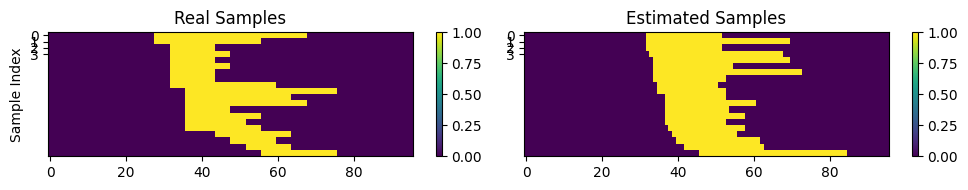

[37.033  65.41   18.417  40.688  20.074  33.307  18.014  17.981  40.064
 66.602  41.23   11.55   25.766  38.886  28.955   9.9586 43.653   5.735
 30.954  39.871 ]


100%|██████████| 95/95 [18:38<00:00, 11.77s/it]


mpc times: 11.77053848316795, mdn times: 0.0002853189195905413


In [24]:
SCALE_FACTOR = 5


# Sample once for real
test_ev_data = np.array(test_ev_data)
test_idxs = np.random.choice(len(test_ev_data), size=4*SCALE_FACTOR, replace=False)
real_arrivals, real_durations, real_energies = test_ev_data[test_idxs, 0], test_ev_data[test_idxs, 1], test_ev_data[test_idxs, 2]
real_arrivals, real_durations, real_energies = sort_on_arrival(real_arrivals, real_durations, real_energies)
# Sample once for estimate
est_arrivals, est_durations, est_energies = get_filtered_samples(mdn1, mdn2, mdn3, n_return=4*SCALE_FACTOR)
est_arrivals, est_durations, est_energies = sort_on_arrival(est_arrivals, est_durations, est_energies)

real_availability_matrix = compute_availability(real_arrivals, real_durations)
est_availability_matrix = compute_availability(est_arrivals, est_durations)

# Plotting with imshow
fig, axs = plt.subplots(1, 2, figsize=(10, 2))

im0 = axs[0].imshow(real_availability_matrix, aspect='auto', cmap='viridis')
axs[0].set_title("Real Samples")
axs[0].set_yticks(range(4))
axs[0].set_ylabel("Sample Index")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(est_availability_matrix, aspect='auto', cmap='viridis')
axs[1].set_title("Estimated Samples")
axs[1].set_yticks(range(4))
plt.colorbar(im1, ax=axs[1])


plt.tight_layout()
plt.show()
print(real_energies)


import cvxpy as cp
import numpy as np
from tqdm import tqdm
from time import time

mpc_times = []
mdn_times = []
class MDN_MPC:
    def __init__(self, num_chargers=4*SCALE_FACTOR, time_resolution=0.25, storage_capacity=30,
                 capacity_high_limit=0.85, capacity_low_limit=0.2, p_storage_limit=14, p_charger_limit=11):
        self.num_chargers = num_chargers
        self.time_resolution = time_resolution
        self.storage_capacity = storage_capacity
        self.capacity_high_limit = capacity_high_limit
        self.capacity_low_limit = capacity_low_limit
        self.p_storage_limit = p_storage_limit
        self.p_charger_limit = p_charger_limit

        # 1 hours * resolution
        self.time_shift = int(0.25 / self.time_resolution)  
        # Big-M constant
        self.M = 1e5

    def step(self, p_pv, results, charger_availability, p_price, e_factor):
        self.num_time_steps = len(p_pv)  # 24 hours * resolution

        # Initialize parameters
        self.p_grid_initial = cp.Parameter(1, value=results['p_grid'][-1:])
        self.p_grid_positive_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_positive'][-1:], 0, np.inf))
        self.p_grid_negative_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_negative'][-1:], 0, np.inf))

        self.p_storage_initial = cp.Parameter(1, value=np.clip(results['p_storage'][-1:], -self.p_storage_limit, self.p_storage_limit))
        self.p_chargers_initial = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['p_chargers'][-1,:], 0, self.p_charger_limit))
        self.storage_energy_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['storage_energy'][-1:], 
                                                                                 self.storage_capacity*self.capacity_low_limit, 
                                                                                 self.storage_capacity*self.capacity_high_limit))

        self.ev_demand = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['remaining_demand'][-1,:], 0, np.inf))
        self.charger_availability = cp.Parameter((self.num_time_steps, self.num_chargers), boolean=True, value=charger_availability)
        self.p_price = cp.Parameter(self.num_time_steps, value=p_price)
        self.e_factor = cp.Parameter(self.num_time_steps, value=e_factor)

        # Initialize decision variables
        self.p_chargers = cp.Variable((self.num_time_steps, self.num_chargers), nonneg=True)
        self.p_chargers_slack = cp.Variable(self.num_chargers, nonneg=True)
        self.p_grid = cp.Variable(self.num_time_steps)
        self.p_grid_positive = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_grid_negative = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_storage = cp.Variable(self.num_time_steps)
        self.storage_energy = cp.Variable(self.num_time_steps, nonneg=True)

        # Binary variables for big-M method
        self.binary_pos = cp.Variable(self.num_time_steps, boolean=True)

        # Constraints
        constraints = []

        # Charger availability constraints
        constraints.append(self.p_chargers[1:] <= charger_availability[1:]*self.p_charger_limit)

        # Power balance constraints
        constraints.append(p_pv[1:] + self.p_grid[1:] + self.p_storage[1:] == cp.sum(self.p_chargers, axis=1)[1:])

        # Storage constraints
        constraints.append(self.storage_energy[1:] <= self.storage_capacity * self.capacity_high_limit)
        constraints.append(self.storage_energy[1:] >= self.storage_capacity * self.capacity_low_limit)
        constraints.append(self.p_storage <= self.p_storage_limit)
        constraints.append(self.p_storage >= -self.p_storage_limit)

        # Initial conditions
        # constraints.append(self.p_grid[0] == self.p_grid_initial)
        constraints.append(self.p_grid_positive[0] == self.p_grid_positive_initial)
        constraints.append(self.p_grid_negative[0] == self.p_grid_negative_initial)

        constraints.append(self.p_storage[0] == self.p_storage_initial)
        constraints.append(self.p_chargers[0] == self.p_chargers_initial)
        constraints.append(self.storage_energy[0] == self.storage_energy_initial)
        constraints.append(self.storage_energy[-1] == self.storage_capacity/2)

        # Storage dynamics
        constraints.append(self.storage_energy[1:] == self.storage_energy[:-1] - self.p_storage[1:]*self.time_resolution)

        # EV demand constraints
        constraints.append(cp.sum(self.p_chargers[1:]*self.time_resolution, axis=0) == self.ev_demand - self.p_chargers_slack)

        # Auxiliary variables constraints
        constraints.append(self.p_grid == self.p_grid_positive - self.p_grid_negative)

        # Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
        constraints.append(self.binary_pos <= 1)
        constraints.append(self.p_grid_positive <= self.binary_pos * self.M)
        constraints.append(self.p_grid_negative <= (1-self.binary_pos) * self.M)

        # Smoothing constraint to avoid abrupt changes: total variations
        smoothing_penalty = cp.tv(self.p_grid_positive) + cp.tv(self.p_grid_negative) + cp.tv(self.p_storage) + 2*cp.tv(self.p_chargers) 

        # Create time-weighted penalty (higher weights for later time steps)
        time_weights = np.linspace(0, 20, self.num_time_steps)  # Weights increase from 1 to 3
        time_penalty = cp.sum(cp.multiply(time_weights, cp.sum(self.p_chargers, axis=1)))

        # Objective: Minimize total grid power usage
        objective = cp.Minimize(cp.sum(self.p_grid**2)*10
                                + cp.sum(cp.multiply(self.p_price,self.p_grid_positive))*0.1
                                - cp.sum(cp.multiply(self.p_price/2,self.p_grid_negative))*0.1
                                + cp.sum(cp.multiply(self.e_factor, self.p_grid))*0.1
                                + cp.sum((self.p_chargers_slack)**2)*50
                                + smoothing_penalty
                                + time_penalty*10)
        
        # Problem definition and solving
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCIP)
        
        # Output the results
        if problem.status not in ["infeasible", "unbounded"]:
            return {
                "status": problem.status,
                "objective_value": objective.value,
                "p_grid": np.array(self.p_grid.value)[1:1+self.time_shift],
                "p_grid_positive": np.array(self.p_grid_positive.value)[1:1+self.time_shift],
                "p_grid_negative": np.array(self.p_grid_negative.value)[1:1+self.time_shift],
                "p_chargers": np.array(self.p_chargers.value)[1:1+self.time_shift,:],
                "p_storage": np.array(self.p_storage.value)[1:1+self.time_shift],
            }
        else:
            print("The problem is infeasible or unbounded.")

            
    def update_estimates_given_arrival(self, mdn2, mdn3, arrival):
        # Sample duration given arrival
        arrival_tensor = torch.tensor(arrival).reshape(-1, 1).float()  # shape: (1, 1)
        pi2, mu2, sigma2 = mdn2(arrival_tensor)
        duration_sample = mdn2.sample_greedy(pi2, mu2, sigma2)  # shape: (1, 1)
        # Step 2: Sample energy demand given arrival and duration
        input_tensor = torch.cat([arrival_tensor, duration_sample], dim=1)  # shape: (1, 2)
        pi3, mu3, sigma3 = mdn3(input_tensor)
        demand_sample = mdn3.sample_greedy(pi3, mu3, sigma3)  # shape: (1, 1)
        return  duration_sample.detach().numpy().flatten()[0], demand_sample.detach().numpy().flatten()[0]/4

# Example usage:
# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4*SCALE_FACTOR


# Storage constraints
storage_capacity = 30*SCALE_FACTOR  # Example capacity
capacity_high_imit = 0.85
capacity_low_imit = 0.2

mpc = MDN_MPC()
current_time = 0
time_shift = int(0.25 / mpc.time_resolution)  # 2 hours * resolution
# Initialize storage energy
storage_energy_initial = np.array([storage_capacity]) / 2
# Initialize EV demand
real_energies_initial = real_energies.reshape(1,4*SCALE_FACTOR)  # Example EV demand
est_energies_initial = est_energies.reshape(1,4*SCALE_FACTOR)  # Example EV demand

real_availability = np.vstack([np.zeros((1, len(real_availability_matrix))), real_availability_matrix.T])
est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])

results = {
    'p_grid':           np.zeros((1,)),
    'p_grid_ideal':     np.zeros((1,)),
    'p_grid_positive':  np.zeros((1,)),
    'p_grid_negative':  np.zeros((1,)),
    'p_storage':        np.zeros((1,)),
    'p_storage_ideal':  np.zeros((1,)),
    'storage_energy':   storage_energy_initial,
    'p_chargers':       np.zeros((1, num_chargers)),
    'p_chargers_ideal':       np.zeros((1, num_chargers)),
    'remaining_demand': real_energies_initial,
}

n_occupied = 0

ev_errors = []
for t in tqdm(range(1, num_time_steps)):
    # if t == 1: print(f"EV information - t: {t}, arrivals: {est_arrivals}, durations: {est_durations}, energies: {est_energies}")
    # print(f"t: {t}, real arrivals: {real_arrivals}, est arrivals: {est_arrivals}")
    if t in (real_arrivals*4).astype(int):
        # Sample once for estimate
        time1= time()
        new_duration_sample, new_demand_sample = mpc.update_estimates_given_arrival(mdn2, mdn3, t/4)
        mdn_times.append(time()-time1)
        # Update estimated arrivals and durations
        est_arrivals[n_occupied] = t/4
        est_durations[n_occupied] = new_duration_sample
        est_energies[n_occupied] = new_demand_sample
        # Update estimated availability matrix
        est_availability_matrix = compute_availability(est_arrivals, est_durations)
        est_availability = np.vstack([np.zeros((1, len(est_availability_matrix))), est_availability_matrix.T])
        # incremeant occupied
        n_occupied += 1
        # print(f"EVs: {n_occupied} - t: {t}, arrivals: {est_arrivals}, durations: {est_durations}, energies: {est_energies}")
        

    if t%time_shift==0:
        # Forecast and real PV generation (kW)
        p_pv = SCALE_FACTOR * expanded_pv_forecast[t-1:] / 1000
        p_pv_real = SCALE_FACTOR * expanded_pv[t-1:] / 1000
        # Charger availability masks
        charger_availability = est_availability[t-1:, :mpc.num_chargers]
        charger_availability_real = real_availability[t-1:, :mpc.num_chargers]
        # Price and emissions
        p_price = expanded_price[t-1:]
        e_factor = expanded_emmision[t-1:]

        # Run MPC step
        time1 = time()
        command = mpc.step(p_pv, results, charger_availability, p_price, e_factor)
        mpc_times.append(time()-time1)
        
        # Apply real availability to ideal command
        adjusted_p_chargers = (command['p_chargers'] * charger_availability_real[1:time_shift+1]).copy()

        # Compute availability gap (newly available chargers)
        availability_gap = (charger_availability_real[1:time_shift+1] - charger_availability[1:time_shift+1]) > 0.5

        # Remaining energy demand (kWh) per charger at start of this window
        remaining_demand = results['remaining_demand'][-1].copy()

        # Compute total existing charging power for chargers that are already active
        existing_charging_power = np.sum(
            adjusted_p_chargers[~availability_gap]  # chargers not newly available
        )

        # Compute grid headroom: subtract already committed charging from max grid usage
        raw_grid_headroom = 15 #np.max(np.abs(results['p_grid']))
        grid_headroom = max(0, raw_grid_headroom - existing_charging_power)  # ensure non-negative

        # Consider only chargers that are newly available at least once in this window
        newly_available_mask = np.any(availability_gap, axis=0)
        relevant_demand = remaining_demand * newly_available_mask
        total_demand = relevant_demand.sum() + 1e-6  # avoid divide by zero

        # Precompute weighted per-charger limit based on demand for newly available chargers
        weights = np.abs(relevant_demand / total_demand)
        per_charger_limit = weights * grid_headroom

        # Adjust newly available chargers up to their weighted limit or remaining demand
        for i in range(time_shift):
            for j in range(mpc.num_chargers):
                if availability_gap[i, j]:
                    # Max power based on remaining energy demand
                    demand_limit = remaining_demand[j] / mpc.time_resolution
                    # Weighted grid limit for this charger
                    grid_limit_j = per_charger_limit[j]
                    # Clip between zero and the smaller of demand_limit and grid_limit_j
                    adjusted_p_chargers[i, j] = np.clip(
                        demand_limit,  # base from ideal command
                        0,
                        min(grid_limit_j, mpc.p_charger_limit)  # ensure it does not exceed charger limit
                    )
        # if t == 60: break
        # Adjust for actual PV power using the battery
        pv_error = p_pv_real[1:time_shift+1] - p_pv[1:time_shift+1]  # Compute forecast error
        ev_error = np.sum(adjusted_p_chargers - command['p_chargers'], axis=1)
        # print(f"t: {t}, pv_error: {pv_error}, ev_error: {ev_error}")
        ev_errors.append(ev_error)
        # Initialize adjusted battery power
        adjusted_p_storage = command['p_storage'].copy()
        current_storage_energy = results['storage_energy'][-1].copy()  # Current SoC
        # break
        # print(t)
        # if t >= 30:
        #     break
        # Adjust battery power to absorb PV error
        for i in range(time_shift):
            adjusted_p_storage[i] = adjusted_p_storage[i] - pv_error[i] + ev_error[i]
            # Ensure discharging does not exceed limit
            adjusted_p_storage[i] = np.clip(adjusted_p_storage[i], -mpc.p_storage_limit, mpc.p_storage_limit)  # Ensure discharging does not exceed limit
            adjusted_p_storage[i] = -np.clip(-adjusted_p_storage[i], 
                                            -np.negative(mpc.storage_capacity*mpc.capacity_low_limit - current_storage_energy) / mpc.time_resolution,
                                            np.positive(mpc.storage_capacity*mpc.capacity_high_limit - current_storage_energy) / mpc.time_resolution)
            
            # Update SoC for the next iteration
            current_storage_energy = current_storage_energy - \
                                    (1/0.95) * np.maximum(0, adjusted_p_storage[i]) * mpc.time_resolution - \
                                    (0.95) * np.minimum(0, adjusted_p_storage[i]) * mpc.time_resolution

        # Adjust grid power based on adjusted battery power
        p_grid_samples = np.sum(adjusted_p_chargers, axis=1) - adjusted_p_storage - p_pv_real[1:time_shift+1]
        p_grid_positive_samples = np.maximum(p_grid_samples, 0)
        p_grid_negative_samples = np.minimum(p_grid_samples, 0)
        # if t == 57:
        #     print(f"t: {t}, charger: {np.sum(command['p_chargers'], axis=1)},\n adjusted_p_storage: {adjusted_p_storage},\n pv real: {p_pv_real[:time_shift]},\n \
        #           pv forecast: {p_pv[:time_shift]} \n adjusted grid: {p_grid_samples}, p_grid :{command['p_grid']}")

        # print(f"time {t}-{t+time_shift-1},\n p_grid: {command['p_grid']},\n adjusted p_grid: {p_grid_samples},\n p_storage: {command['p_storage']},\n adjusted p_storage: {adjusted_p_storage},\n p_error: {pv_error}")
        # Update storage energy based on adjusted battery power
        storage_energy_samples = results['storage_energy'][-1] - \
                                (1/0.95) * np.cumsum(np.maximum(0, adjusted_p_storage)) * mpc.time_resolution - \
                                (0.95) * np.cumsum(np.minimum(0, adjusted_p_storage)) * mpc.time_resolution

        # EV demand update (unchanged)
        ev_demand_samples = results['remaining_demand'][-1].reshape(1, 4*SCALE_FACTOR) - \
                            np.cumsum(adjusted_p_chargers, axis=0) * mpc.time_resolution


        # Store results
        results['p_grid_ideal'] = np.hstack([results['p_grid_ideal'], command['p_grid']])
        results['p_grid'] = np.hstack([results['p_grid'], p_grid_samples])
        results['p_grid_positive'] = np.hstack([results['p_grid_positive'], p_grid_positive_samples])
        results['p_grid_negative'] = np.hstack([results['p_grid_negative'], p_grid_negative_samples])


        results['p_chargers'] = np.vstack([results['p_chargers'], adjusted_p_chargers])
        results['p_chargers_ideal'] = np.vstack([results['p_chargers_ideal'], command['p_chargers']])
        results['p_storage'] = np.hstack([results['p_storage'], adjusted_p_storage])
        results['p_storage_ideal'] = np.hstack([results['p_storage_ideal'], command['p_storage']])
        results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_samples])
        results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_samples])
        # if t == 4*time_shift+1:
    #     break

for key in results.keys():
    if key not in ['storage_energy', 'remaining_demand']:
        results[key] = results[key][1:]
    else:
        results[key] = results[key][1:]
        
print(f"mpc times: {np.mean(mpc_times)}, mdn times: {np.mean(mdn_times)}")